## Global Variables for color


In [1]:
GRADE_COLORS = {
    "Excellent":         "#1B7B3B",  # dark green
    "Good":              "#7CB342",  # medium green
    "Okay":              "#C5D92C",  # yellow-green
    "Needs To Improve":  "#A9A9A9",  # gray
    "Not Rated":         "#E0E0E0",  # light gray, not in the source image
    "Rating Not Available": "#E0E0E0",
}


## Preprofessing

### Merge Two Dataset

Merge Two dataset by using store name and address

In [385]:
import pandas as pd
df1=pd.read_csv('Food_Establishment_Inspection_Data_20260807.csv')
df2=pd.read_csv('Businesses_Food-King_County_20260812.csv')

/var/folders/4x/_7_xsjdx4wq_kp0jy8nklhz40000gn/T/ipykernel_27172/3118857966.py:2: DtypeWarning: Columns (0: Parcel Number) have mixed types. Specify dtype option on import or set low_memory=False.
  df1=pd.read_csv('Food_Establishment_Inspection_Data_20260807.csv')


In [386]:
df1

,Name,Program Identifier,Inspection Date,Classification,Address,City,Zip Code,Inspection Type,Inspection Score,Inspection Result,Inspection Closed Business,Seating Range,Risk Category,Violation Type,Violation Description,Violation Points,Grade,Parcel Number,Business_ID,Inspection_Serial_Num
0,#807 TUTTA BELLA,NaN,05/28/2026,General Food Services,2746 NE 45TH ST,SEATTLE,98105,Routine Inspection/Field Review,0,Satisfactory,No,0-12,3.0,NaN,NaN,0,Excellent,925049330.0,PFE-PR-3147569,PFE-RT-0465692-2025
1,#807 TUTTA BELLA,NaN,12/23/2025,General Food Services,2746 NE 45TH ST,SEATTLE,98105,Educational Inspection,0,Complete,No,0-12,3.0,NaN,NaN,0,Excellent,925049330.0,PFE-PR-3147569,PFE-EDU-104561-2025
2,#807 TUTTA BELLA,NaN,08/15/2025,General Food Services,2746 NE 45TH ST,SEATTLE,98105,Routine Inspection/Field Review,0,Satisfactory,No,0-12,3.0,NaN,NaN,0,Excellent,925049330.0,PFE-PR-3147569,PFE-DAXHJEKXU
3,#807 TUTTA BELLA,NaN,03/24/2025,General Food Services,2746 NE 45TH ST,SEATTLE,98105,Routine Inspection/Field Review,5,Unsatisfactory,No,0-12,3.0,RED,2120 - Proper cold holding temperatures; betwe...,5,Excellent,925049330.0,PFE-PR-3147569,PFE-DA05TOC3V
4,#807 TUTTA BELLA,NaN,08/02/2024,General Food Services,2746 NE 45TH ST,SEATTLE,98105,Routine Inspection/Field Review,15,Unsatisfactory,No,0-12,3.0,BLUE,"3400 - Wiping cloths properly used, stored; sa...",5,Excellent,925049330.0,PFE-PR-3147569,PFE-DAPY60A5G
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
106226,ZYLBERSCHTEIN'S DELICATESSEN & BAKERY,NaN,02/01/2023,General Food Services,11752 15TH AVE NE,SEATTLE,98125,Routine Inspection/Field Review,20,Unsatisfactory,No,0-12,3.0,RED,0600 - Adequate handwashing facilities,10,Okay,6798100810.0,PFE-PR-3145516,PFE-DACCQMMPT
106227,ZYLBERSCHTEIN'S DELICATESSEN & BAKERY,NaN,01/26/2022,General Food Services,11752 15TH AVE NE,SEATTLE,98125,Routine Inspection/Field Review,15,Unsatisfactory,No,0-12,3.0,RED,2110 - Proper cold holding temperatures; great...,10,Okay,6798100810.0,PFE-PR-3145516,PFE-DAXVOTIWN
106228,ZYLBERSCHTEIN'S DELICATESSEN & BAKERY,NaN,01/26/2022,General Food Services,11752 15TH AVE NE,SEATTLE,98125,Routine Inspection/Field Review,15,Unsatisfactory,No,0-12,3.0,RED,0200 - Food Worker Cards current for all food ...,5,Okay,6798100810.0,PFE-PR-3145516,PFE-DAXVOTIWN
106229,ZYLBERSCHTEIN'S DELICATESSEN & BAKERY,NaN,05/12/2021,General Food Services,11752 15TH AVE NE,SEATTLE,98125,Routine Inspection/Field Review,15,Unsatisfactory,No,0-12,3.0,BLUE,4100 - Warewashing facilities properly install...,5,Okay,6798100810.0,PFE-PR-3145516,PFE-DATJ0JRDR


In [387]:
df2

,Business_ID,Name,Address,City,Latitude,Longitude,Grade
0,PR0082813,1000 SPIRITS,1225 1ST AVE,SEATTLE,47.606539,-122.338223,1
1,PR0085848,100 LB CLAM,1001 FAIRVIEW AVE N Unit 1700A,SEATTLE,47.629021,-122.331727,1
2,PR0089941,100TH AVE CAKES,15364 NE 96TH PL,REDMOND,47.687230,-122.133729,1
3,PR0071992,108 VIETNAMESE AUTHENTIC CUISINE,18114 E VALLEY HWY,KENT,47.439923,-122.219347,3
4,PR0006149,11TH FRAME RESTAURANT & LOUNGE,7638 NE BOTHELL WAY,KENMORE,47.757875,-122.237682,2
...,...,...,...,...,...,...,...
10398,PR0029917,Z'S PIZZA,15600 NE 8TH ST STE B6,BELLEVUE,47.618050,-122.129095,1
10399,PR0027317,ZSX & SZECHUAN RICE NOODLE,628 S WELLER ST,SEATTLE,47.597656,-122.325270,3
10400,PR0088787,"ZUBA, LLC",400 PINE ST STE 3050,SEATTLE,47.611695,-122.337212,3
10401,PR0085628,ZULU BOARD GAME CAFE,10234 MAIN ST,BOTHELL,47.760528,-122.202443,2


In [388]:
#dedup the duplicate data from df2
print('df2 rows before dedup:', len(df2))
df2 = df2.drop_duplicates(subset=['Name', 'Address'], keep='first')
print('df2 rows after dedup:', len(df2))


df2 rows before dedup: 10403
df2 rows after dedup: 9314


In [389]:
#Using left join to keep the data related to df1
merged_df = df1.merge(df2[['Name','Address','Latitude','Longitude']], on=['Name', 'Address'], how='left')
merged_df

,Name,Program Identifier,Inspection Date,Classification,Address,City,Zip Code,Inspection Type,Inspection Score,Inspection Result,...,Risk Category,Violation Type,Violation Description,Violation Points,Grade,Parcel Number,Business_ID,Inspection_Serial_Num,Latitude,Longitude
0,#807 TUTTA BELLA,NaN,05/28/2026,General Food Services,2746 NE 45TH ST,SEATTLE,98105,Routine Inspection/Field Review,0,Satisfactory,...,3.0,NaN,NaN,0,Excellent,925049330.0,PFE-PR-3147569,PFE-RT-0465692-2025,47.662311,-122.296415
1,#807 TUTTA BELLA,NaN,12/23/2025,General Food Services,2746 NE 45TH ST,SEATTLE,98105,Educational Inspection,0,Complete,...,3.0,NaN,NaN,0,Excellent,925049330.0,PFE-PR-3147569,PFE-EDU-104561-2025,47.662311,-122.296415
2,#807 TUTTA BELLA,NaN,08/15/2025,General Food Services,2746 NE 45TH ST,SEATTLE,98105,Routine Inspection/Field Review,0,Satisfactory,...,3.0,NaN,NaN,0,Excellent,925049330.0,PFE-PR-3147569,PFE-DAXHJEKXU,47.662311,-122.296415
3,#807 TUTTA BELLA,NaN,03/24/2025,General Food Services,2746 NE 45TH ST,SEATTLE,98105,Routine Inspection/Field Review,5,Unsatisfactory,...,3.0,RED,2120 - Proper cold holding temperatures; betwe...,5,Excellent,925049330.0,PFE-PR-3147569,PFE-DA05TOC3V,47.662311,-122.296415
4,#807 TUTTA BELLA,NaN,08/02/2024,General Food Services,2746 NE 45TH ST,SEATTLE,98105,Routine Inspection/Field Review,15,Unsatisfactory,...,3.0,BLUE,"3400 - Wiping cloths properly used, stored; sa...",5,Excellent,925049330.0,PFE-PR-3147569,PFE-DAPY60A5G,47.662311,-122.296415
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
106226,ZYLBERSCHTEIN'S DELICATESSEN & BAKERY,NaN,02/01/2023,General Food Services,11752 15TH AVE NE,SEATTLE,98125,Routine Inspection/Field Review,20,Unsatisfactory,...,3.0,RED,0600 - Adequate handwashing facilities,10,Okay,6798100810.0,PFE-PR-3145516,PFE-DACCQMMPT,47.715359,-122.312056
106227,ZYLBERSCHTEIN'S DELICATESSEN & BAKERY,NaN,01/26/2022,General Food Services,11752 15TH AVE NE,SEATTLE,98125,Routine Inspection/Field Review,15,Unsatisfactory,...,3.0,RED,2110 - Proper cold holding temperatures; great...,10,Okay,6798100810.0,PFE-PR-3145516,PFE-DAXVOTIWN,47.715359,-122.312056
106228,ZYLBERSCHTEIN'S DELICATESSEN & BAKERY,NaN,01/26/2022,General Food Services,11752 15TH AVE NE,SEATTLE,98125,Routine Inspection/Field Review,15,Unsatisfactory,...,3.0,RED,0200 - Food Worker Cards current for all food ...,5,Okay,6798100810.0,PFE-PR-3145516,PFE-DAXVOTIWN,47.715359,-122.312056
106229,ZYLBERSCHTEIN'S DELICATESSEN & BAKERY,NaN,05/12/2021,General Food Services,11752 15TH AVE NE,SEATTLE,98125,Routine Inspection/Field Review,15,Unsatisfactory,...,3.0,BLUE,4100 - Warewashing facilities properly install...,5,Okay,6798100810.0,PFE-PR-3145516,PFE-DATJ0JRDR,47.715359,-122.312056


In [390]:
merged_df['Latitude'].isna().sum()

np.int64(65937)

In [391]:
unique_restaurants = merged_df.drop_duplicates(subset=['Name', 'Address','Business_ID','Latitude','Longitude'])

print('Total unique restaurants:', len(unique_restaurants))
print('Unique restaurants with missing data (no match):', unique_restaurants['Latitude'].isna().sum())
print('Unique restaurants with data (matched):', unique_restaurants['Latitude'].notna().sum())



Total unique restaurants: 12261
Unique restaurants with missing data (no match): 7524
Unique restaurants with data (matched): 4737


In [392]:
merged_df.to_csv("merge_completed.csv", index=False)


In [393]:
import gc
import psutil, os
del df1
del df2
del merged_df
gc.collect()

13947

### GeoPy to find the missing Latitude and Longtitude after merging table

In [394]:
import pandas as pd


def dedupe_words(text: str) -> str:
    words = text.split()
    out = [w for i, w in enumerate(words) if i == 0 or w.upper() != words[i - 1].upper()]
    return " ".join(out)


def split_address(full_address: str):
    """Split 'STREET[, UNIT...], CITY, STATE ZIP, USA' into
    (clean_address, unit), dropping embedded unit/suite tokens that break
    geocoders and collapsing accidental duplicate words in the street."""
    parts = [p.strip() for p in full_address.split(",")]
    street, city, state_zip, country = parts[0], parts[-3], parts[-2], parts[-1]
    unit_parts = [p for p in parts[1:-3] if p]

    street = dedupe_words(street)
    clean_address = f"{street}, {city}, {state_zip}, {country}"
    unit = ", ".join(unit_parts) if unit_parts else pd.NA
    return clean_address, unit


def add_clean_address_columns(df: pd.DataFrame, address_col: str = "full_address") -> pd.DataFrame:
    """Add Clean_Address and Unit columns to df, derived from address_col."""
    split = df[address_col].apply(split_address)
    df["Clean_Address"] = split.apply(lambda t: t[0])
    df["Unit"] = split.apply(lambda t: t[1])

    with_unit = df["Unit"].notna().sum()
    print(f"Added Clean_Address and Unit columns")
    print(f"{with_unit} of {len(df)} rows had an embedded unit/suite token extracted")
    return df


In [395]:
unique_restaurants['full_address'] = (
    unique_restaurants['Address'].fillna('').astype(str) + ', ' +
    unique_restaurants['City'].fillna('').astype(str) + ', ' +
    'WA ' +
    unique_restaurants['Zip Code'].fillna('').astype(str) + ', ' +
    'USA'
)

missing_df = unique_restaurants[unique_restaurants['Latitude'].isna()].copy()
missing_df = add_clean_address_columns(missing_df, address_col='full_address')
missing_df


Added Clean_Address and Unit columns
2204 of 7524 rows had an embedded unit/suite token extracted


,Name,Program Identifier,Inspection Date,Classification,Address,City,Zip Code,Inspection Type,Inspection Score,Inspection Result,...,Violation Points,Grade,Parcel Number,Business_ID,Inspection_Serial_Num,Latitude,Longitude,full_address,Clean_Address,Unit
15,+MAS CAFE,NaN,08/05/2026,General Food Services,1906 N 34TH ST,SEATTLE,98103,Educational Inspection,0,Complete,...,0,Excellent,4083306595.0,PFE-PR-3133145,PFE-EDU-157140-2026,NaN,NaN,"1906 N 34TH ST, SEATTLE, WA 98103, USA","1906 N 34TH ST, SEATTLE, WA 98103, USA",NaN
38,100 LB CLAM,NaN,07/15/2026,General Food Services,"1001 FAIRVIEW AVE N, 1700A",SEATTLE,98109,Routine Inspection/Field Review,5,Unsatisfactory,...,5,Excellent,4088803010.0,PFE-PR-3144538,PFE-RT-0464476-2026,NaN,NaN,"1001 FAIRVIEW AVE N, 1700A, SEATTLE, WA 98109,...","1001 FAIRVIEW AVE N, SEATTLE, WA 98109, USA",1700A
73,11TH FRAME RESTAURANT & LOUNGE,NaN,07/02/2026,General Food Services,7638 NE BOTHELL WAY,KENMORE,98028,Routine Inspection/Field Review,5,Satisfactory,...,5,Excellent,114100888.0,PFE-PR-3128669,PFE-RT-0458232-2025,NaN,NaN,"7638 NE BOTHELL WAY, KENMORE, WA 98028, USA","7638 NE BOTHELL WAY, KENMORE, WA 98028, USA",NaN
84,12TH AVE CAFE,NaN,05/05/2026,General Food Services,"775 NW GILMAN BLVD, STE G",ISSAQUAH,98027,Return Inspection,0,Satisfactory,...,0,Good,2824069310.0,PFE-PR-3132914,PFE-RT-133398-2026,NaN,NaN,"775 NW GILMAN BLVD, STE G, ISSAQUAH, WA 98027,...","775 NW GILMAN BLVD, ISSAQUAH, WA 98027, USA",STE G
97,13 COINS,NaN,04/13/2026,General Food Services,18000 INTERNATIONAL BLVD BLVD S,SEATAC,98188,Routine Inspection/Field Review,13,Satisfactory,...,3,Okay,3323049001.0,PFE-PR-3127906,PFE-RT-115499-2026,NaN,NaN,"18000 INTERNATIONAL BLVD BLVD S, SEATAC, WA 98...","18000 INTERNATIONAL BLVD S, SEATAC, WA 98188, USA",NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
106099,ZOCO CAFE AND WINE,NaN,04/10/2026,General Food Services,9901 8th Ave SW,Seattle,98106-3036,Routine Inspection/Field Review,3,Satisfactory,...,3,Excellent,2895800150.0,PFE-PR-501326,PFE-RT-130032-2026,NaN,NaN,"9901 8th Ave SW, Seattle, WA 98106-3036, USA","9901 8th Ave SW, Seattle, WA 98106-3036, USA",NaN
106118,ZOLA'S CAFE,NaN,05/22/2026,General Food Services,"402 E MAIN ST, 102",AUBURN,98002,Routine Inspection/Field Review,2,Satisfactory,...,2,Good,8698100005.0,PFE-PR-3137599,PFE-RT-0462716-2026,NaN,NaN,"402 E MAIN ST, 102, AUBURN, WA 98002, USA","402 E MAIN ST, AUBURN, WA 98002, USA",102
106134,ZOUAVE RESTAURANT,NaN,07/16/2025,General Food Services,2615 NE 65TH ST,SEATTLE,98115,Return Inspection,0,Complete,...,0,Okay,1868901670.0,PFE-PR-3126713,PFE-DATH0IOJN,NaN,NaN,"2615 NE 65TH ST, SEATTLE, WA 98115, USA","2615 NE 65TH ST, SEATTLE, WA 98115, USA",NaN
106157,ZSX & SZECHUAN RICE NOODLE,NaN,02/20/2026,General Food Services,628 S WELLER ST,SEATTLE,98104,Routine Inspection/Field Review,27,Unsatisfactory,...,5,Okay,5247801900.0,PFE-PR-3131473,PFE-RT-0459576-2025,NaN,NaN,"628 S WELLER ST, SEATTLE, WA 98104, USA","628 S WELLER ST, SEATTLE, WA 98104, USA",NaN


In [396]:
from geopy.geocoders import Nominatim
import certifi
import ssl
import time
import os
import pandas as pd
def geocode_missing(df, address_col='Clean_Address', output_path='geo_df.csv', batch_size=50, sleep_sec=1, start_i=0):
    ctx = ssl.create_default_context(cafile=certifi.where())
    geolocator = Nominatim(user_agent="my_geocoder", ssl_context=ctx)

    addresses = df[address_col].unique().tolist()

    done = set()
    if os.path.isfile(output_path):
        done = set(pd.read_csv(output_path)['Address'])

    results = []
    for i in range(start_i, len(addresses)):
        address = addresses[i]
        if address in done:
            continue

        try:
            location = geolocator.geocode(address)
        except Exception as e:
            print(f"item {i}: {address} errored: {e}")
            location = None

        if location:
            print(f"item {i}: {address} -> ({location.latitude}, {location.longitude})")
            results.append({'Item': i, 'Address': address, 'Latitude': location.latitude, 'Longitude': location.longitude})
        else:
            print(f"item {i}: {address} not found")
            results.append({'Item': i, 'Address': address, 'Latitude': None, 'Longitude': None})
        if i % batch_size == 0 or i == len(addresses) - 1:
            batch_df = pd.DataFrame(results)
            file_exists = os.path.isfile(output_path)
            batch_df.to_csv(output_path, mode='a', header=not file_exists, index=False)
            print(f"saved {len(results)} rows to {output_path}")
            results = []

        time.sleep(sleep_sec)  # Nominatim's usage policy: max 1 req/sec

    return pd.read_csv(output_path)


In [397]:
geo_df = geocode_missing(missing_df, address_col='Clean_Address', output_path='geo_df.csv')

item 4: 18000 INTERNATIONAL BLVD S, SEATAC, WA 98188, USA not found
item 7: 3601 FREMONT AVE N, SEATTLE, WA 98103, USA -> (47.6515569, -122.350184)
item 12: 11901 NE VILLAGE PL, KIRKLAND, WA 98034, USA -> (47.712426, -122.1802207)
item 13: 610 TERRY AVE N, SEATTLE, WA 98109, USA -> (47.6251297, -122.3368499)


KeyboardInterrupt: 

In [ ]:
geo_df = pd.read_csv('geo_df.csv')
merge_completed = pd.read_csv('merge_completed.csv')

merge_completed['full_address'] = (
    merge_completed['Address'].fillna('').astype(str) + ', ' +
    merge_completed['City'].fillna('').astype(str) + ', ' +
    'WA ' +
    merge_completed['Zip Code'].fillna('').astype(str) + ', ' +
    'USA'
)
merge_completed['Clean_Address'] = merge_completed['full_address'].apply(lambda a: split_address(a)[0])

geo_lookup = geo_df.drop_duplicates(subset='Address').set_index('Address')[['Latitude', 'Longitude']]

mask = merge_completed['Latitude'].isna()
merge_completed.loc[mask, 'Latitude'] = merge_completed.loc[mask, 'Clean_Address'].map(geo_lookup['Latitude'])
merge_completed.loc[mask, 'Longitude'] = merge_completed.loc[mask, 'Clean_Address'].map(geo_lookup['Longitude'])

merge_completed.to_csv('final_completed.csv', index=False)


/var/folders/4x/_7_xsjdx4wq_kp0jy8nklhz40000gn/T/ipykernel_4623/2794264156.py:2: DtypeWarning: Columns (0: Parcel Number) have mixed types. Specify dtype option on import or set low_memory=False.
  merge_completed = pd.read_csv('merge_completed.csv')


In [ ]:
import gc
import psutil, os
del merge_completed
gc.collect()

3978

## Load the cleaned table

In [2]:
import pandas as pd
df=pd.read_csv('final_completed.csv')

/var/folders/4x/_7_xsjdx4wq_kp0jy8nklhz40000gn/T/ipykernel_92652/2734412780.py:2: DtypeWarning: Columns (0: Parcel Number) have mixed types. Specify dtype option on import or set low_memory=False.
  df=pd.read_csv('final_completed.csv')


In [3]:
df

,Name,Program Identifier,Inspection Date,Classification,Address,City,Zip Code,Inspection Type,Inspection Score,Inspection Result,...,Risk Category,Violation Type,Violation Description,Violation Points,Grade,Parcel Number,Business_ID,Inspection_Serial_Num,Latitude,Longitude
0,#807 TUTTA BELLA,NaN,05/28/2026,General Food Services,2746 NE 45TH ST,SEATTLE,98105,Routine Inspection/Field Review,0,Satisfactory,...,3.0,NaN,NaN,0,Excellent,925049330.0,PFE-PR-3147569,PFE-RT-0465692-2025,47.662155,-122.296403
1,#807 TUTTA BELLA,NaN,12/23/2025,General Food Services,2746 NE 45TH ST,SEATTLE,98105,Educational Inspection,0,Complete,...,3.0,NaN,NaN,0,Excellent,925049330.0,PFE-PR-3147569,PFE-EDU-104561-2025,47.662155,-122.296403
2,#807 TUTTA BELLA,NaN,08/15/2025,General Food Services,2746 NE 45TH ST,SEATTLE,98105,Routine Inspection/Field Review,0,Satisfactory,...,3.0,NaN,NaN,0,Excellent,925049330.0,PFE-PR-3147569,PFE-DAXHJEKXU,47.662155,-122.296403
3,#807 TUTTA BELLA,NaN,03/24/2025,General Food Services,2746 NE 45TH ST,SEATTLE,98105,Routine Inspection/Field Review,5,Unsatisfactory,...,3.0,RED,2120 - Proper cold holding temperatures; betwe...,5,Excellent,925049330.0,PFE-PR-3147569,PFE-DA05TOC3V,47.662155,-122.296403
4,#807 TUTTA BELLA,NaN,08/02/2024,General Food Services,2746 NE 45TH ST,SEATTLE,98105,Routine Inspection/Field Review,15,Unsatisfactory,...,3.0,BLUE,"3400 - Wiping cloths properly used, stored; sa...",5,Excellent,925049330.0,PFE-PR-3147569,PFE-DAPY60A5G,47.662155,-122.296403
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
106270,ZYLBERSCHTEIN'S DELICATESSEN & BAKERY,NaN,02/01/2023,General Food Services,11752 15TH AVE NE,SEATTLE,98125,Routine Inspection/Field Review,20,Unsatisfactory,...,3.0,RED,0600 - Adequate handwashing facilities,10,Okay,6798100810.0,PFE-PR-3145516,PFE-DACCQMMPT,47.715612,-122.312056
106271,ZYLBERSCHTEIN'S DELICATESSEN & BAKERY,NaN,01/26/2022,General Food Services,11752 15TH AVE NE,SEATTLE,98125,Routine Inspection/Field Review,15,Unsatisfactory,...,3.0,RED,2110 - Proper cold holding temperatures; great...,10,Okay,6798100810.0,PFE-PR-3145516,PFE-DAXVOTIWN,47.715612,-122.312056
106272,ZYLBERSCHTEIN'S DELICATESSEN & BAKERY,NaN,01/26/2022,General Food Services,11752 15TH AVE NE,SEATTLE,98125,Routine Inspection/Field Review,15,Unsatisfactory,...,3.0,RED,0200 - Food Worker Cards current for all food ...,5,Okay,6798100810.0,PFE-PR-3145516,PFE-DAXVOTIWN,47.715612,-122.312056
106273,ZYLBERSCHTEIN'S DELICATESSEN & BAKERY,NaN,05/12/2021,General Food Services,11752 15TH AVE NE,SEATTLE,98125,Routine Inspection/Field Review,15,Unsatisfactory,...,3.0,BLUE,4100 - Warewashing facilities properly install...,5,Okay,6798100810.0,PFE-PR-3145516,PFE-DATJ0JRDR,47.715612,-122.312056


In [4]:
df[df['Inspection Score'] < 0]

,Name,Program Identifier,Inspection Date,Classification,Address,City,Zip Code,Inspection Type,Inspection Score,Inspection Result,...,Risk Category,Violation Type,Violation Description,Violation Points,Grade,Parcel Number,Business_ID,Inspection_Serial_Num,Latitude,Longitude
57082,MENUDERIA MARIA,NaN,12/09/2024,General Food Services,23060 PACIFC HWY S,DES MOINES,98198,Return Inspection,-1,Unsatisfactory,...,3.0,NaN,NaN,0,Okay,2500600250.0,PFE-PR-3146132,PFE-DASJPFAGJ,NaN,NaN


In [5]:
df = df[df['Inspection Score'] >= 0]

In [6]:
unique_df = df.drop_duplicates(subset='Business_ID')
missing_count = unique_df['Latitude'].isna().sum()
missing_pct = missing_count / len(unique_df)

print(f"Unique businesses with missing Latitude/Longtitude: {missing_count} of {len(unique_df)}")
print(f"Missing rate: {missing_pct:.2%}")


Unique businesses with missing Latitude/Longtitude: 643 of 12261
Missing rate: 5.24%


In [7]:
df.info()

<class 'pandas.DataFrame'>
Index: 106274 entries, 0 to 106274
Data columns (total 22 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   Name                        106274 non-null  str    
 1   Program Identifier          19404 non-null   str    
 2   Inspection Date             106274 non-null  str    
 3   Classification              106274 non-null  str    
 4   Address                     106274 non-null  str    
 5   City                        106268 non-null  str    
 6   Zip Code                    106274 non-null  str    
 7   Inspection Type             106274 non-null  str    
 8   Inspection Score            106274 non-null  int64  
 9   Inspection Result           106274 non-null  str    
 10  Inspection Closed Business  106274 non-null  str    
 11  Seating Range               83089 non-null   str    
 12  Risk Category               105645 non-null  float64
 13  Violation Type              66

In [8]:
def show_unique(df, max_unique=20):
    for col in df.columns:
        n = df[col].nunique(dropna=True)
        print(f"{col}: {n} unique value(s)")
        if n <= max_unique:
            print(df[col].unique())
        print()
show_unique(df)

Name: 9802 unique value(s)

Program Identifier: 2394 unique value(s)

Inspection Date: 1649 unique value(s)

Classification: 14 unique value(s)
<StringArray>
[      'General Food Services',               'Grocery Store',
          'Catering Operation',          'Commissary Kitchen',
            'Meat/Fish Market',                      'Bakery',
            'Mobile Food Unit',        'School Lunch Program',
        'Limited Food Service',       'Nonprofit Institution',
    'DFDO Exempt from billing',                        'DFDO',
        'General Food Service', 'Bed and Breakfast Operation']
Length: 14, dtype: str

Address: 9455 unique value(s)

City: 111 unique value(s)

Zip Code: 129 unique value(s)

Inspection Type: 3 unique value(s)
<StringArray>
['Routine Inspection/Field Review',          'Educational Inspection',
               'Return Inspection']
Length: 3, dtype: str

Inspection Score: 126 unique value(s)

Inspection Result: 3 unique value(s)
<StringArray>
['Satisfactory', 'C

In [9]:
df['Classification'] = df['Classification'].replace('General Food Services', 'General Food Service')

In [10]:
df.loc[(df['Violation Points'] == 0) & (df['Violation Type'].isna()), 'Violation Type'] = "None"

## Function

In [11]:
import matplotlib.pyplot as plt
import textwrap

def wrap_text(text, width, max_lines=None):
    wrapped = textwrap.wrap(str(text), width)
    if max_lines and len(wrapped) > max_lines:
        wrapped = wrapped[:max_lines]
        wrapped[-1] = wrapped[-1].rstrip() + '…'
    return '\n'.join(wrapped) if wrapped else str(text)
def bar_chart(df, column, top_n=20, mode='count', wrap_width=18, wrap_height=None, horizontal=False,
              color_by=None, color_map=None):
    counts = df[column].value_counts().head(top_n)
    if mode == 'pct':
        counts = counts / df[column].notna().sum() * 100

    if color_by:
        lookup = (
            df.dropna(subset=[color_by])
              .drop_duplicates(subset=column)
              .set_index(column)[color_by]
        )
        default_palette = list(GRADE_COLORS.values())
        categories = sorted(lookup.unique())
        color_map = color_map or {}
        auto_colors = {cat: color_map.get(cat, default_palette[i % len(default_palette)])
                       for i, cat in enumerate(categories)}
        colors = [auto_colors.get(lookup.get(label), '#999999') for label in counts.index]
    else:
        grade_palette = list(GRADE_COLORS.values())
        colors = [
            GRADE_COLORS[label] if label in GRADE_COLORS else grade_palette[i % len(grade_palette)]
            for i, label in enumerate(counts.index)
        ]

    if mode == 'pct':
        labels = [f"{wrap_text(label, wrap_width, wrap_height)}\n{val:.1f}%" for label, val in counts.items()]
    else:
        labels = [wrap_text(label, wrap_width, wrap_height) for label in counts.index]

    plt.figure(figsize=(12,6), dpi=300)
    value_label = "Percent (%)" if mode == 'pct' else "Count"

    if horizontal:
        plt.barh(labels, counts.values, color=colors)
        plt.gca().invert_yaxis()  # highest value on top
        plt.xlabel(value_label)
        plt.ylabel(column)
    else:
        plt.bar(labels, counts.values, color=colors)
        plt.xticks(rotation=0, fontsize=10)
        plt.xlabel(column)
        plt.ylabel(value_label)

    plt.title(f"{'Percentage' if mode == 'pct' else 'Value counts'}: {column}")

    if color_by:
        legend_handles = [plt.Rectangle((0, 0), 1, 1, color=auto_colors[cat], label=cat) for cat in categories]
        plt.legend(handles=legend_handles, title=color_by)

    plt.tight_layout()
    plt.show()


In [12]:
def _text_color_for(hex_color):
    r, g, b = (int(hex_color.lstrip('#')[i:i+2], 16) for i in (0, 2, 4))
    luminance = (0.299 * r + 0.587 * g + 0.114 * b) / 255
    return 'black' if luminance > 0.6 else 'white'



def bar_chart_by_grade(df, column, top_n=10, mode='pct', rotation=0, min_count=30):
    table = pd.crosstab(df[column], df['Grade'])
    grade_order = [g for g in GRADE_COLORS if g in table.columns]
    table = table.reindex(columns=grade_order)

    table = table[table.sum(axis=1) >= min_count]

    pct_table = table.div(table.sum(axis=1), axis=0) * 100

    sort_order = pct_table.sort_values(by=grade_order, ascending=False).head(top_n).index
    table = table.reindex(index=sort_order)
    pct_table = pct_table.reindex(index=sort_order)

    plot_table = pct_table if mode == 'pct' else table
    colors = [GRADE_COLORS[g] for g in plot_table.columns]

    fig, ax = plt.subplots(figsize=(10, 6), dpi=300)
    plot_table.plot(kind='bar', stacked=True, color=colors, ax=ax)

    for container, grade in zip(ax.containers, pct_table.columns):
        labels = [f"{v:.0f}%" if v >= 5 else "" for v in pct_table[grade]]
        ax.bar_label(container, labels=labels, label_type='center',
                     fontsize=10, color=_text_color_for(GRADE_COLORS[grade]))

    ax.set_title(f"Grade distribution by {column} (min {min_count} inspections)")
    ax.set_xlabel(column)
    ax.set_ylabel("Percent (%)" if mode == 'pct' else "Count")
    plt.xticks(rotation=rotation)
    ax.legend(title='Grade', bbox_to_anchor=(1.02, 1), loc='upper left')
    plt.tight_layout()
    plt.show()


In [13]:
def pie_chart(df, column, top_n=3, mode='pct', wrap_width=18, wrap_height=None):
    counts = df[column].value_counts().head(top_n)
    if mode == 'pct':
        counts = counts / df[column].notna().sum() * 100

    grade_palette = list(GRADE_COLORS.values())
    colors = [
        GRADE_COLORS[label] if label in GRADE_COLORS else grade_palette[i % len(grade_palette)]
        for i, label in enumerate(counts.index)
    ]

    labels = [wrap_text(label, wrap_width, wrap_height) for label in counts.index]

    plt.figure(figsize=(12, 6), dpi=300)
    autopct = '%1.1f%%' if mode == 'pct' else lambda p: f'{int(p / 100 * counts.sum())}'
    plt.pie(counts.values, labels=labels, colors=colors, autopct=autopct, startangle=90)
    plt.title(f"{'Percentage' if mode == 'pct' else 'Value counts'}: {column}")
    plt.axis('equal')
    plt.tight_layout()
    plt.show()

In [14]:
from matplotlib.lines import Line2D

def box_plot_compare(df1, df2, column, labels=('Group 1', 'Group 2'), colors=('#1B7B3B', '#A9A9A9'), show_outliers=True):
    data1 = df1[column].dropna()
    data2 = df2[column].dropna()

    tick_labels = [f"{label}\n(n={len(data)})" for label, data in zip(labels, [data1, data2])]

    fig, ax = plt.subplots(figsize=(7, 5), dpi=300)
    bp = ax.boxplot([data1, data2], orientation='vertical', showmeans=False, patch_artist=True,
                     tick_labels=tick_labels, showfliers=show_outliers)

    for patch, color in zip(bp['boxes'], colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.6)

    ax.set_ylabel(column)
    ax.set_title(f"Distribution comparison: {column}")

    for i, data in enumerate([data1, data2], start=1):
        median = data.median()
        mean = data.mean()
        ax.annotate(f"Median: {median:.2f}", xy=(i + 0.1, median),
                    va='center', fontsize=8, color='black')
        ax.annotate(f"Mean: {mean:.2f}", xy=(i + 0.1, mean),
                    va='center', fontsize=8, color='crimson')

    plt.tight_layout()
    plt.show()




In [15]:
SEASON_ORDER = ['Winter', 'Spring', 'Summer', 'Fall']
_SEASON_RANK = {s: i for i, s in enumerate(SEASON_ORDER)}

def _season_and_year(date):
    month, year = date.month, date.year
    if month == 12:
        return 'Winter', year + 1
    elif month in (1, 2):
        return 'Winter', year
    elif month in (3, 4, 5):
        return 'Spring', year
    elif month in (6, 7, 8):
        return 'Summer', year
    else:
        return 'Fall', year
def line_chart_plot(df, by='Grade', date_col='Inspection Date', freq='YE', mode='count', top_n=None):
    temp = df.copy()
    temp[date_col] = pd.to_datetime(temp[date_col])

    if freq == 'season':
        season_year = temp[date_col].apply(_season_and_year)
        temp['Season'] = season_year.apply(lambda t: t[0])
        temp['Season Year'] = season_year.apply(lambda t: t[1])
        temp['Period'] = temp['Season'] + ' ' + temp['Season Year'].astype(str)
        period_order = (
            temp[['Period', 'Season', 'Season Year']]
            .drop_duplicates()
            .assign(rank=lambda d: d['Season Year'] * 10 + d['Season'].map(_SEASON_RANK))
            .sort_values('rank')['Period']
            .tolist()
        )
    else:
        temp['Period'] = temp[date_col].dt.to_period(freq).dt.to_timestamp()
        period_order = None

    top_groups = temp[by].value_counts().head(top_n).index if top_n else temp[by].unique()

    if by == 'Grade':
        group_order = [g for g in GRADE_COLORS if g in top_groups]
        colors = GRADE_COLORS
    else:
        group_order = [g for g in temp[by].value_counts().index if g in top_groups]
        palette = list(GRADE_COLORS.values())
        colors = {val: palette[i % len(palette)] for i, val in enumerate(group_order)}

    period_totals = temp.groupby('Period')[by].count()
    if period_order:
        period_totals = period_totals.reindex(period_order)

    fig, ax = plt.subplots(figsize=(10, 6), dpi=300)
    for group in group_order:
        subset = temp[temp[by] == group]
        trend = subset.groupby('Period')['Inspection Score'].count()
        if period_order:
            trend = trend.reindex(period_order, fill_value=0)
        if mode == 'pct':
            trend = trend / period_totals * 100
        ax.plot(trend.index.astype(str), trend.values, label=f"{group} (n={len(subset)})",
                 color=colors[group], marker='o')

    ax.set_xlabel('Season' if freq == 'season' else 'Date')
    ax.set_ylabel("Percent (%)" if mode == 'pct' else "Count")
    ax.set_title(f"{'Percentage' if mode == 'pct' else 'Count'} of inspections by {'Season' if freq == 'season' else 'time'} and {by}")
    ax.legend(title=by, bbox_to_anchor=(1.02, 1), loc='upper left')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()



## Basic EDA

In [34]:
unique_serials = df['Inspection_Serial_Num'].unique()
unique_serials_df = df.drop_duplicates(subset='Inspection_Serial_Num')


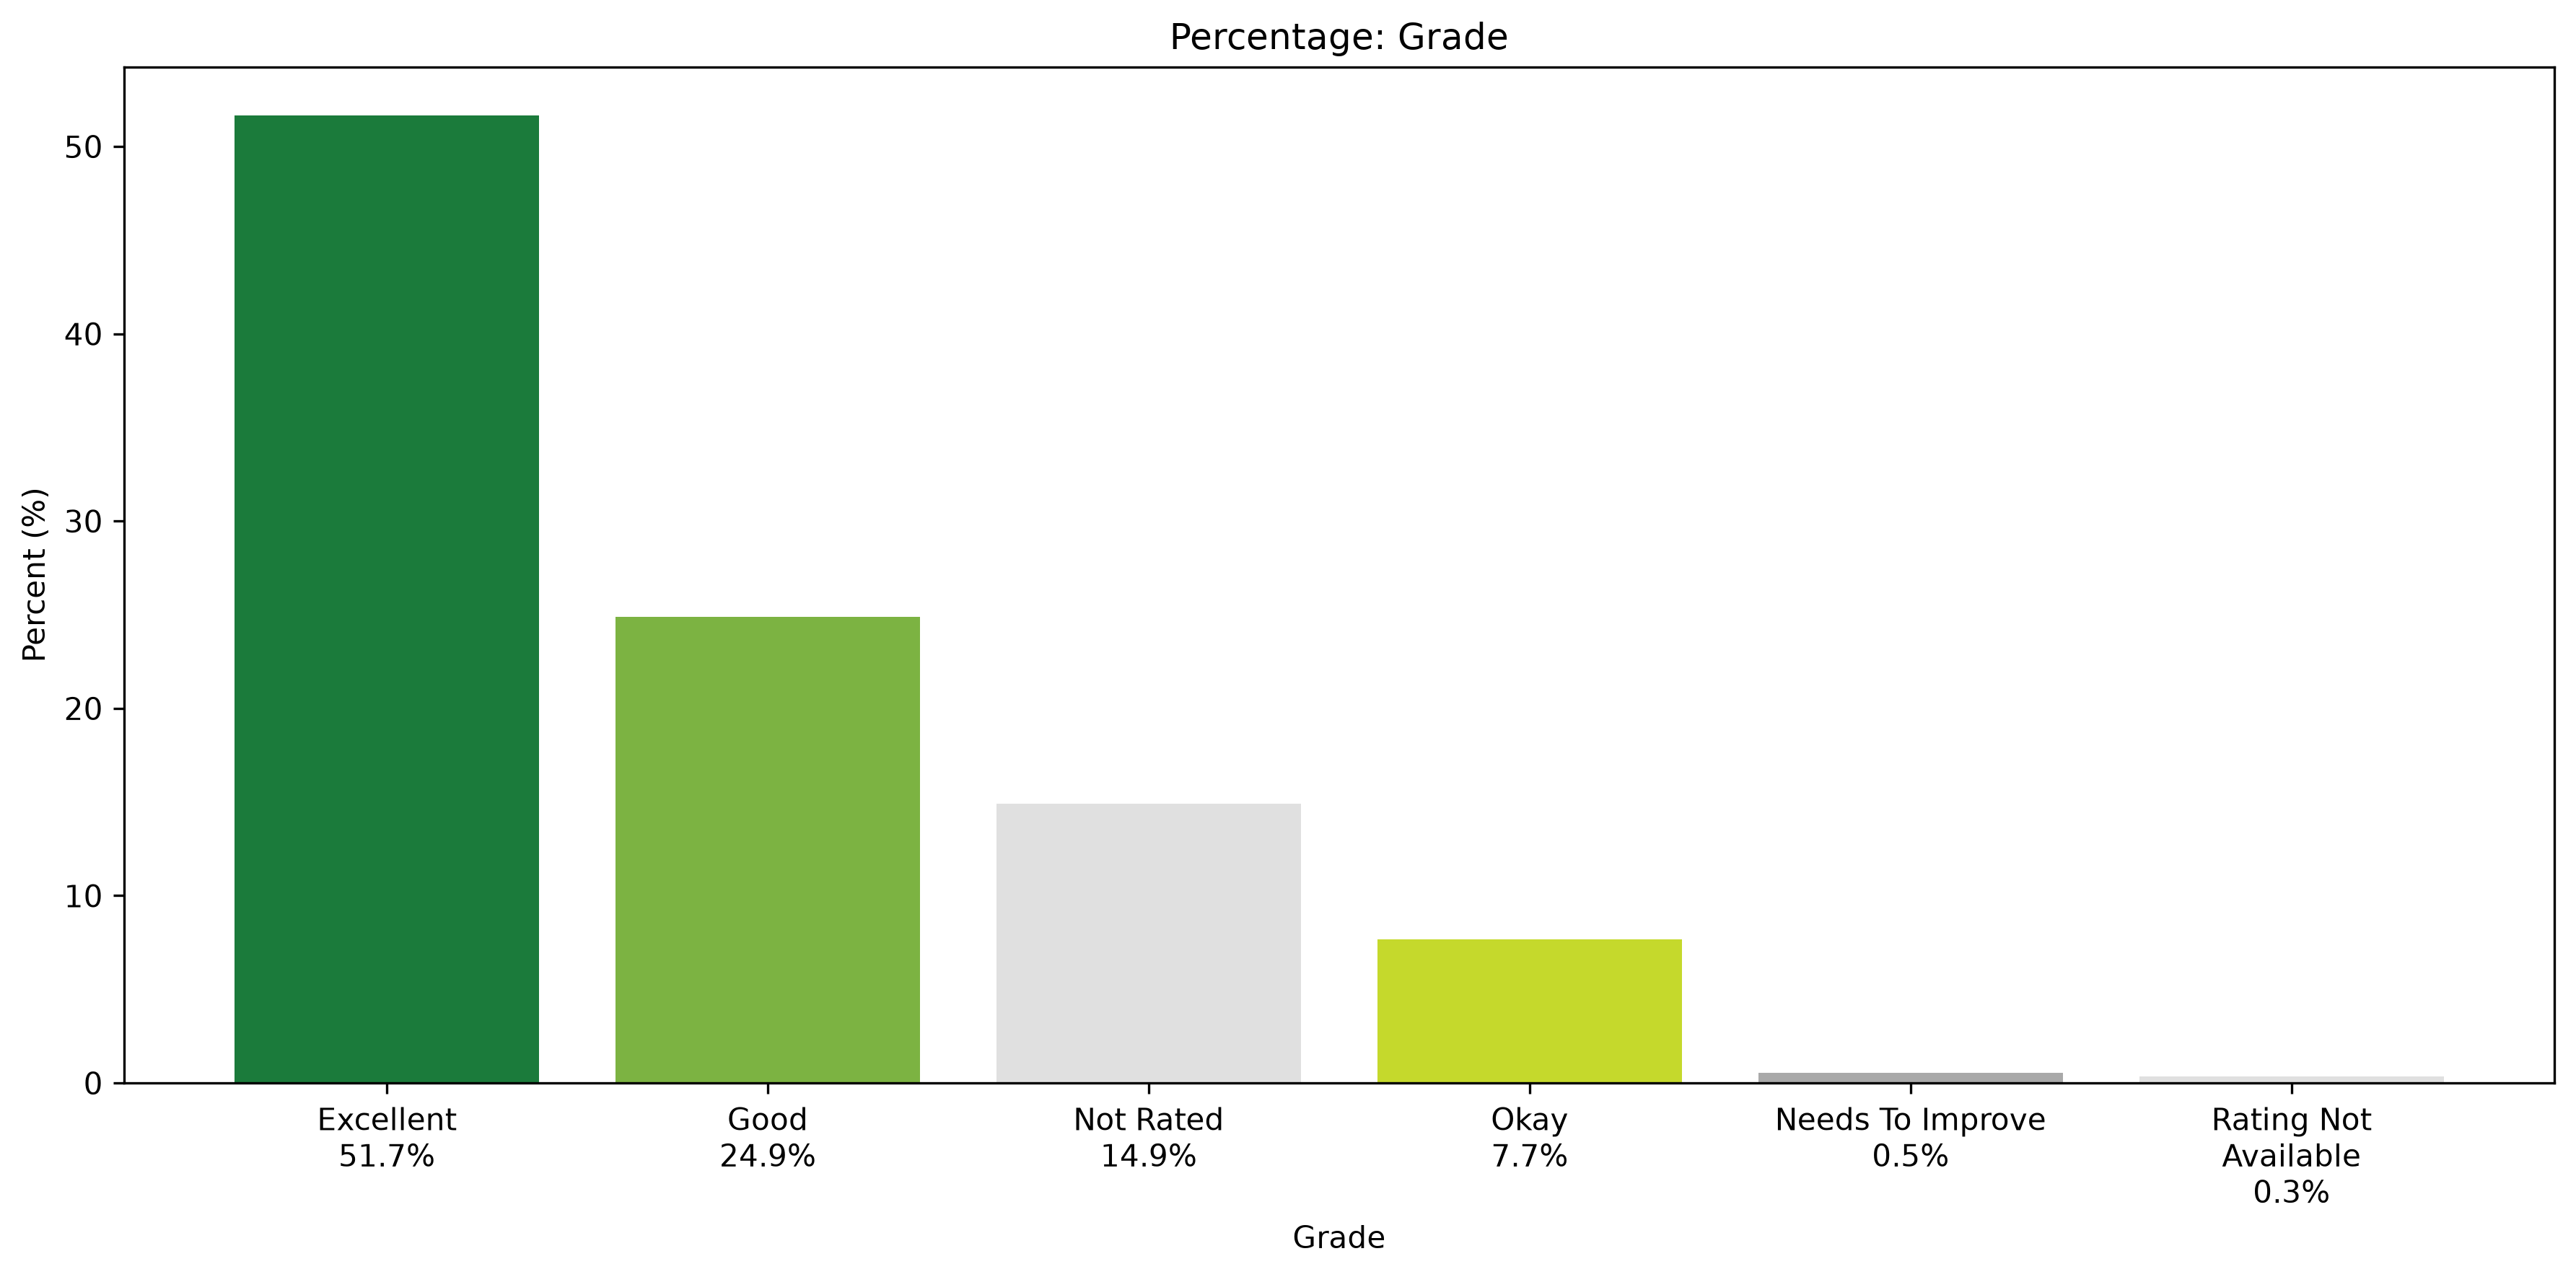

In [35]:
bar_chart(unique_serials_df,'Grade',top_n=6,mode='pct')

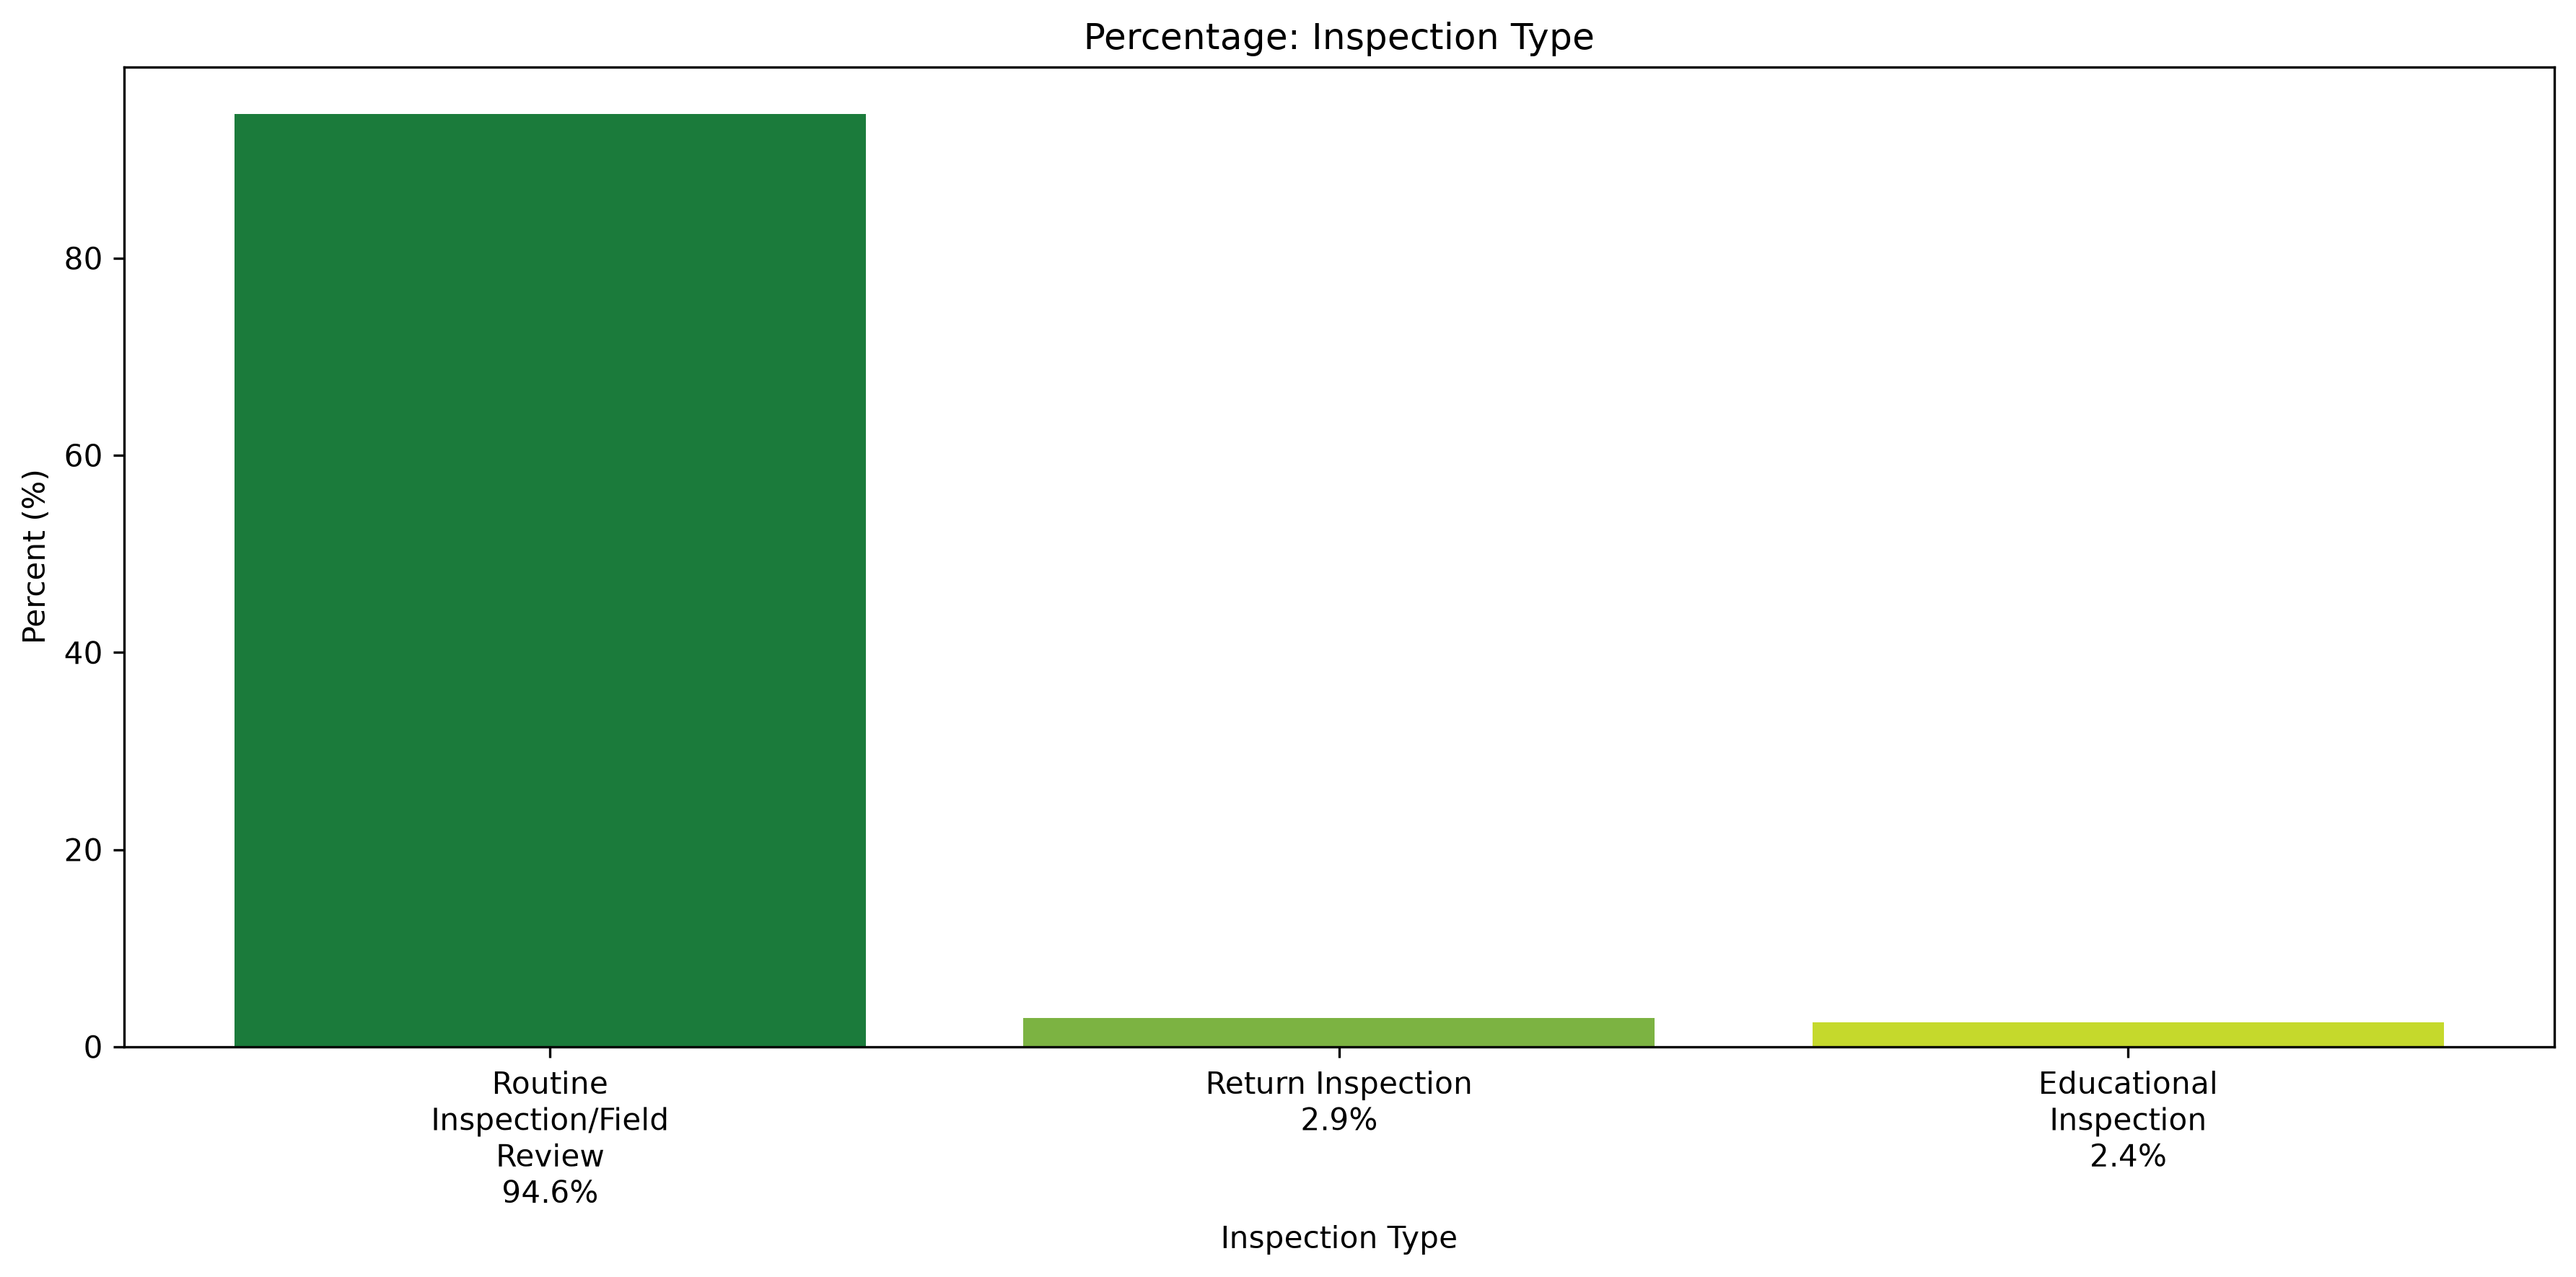

In [36]:
bar_chart(unique_serials_df,'Inspection Type',top_n=5,mode='pct')

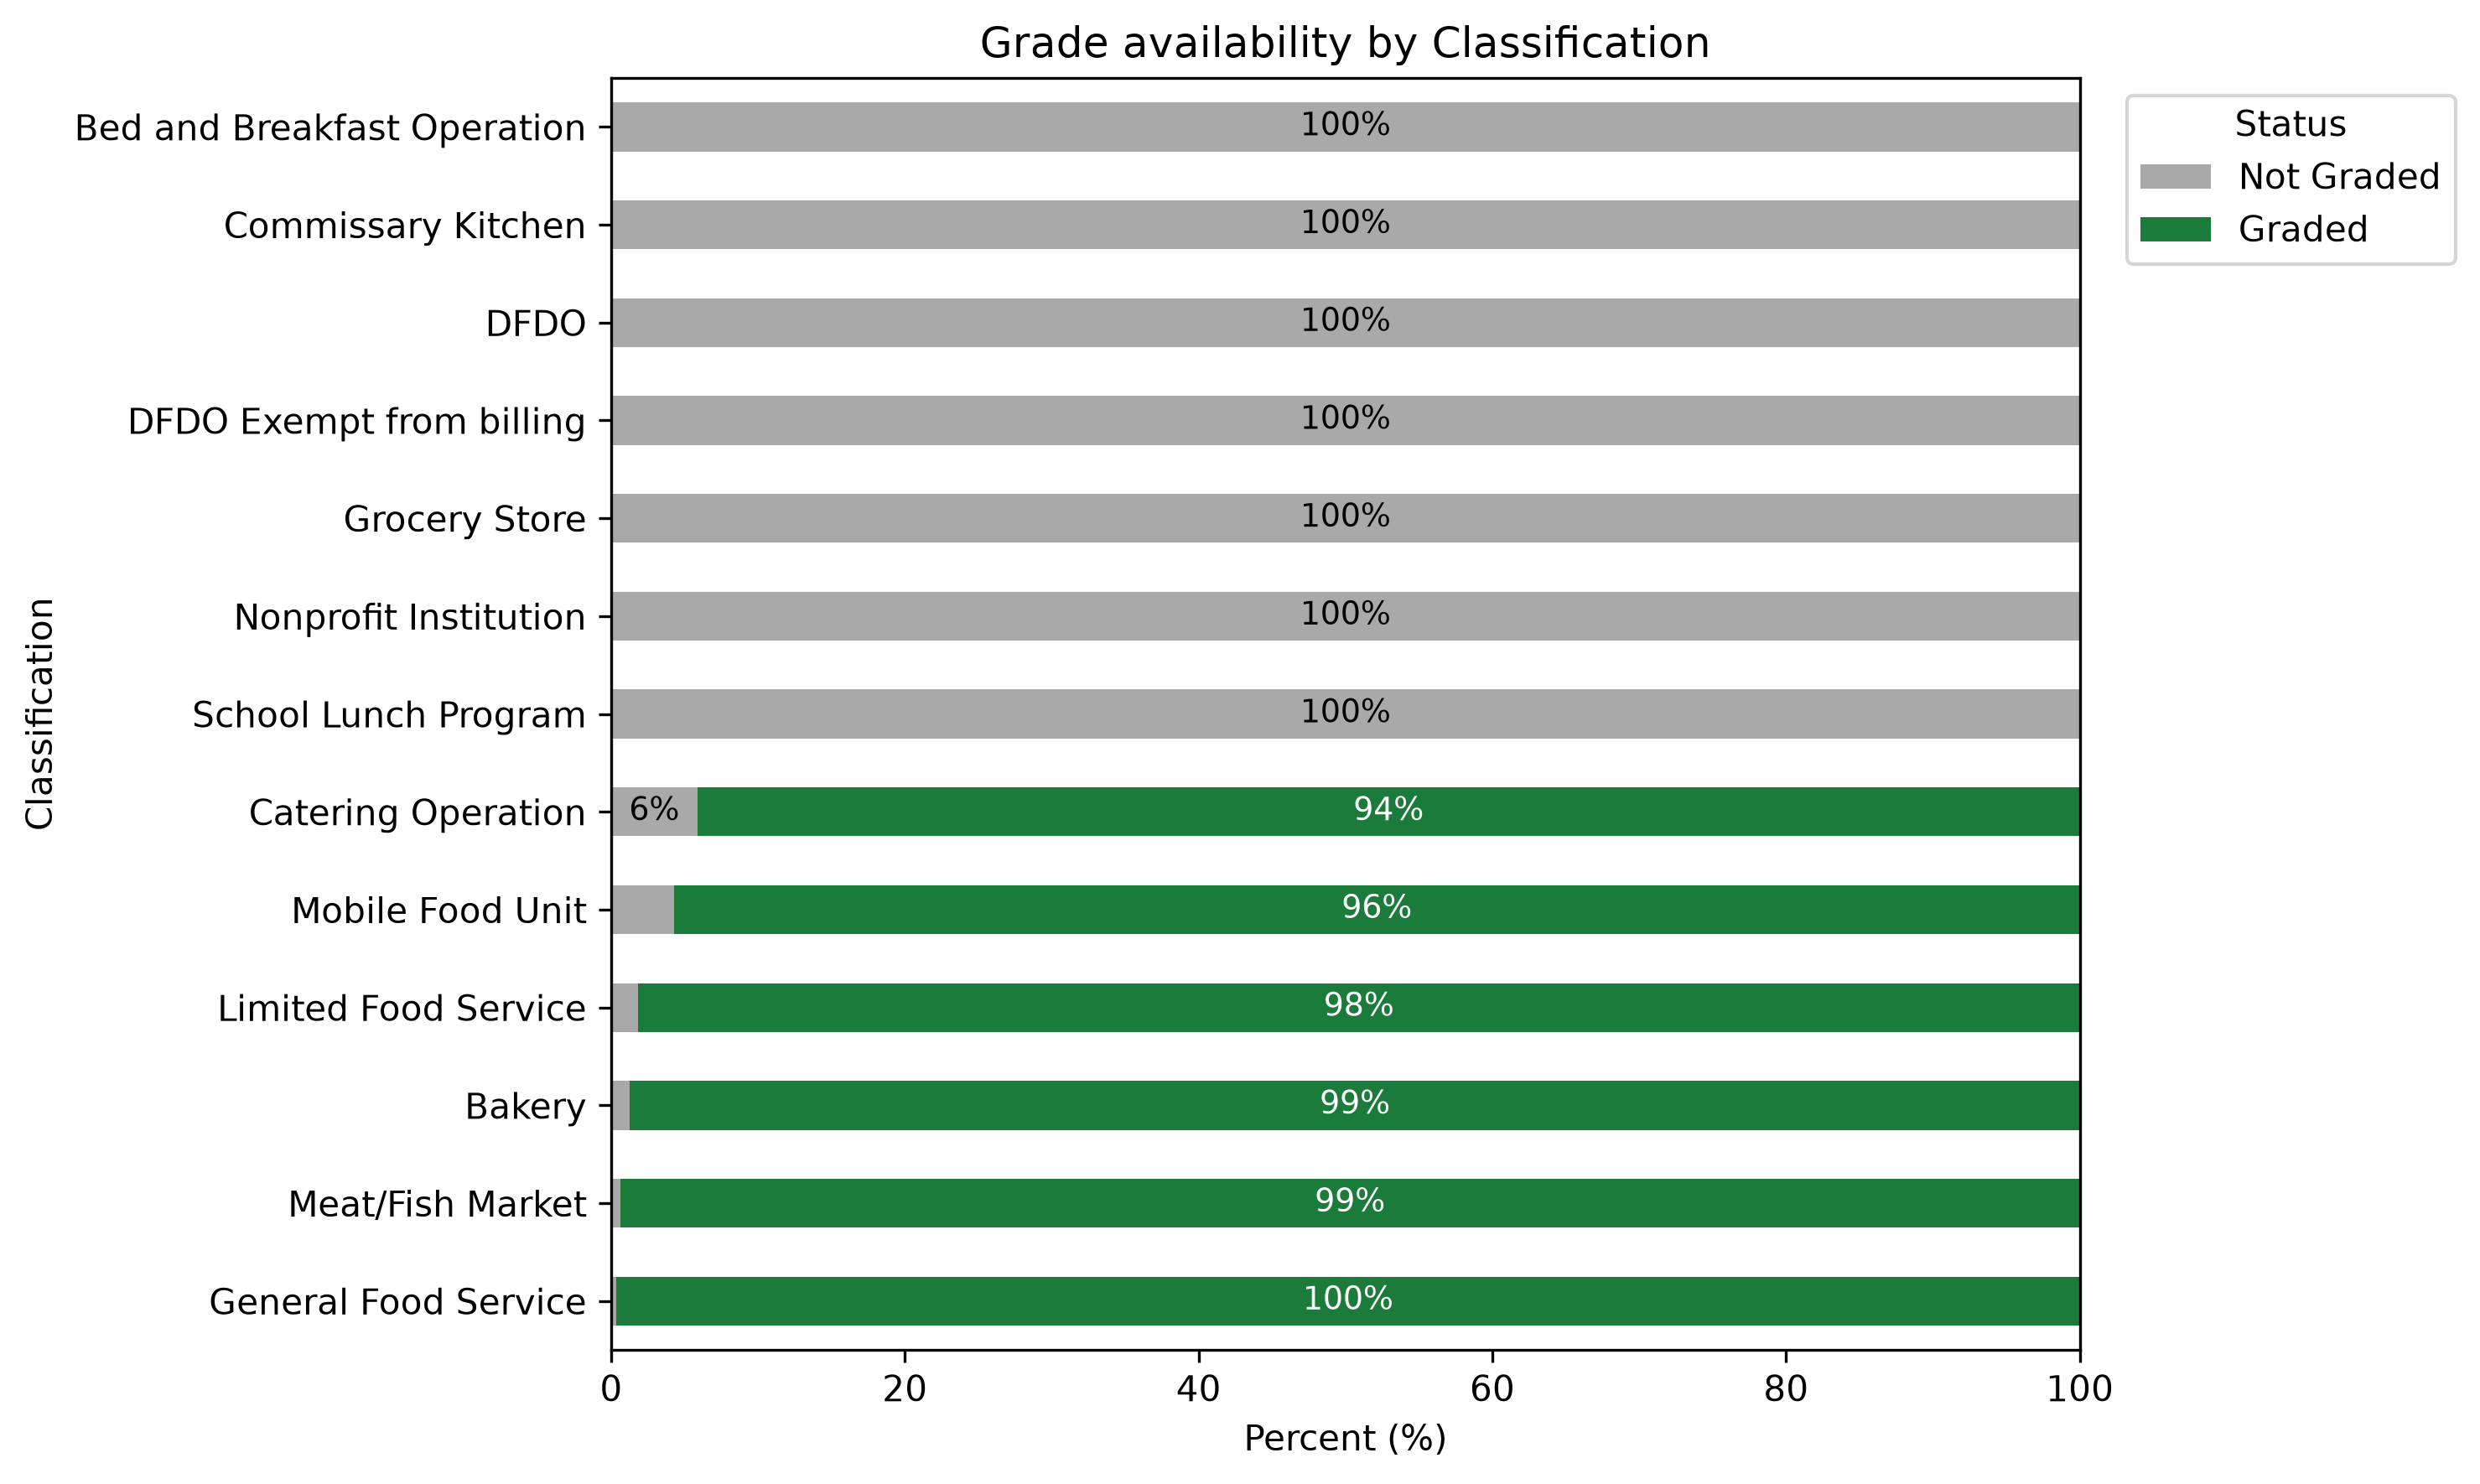

In [37]:
def bar_chart_grade_availability(df, top_n=13):
    temp = df.copy()
    temp['Graded'] = ~temp['Grade'].isin(['Not Rated', 'Rating Not Available'])

    table = pd.crosstab(temp['Classification'], temp['Graded'])
    table = table.rename(columns={True: 'Graded', False: 'Not Graded'})
    pct_table = table.div(table.sum(axis=1), axis=0) * 100

    sort_order = pct_table['Not Graded'].sort_values(ascending=False).head(top_n).index
    pct_table = pct_table.reindex(sort_order)

    colors = {'Graded': '#1B7B3B', 'Not Graded': '#A9A9A9'}

    fig, ax = plt.subplots(figsize=(10, 6), dpi=300)
    pct_table[['Not Graded', 'Graded']].plot(kind='barh', stacked=True,
             color=[colors['Not Graded'], colors['Graded']], ax=ax)
    ax.invert_yaxis()  # highest not-graded % on top

    for container, col in zip(ax.containers, ['Not Graded', 'Graded']):
        labels = [f"{v:.0f}%" if v >= 5 else "" for v in pct_table[col]]
        ax.bar_label(container, labels=labels, label_type='center',
                     fontsize=9, color=_text_color_for(colors[col]))

    ax.set_xlabel("Percent (%)")
    ax.set_ylabel("Classification")
    ax.set_title("Grade availability by Classification")
    ax.legend(title='Status', bbox_to_anchor=(1.02, 1), loc='upper left')
    plt.tight_layout()
    plt.show()
bar_chart_grade_availability(unique_serials_df)

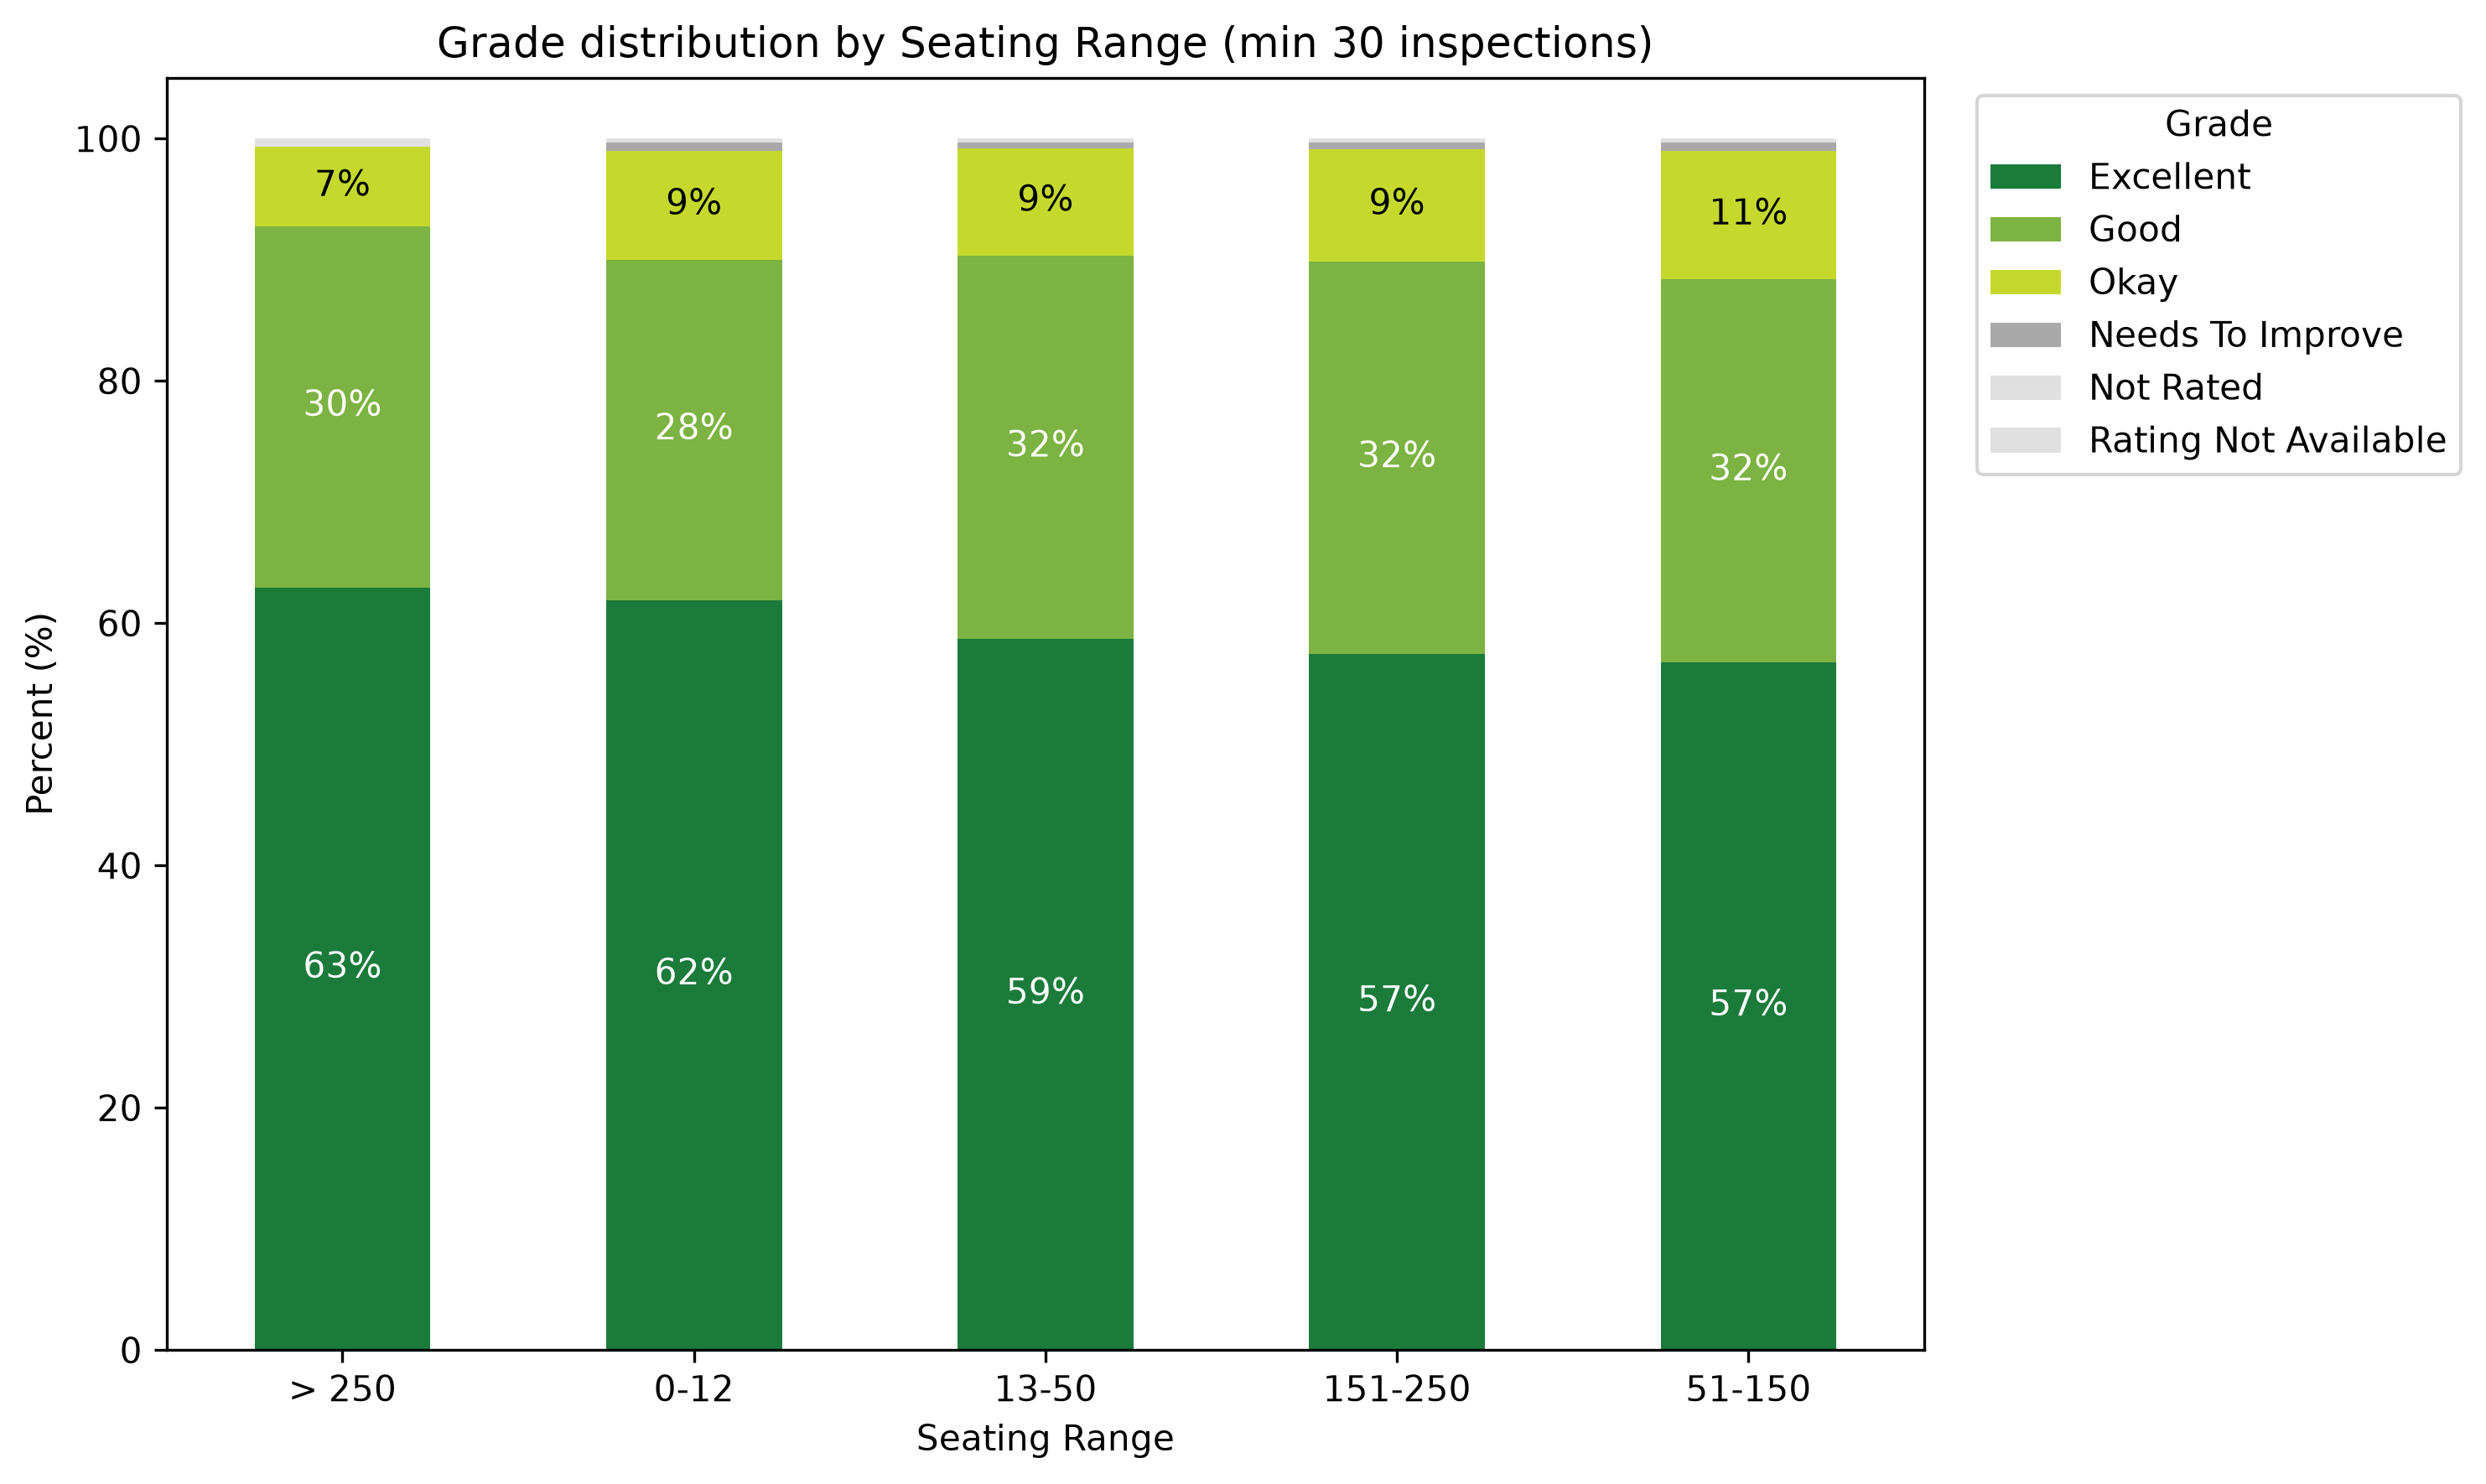

In [38]:
bar_chart_by_grade(unique_serials_df,'Seating Range',top_n=5)

In [39]:
unique_serials_df.Grade.unique()

<StringArray>
[           'Excellent',                 'Okay',                 'Good',
            'Not Rated', 'Rating Not Available',     'Needs To Improve']
Length: 6, dtype: str

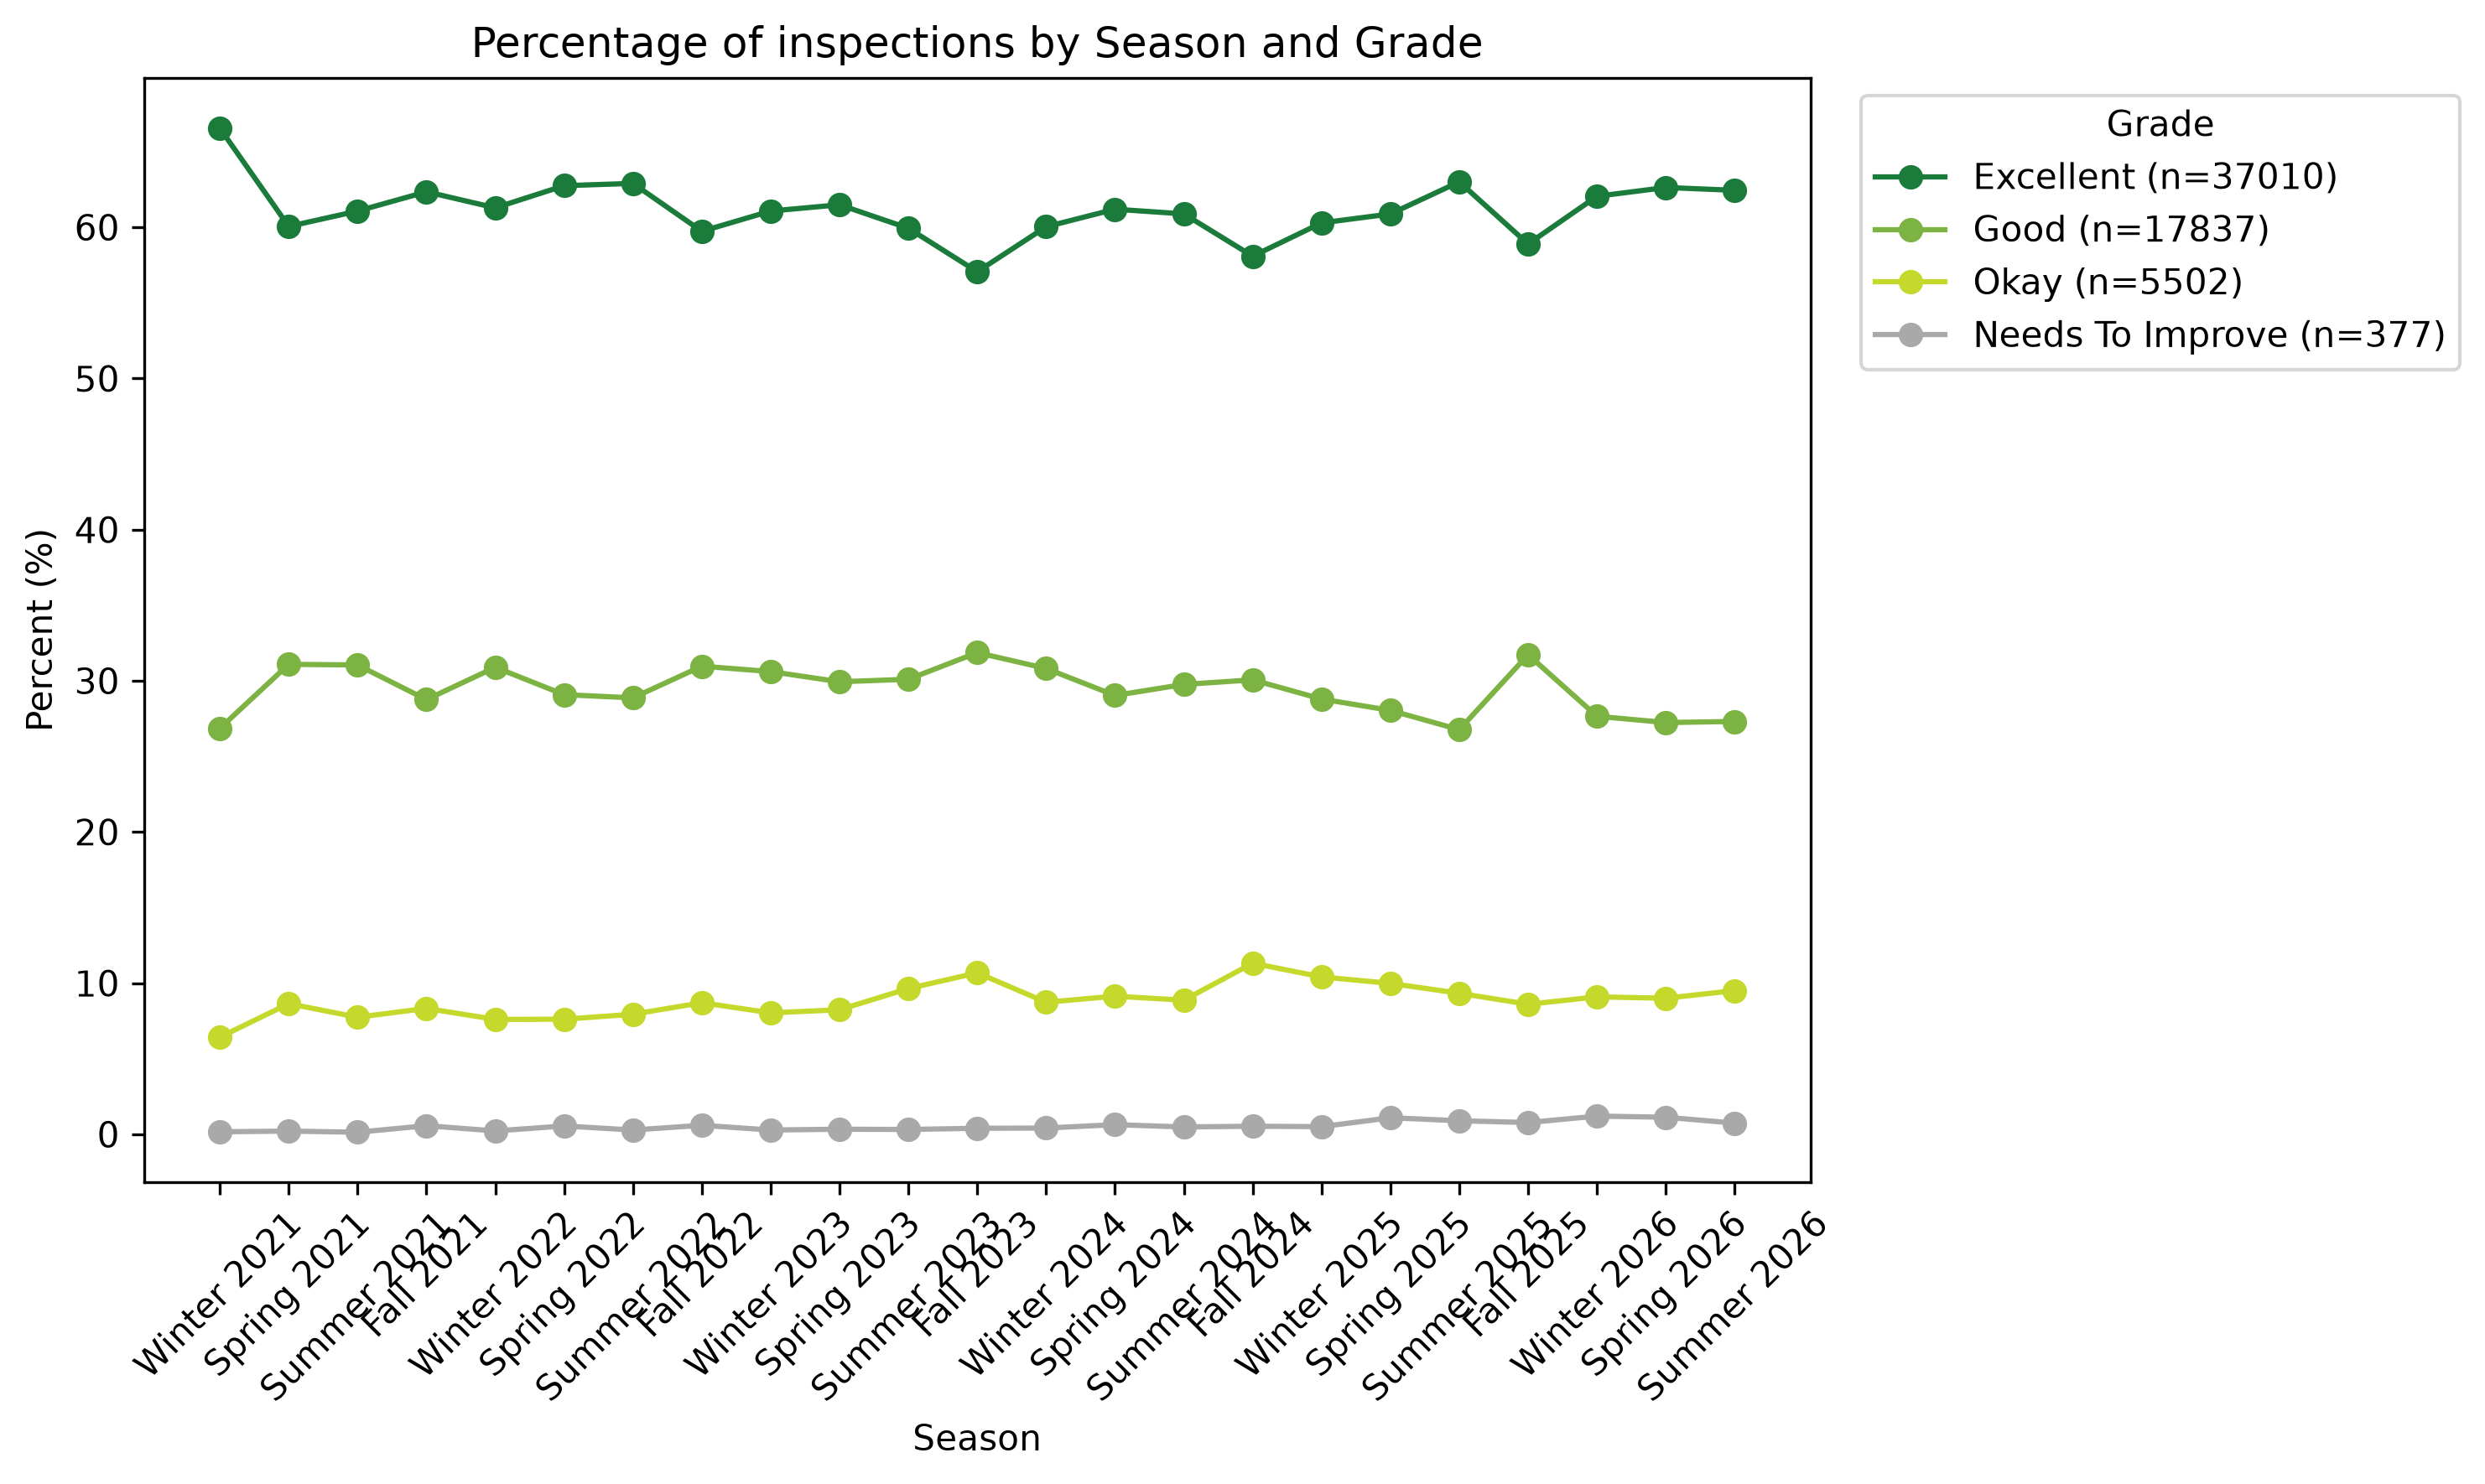

In [40]:
line_chart_plot(unique_serials_df[~unique_serials_df['Grade'].isin(['Not Rated', 'Rating Not Available'])],date_col='Inspection Date',freq='season',mode='pct',by='Grade')

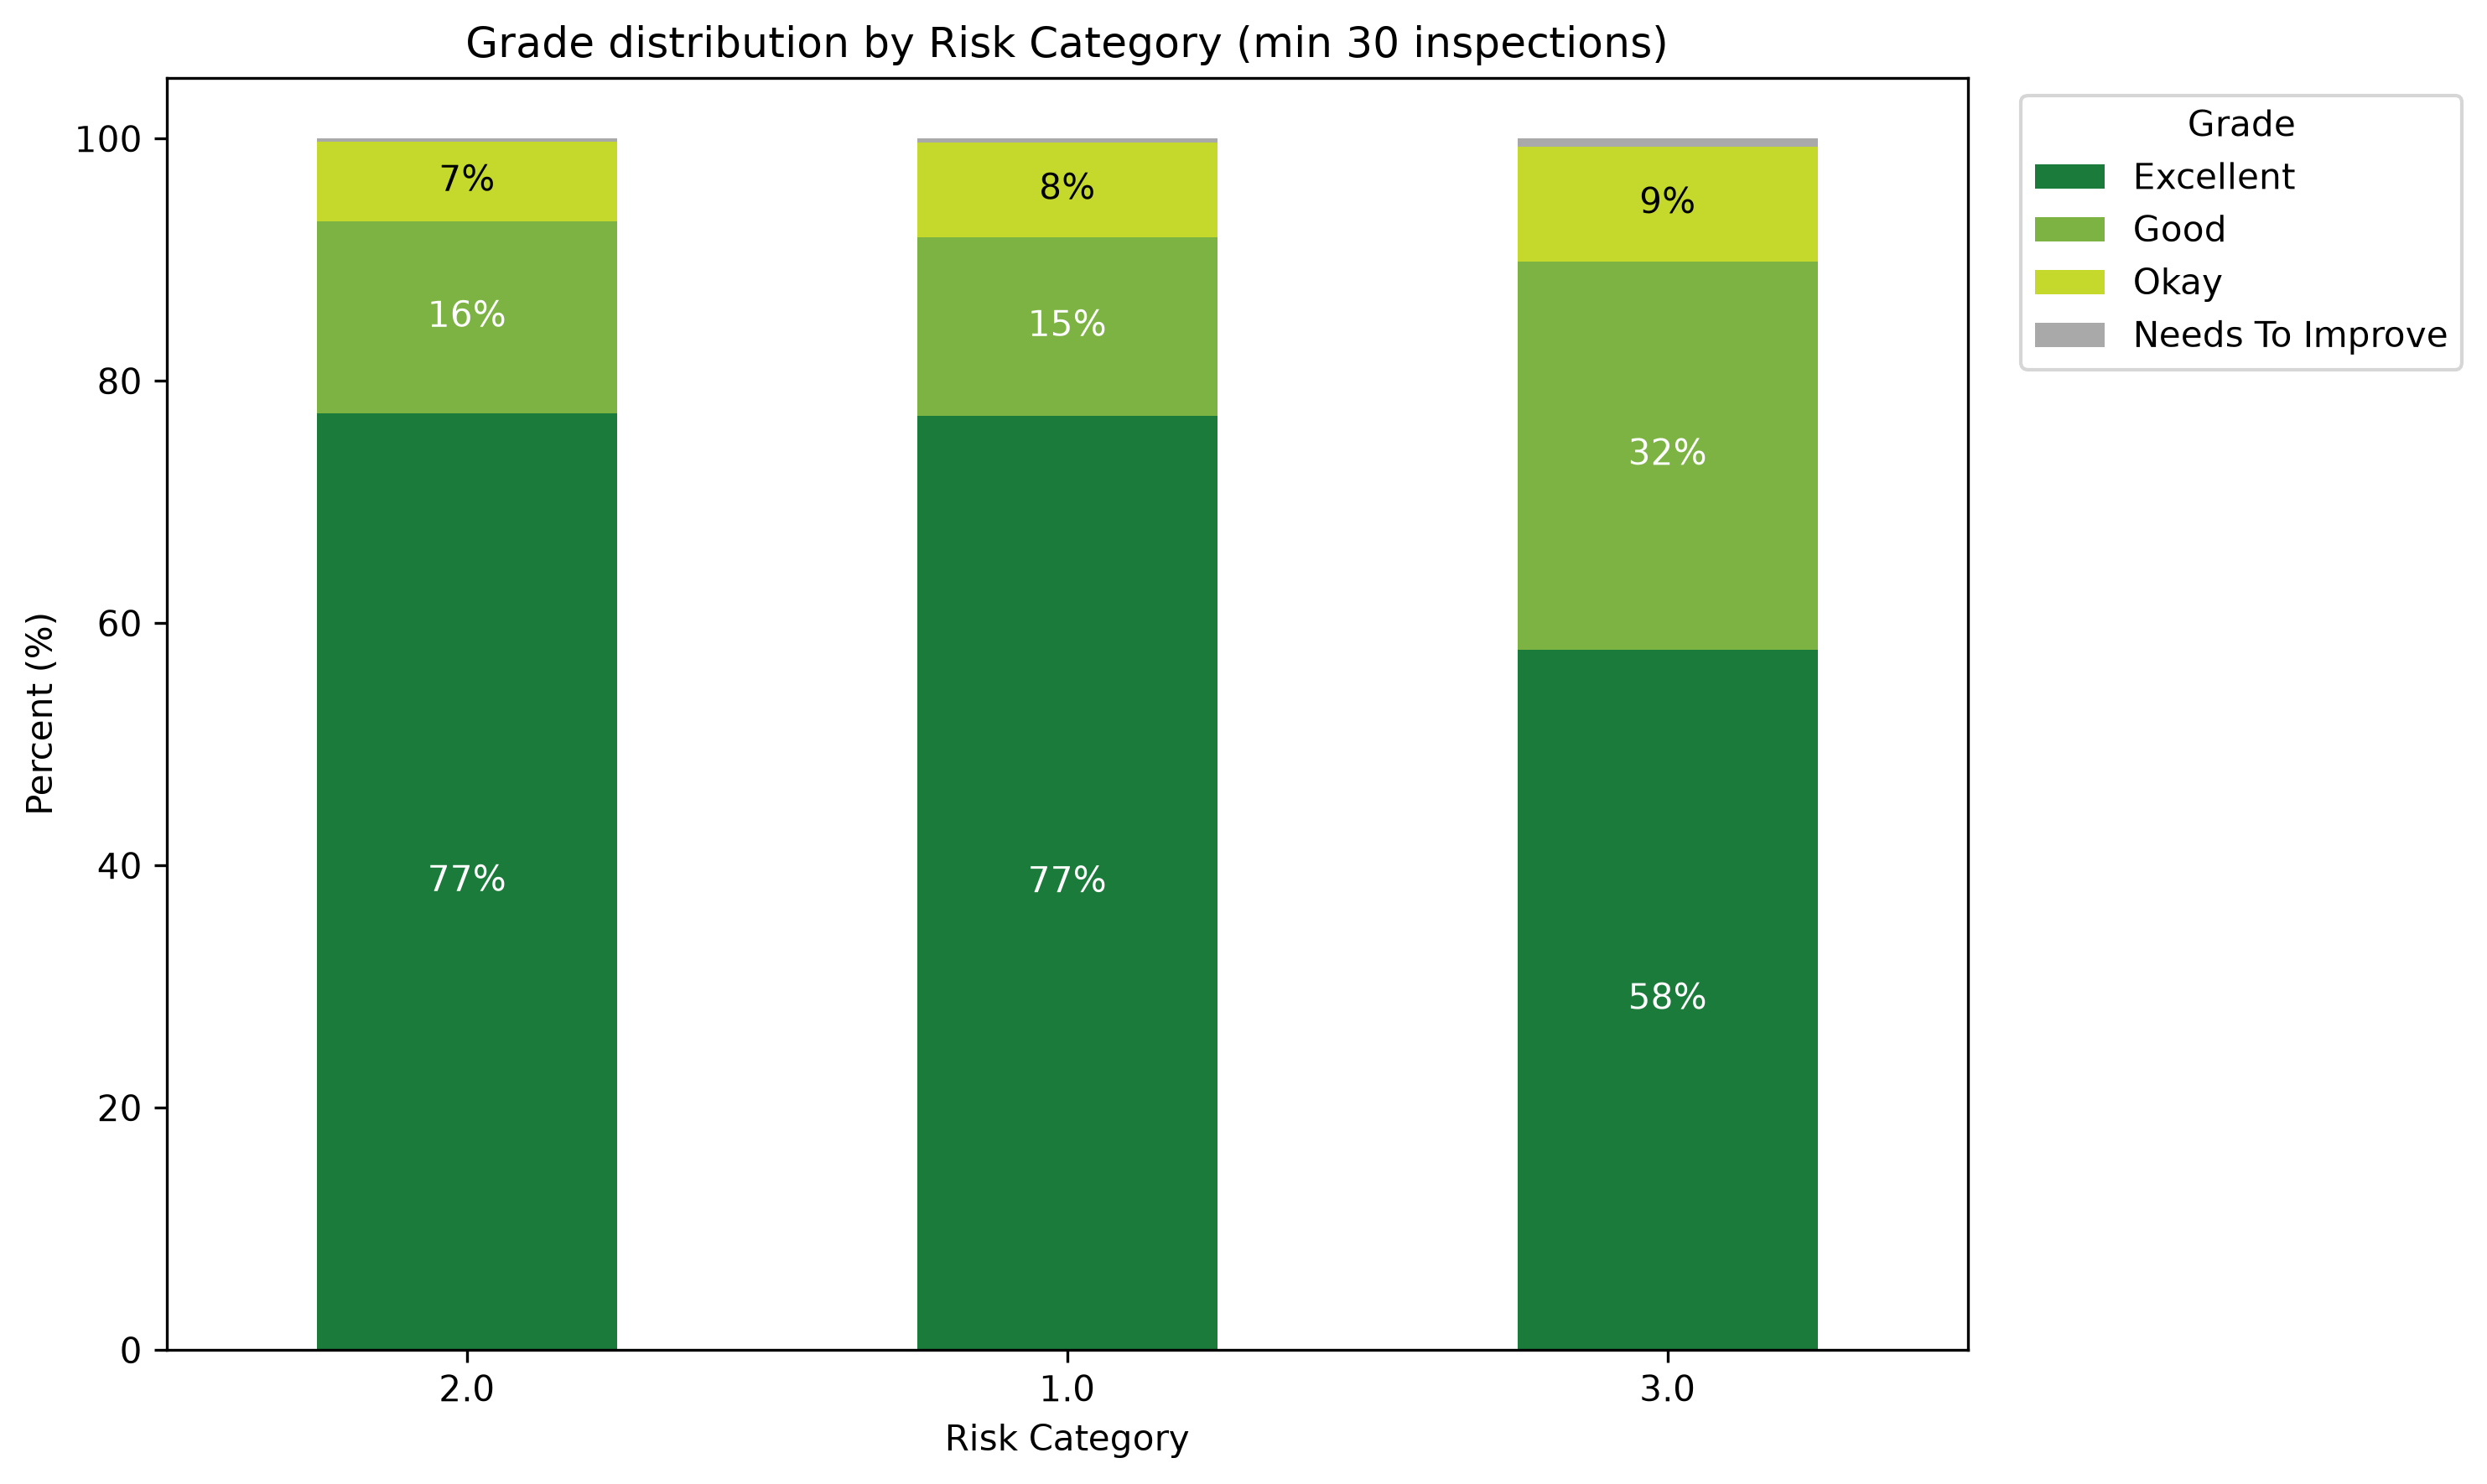

In [41]:
temp_df = unique_serials_df[~unique_serials_df['Grade'].isin(['Not Rated', 'Rating Not Available'])]

bar_chart_by_grade(temp_df,'Risk Category',top_n=5)

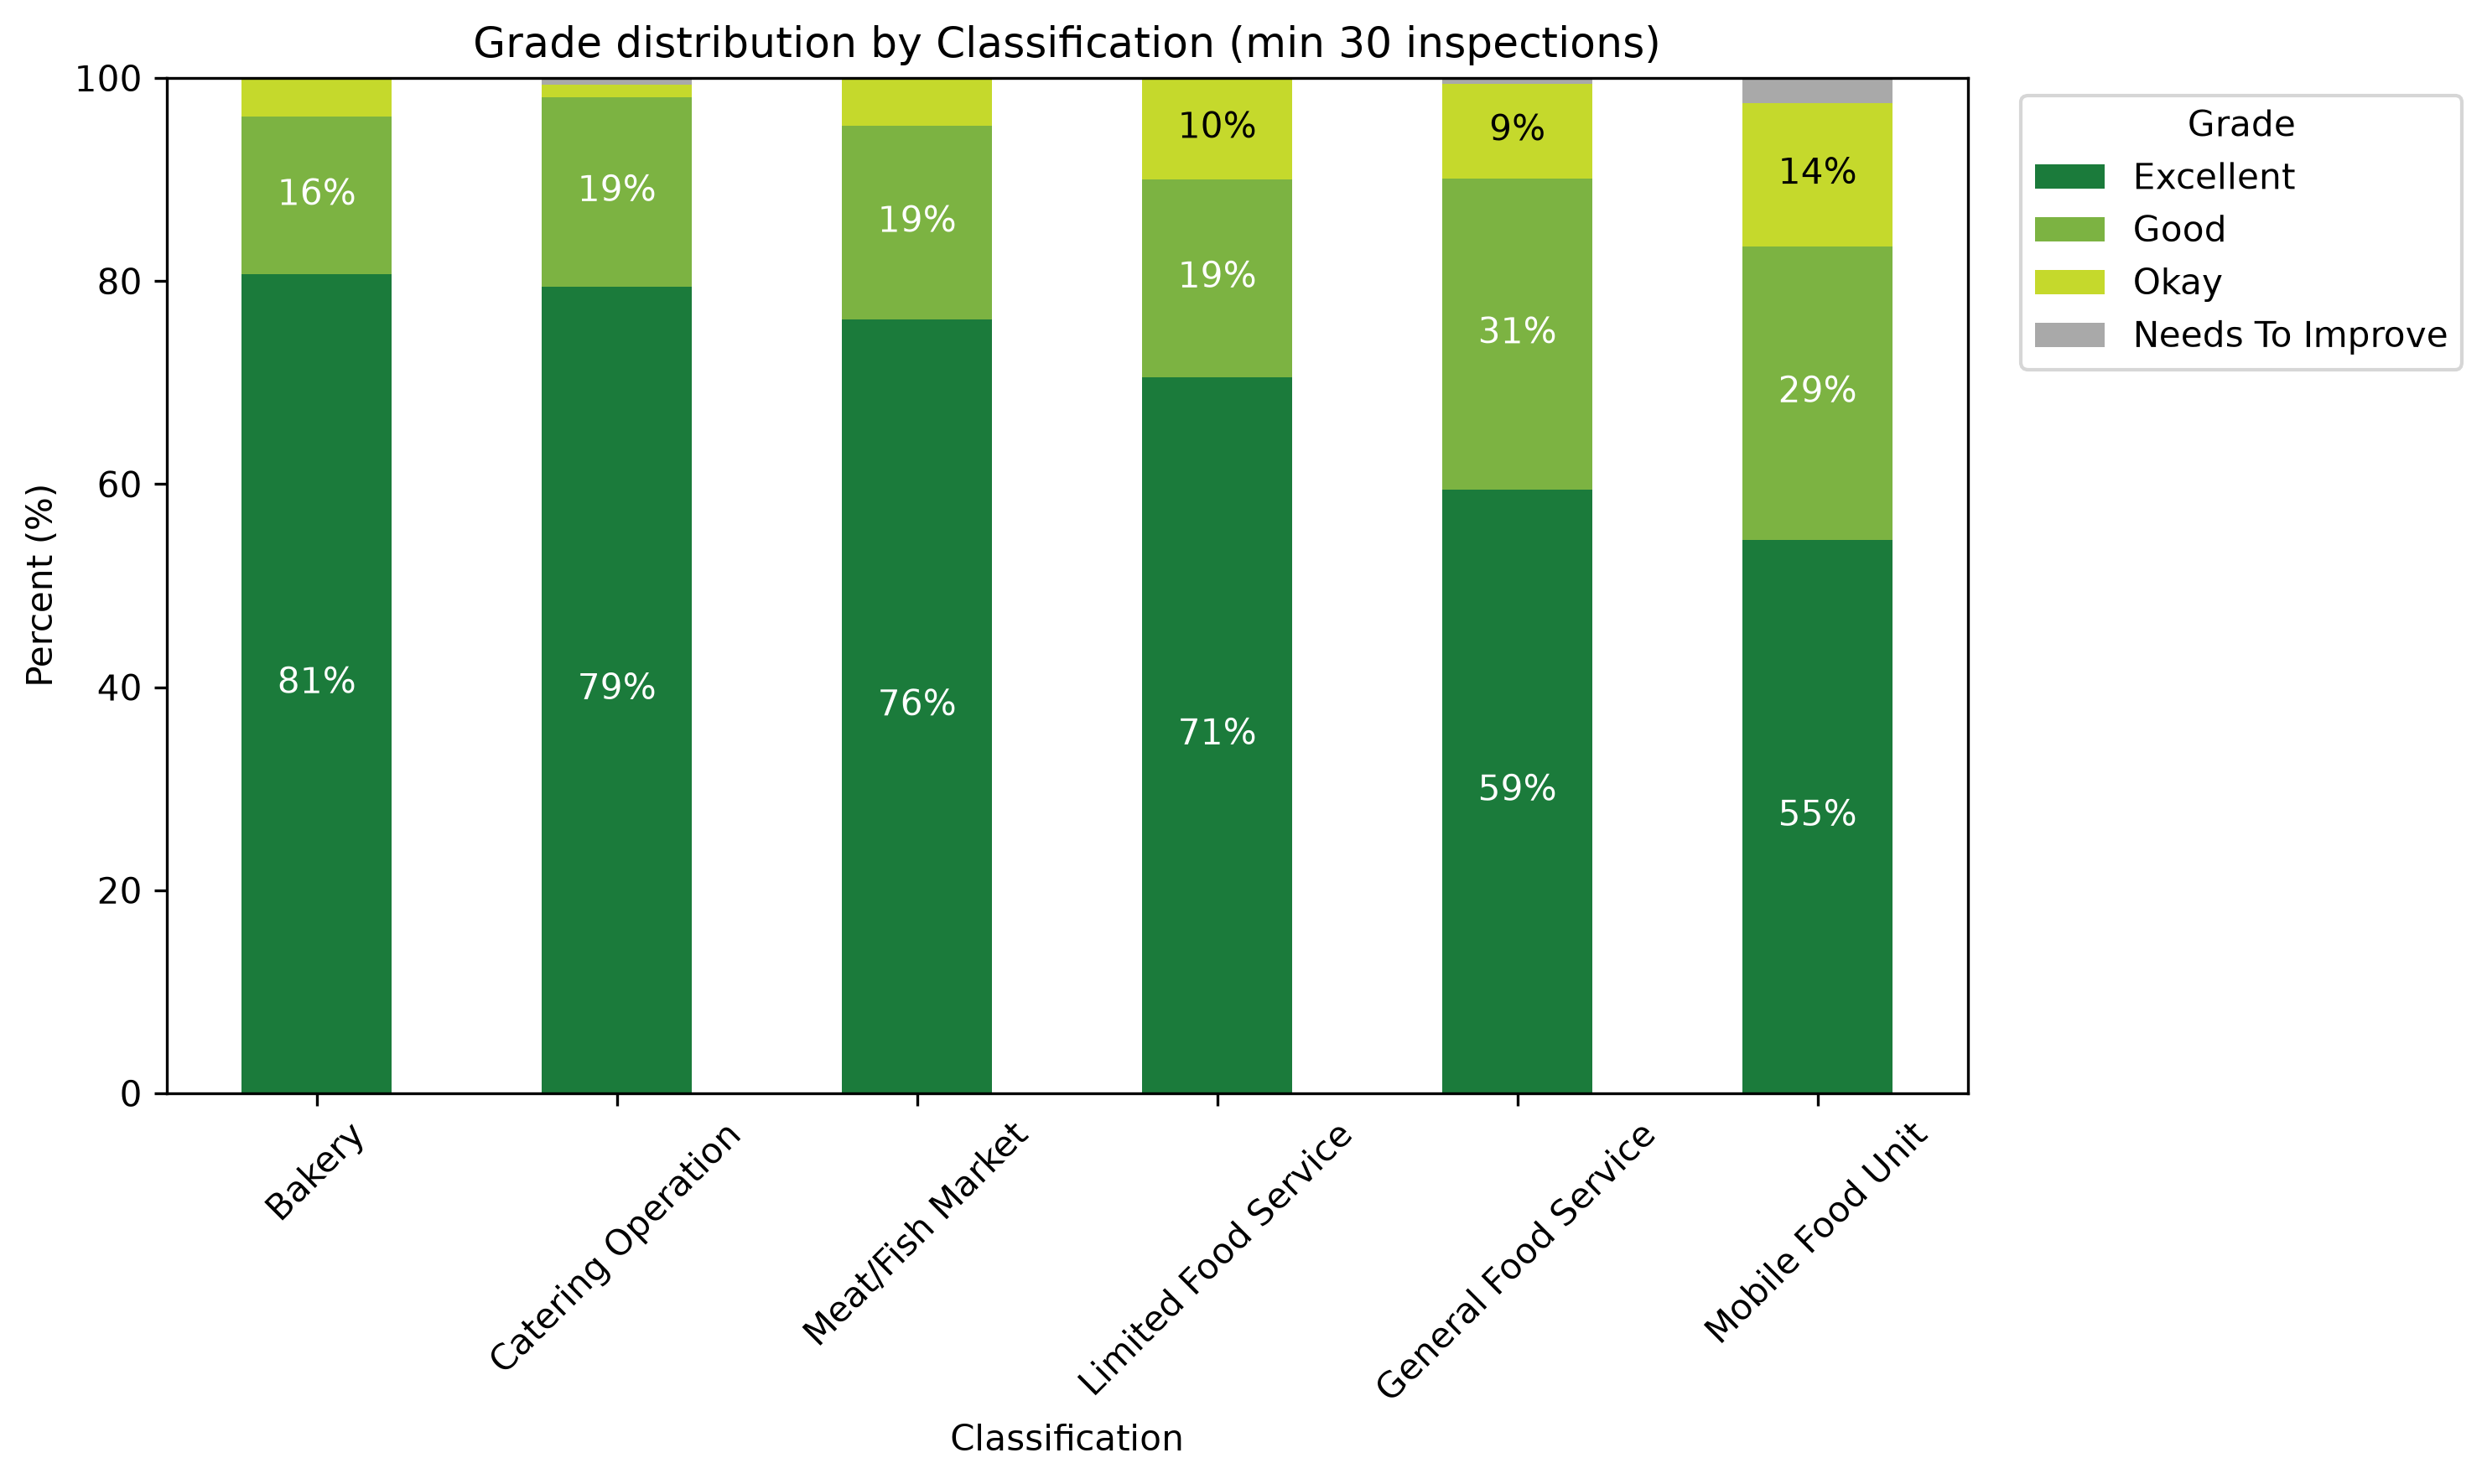

In [42]:
temp_df = unique_serials_df[~unique_serials_df['Grade'].isin(['Not Rated', 'Rating Not Available'])]
bar_chart_by_grade(temp_df,'Classification',top_n=10,rotation=45)


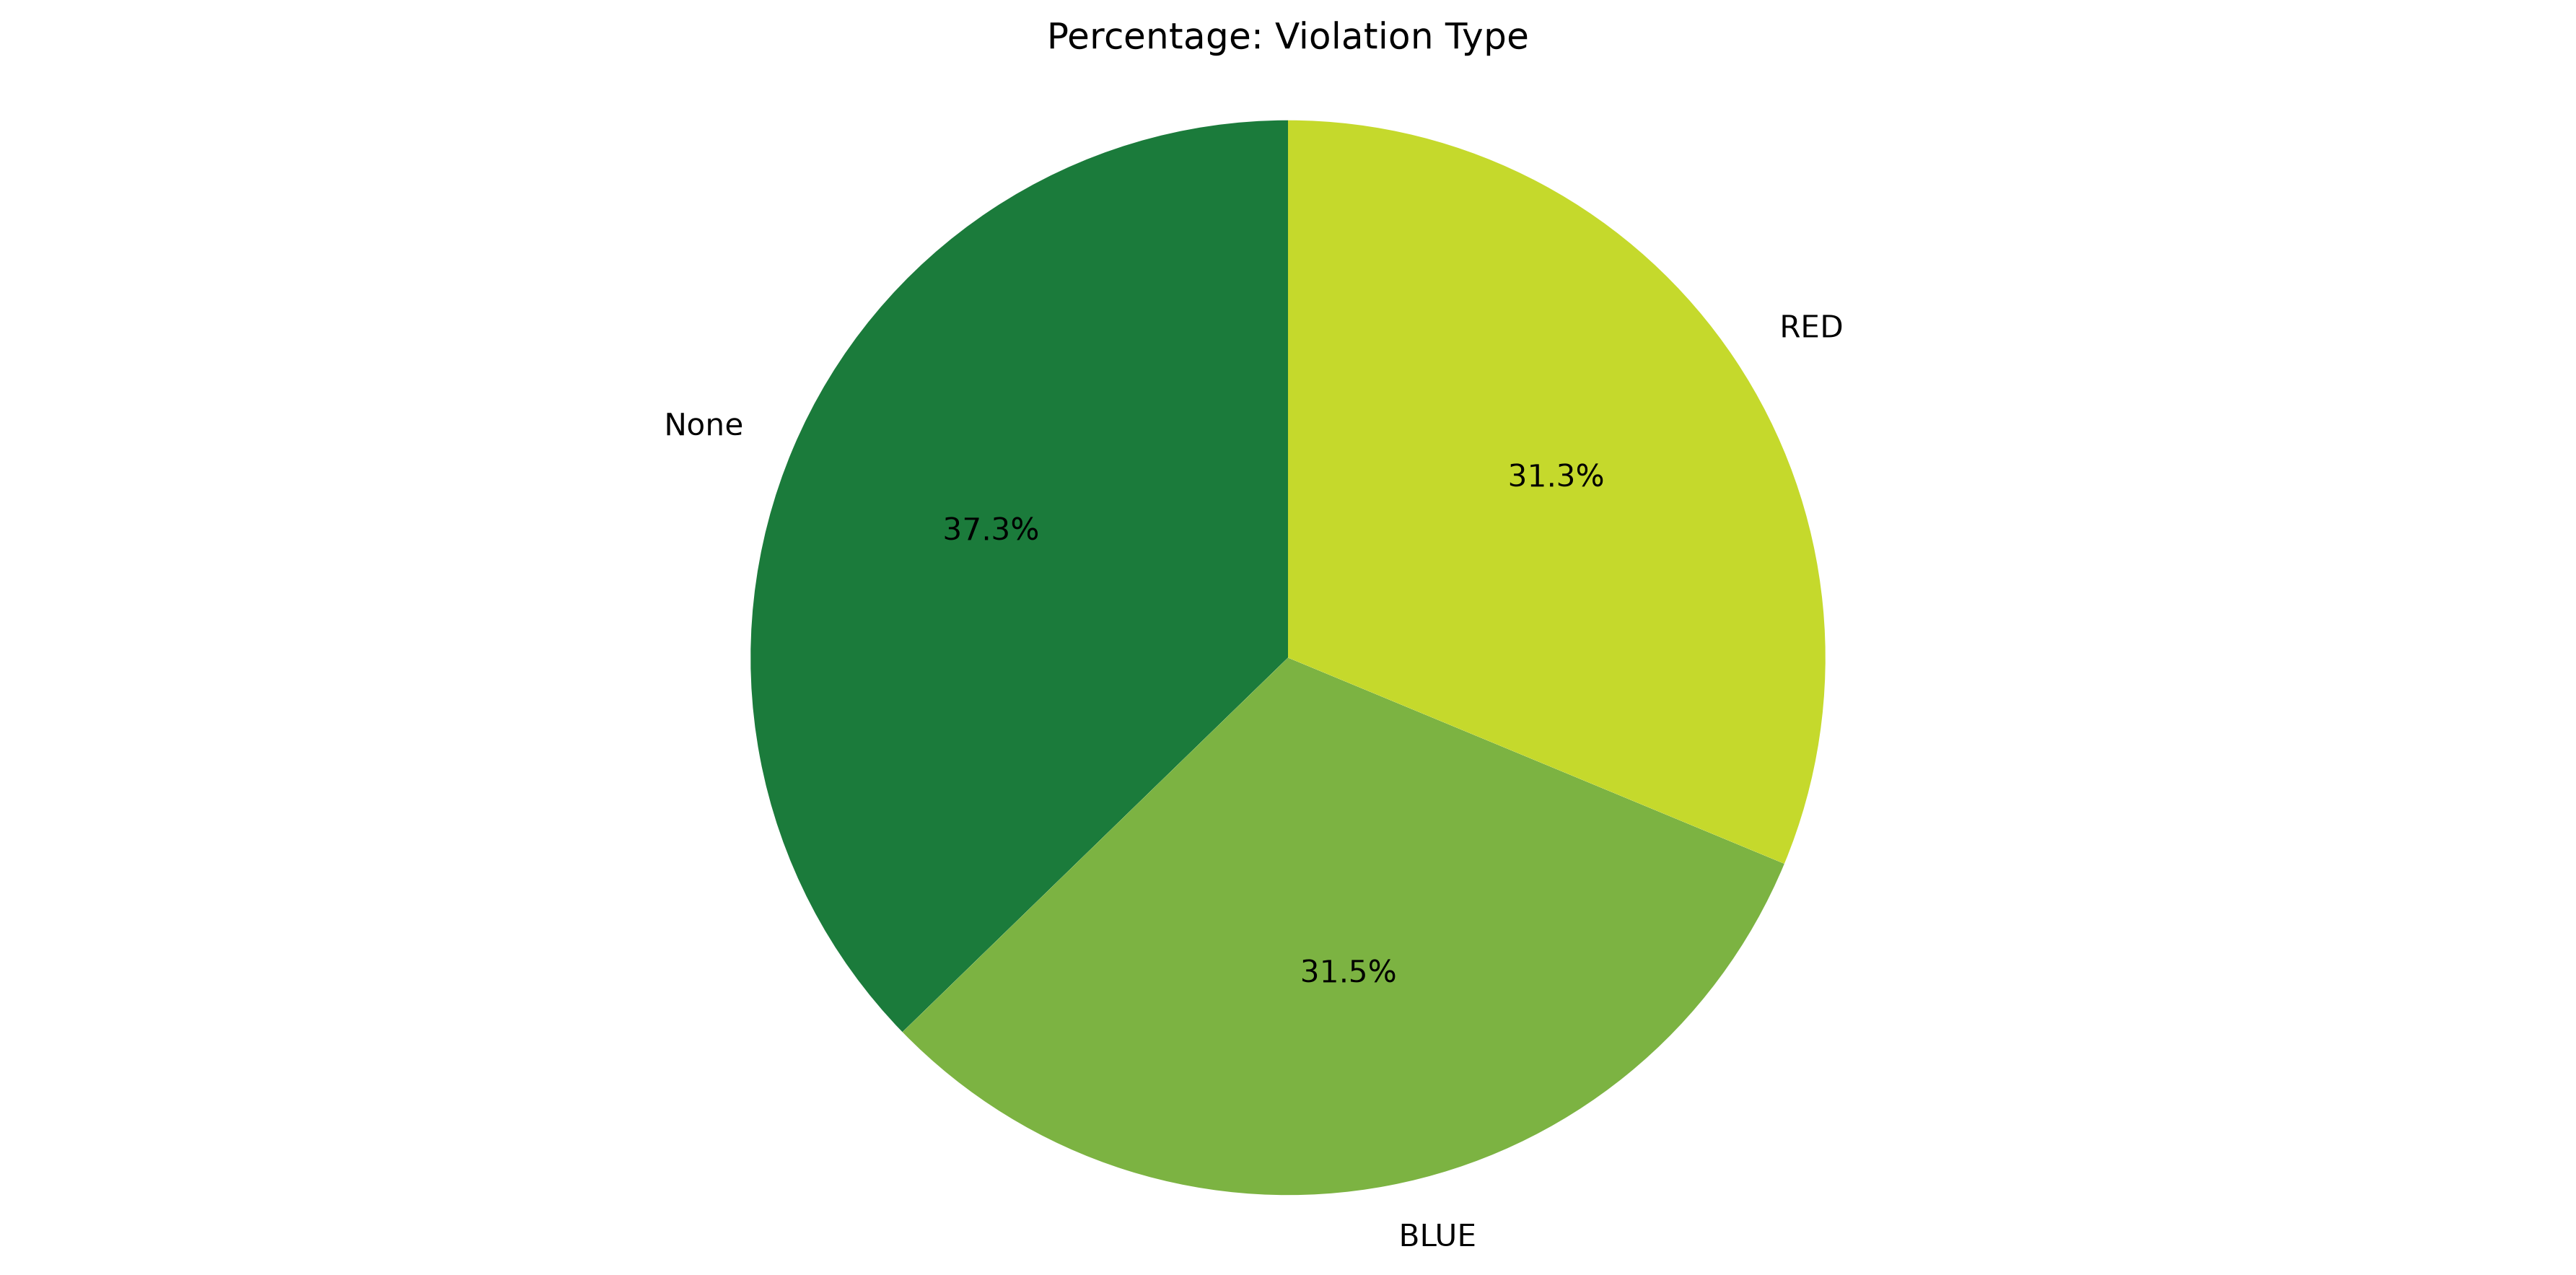

In [43]:
pie_chart(df, 'Violation Type', top_n=3, mode='pct')


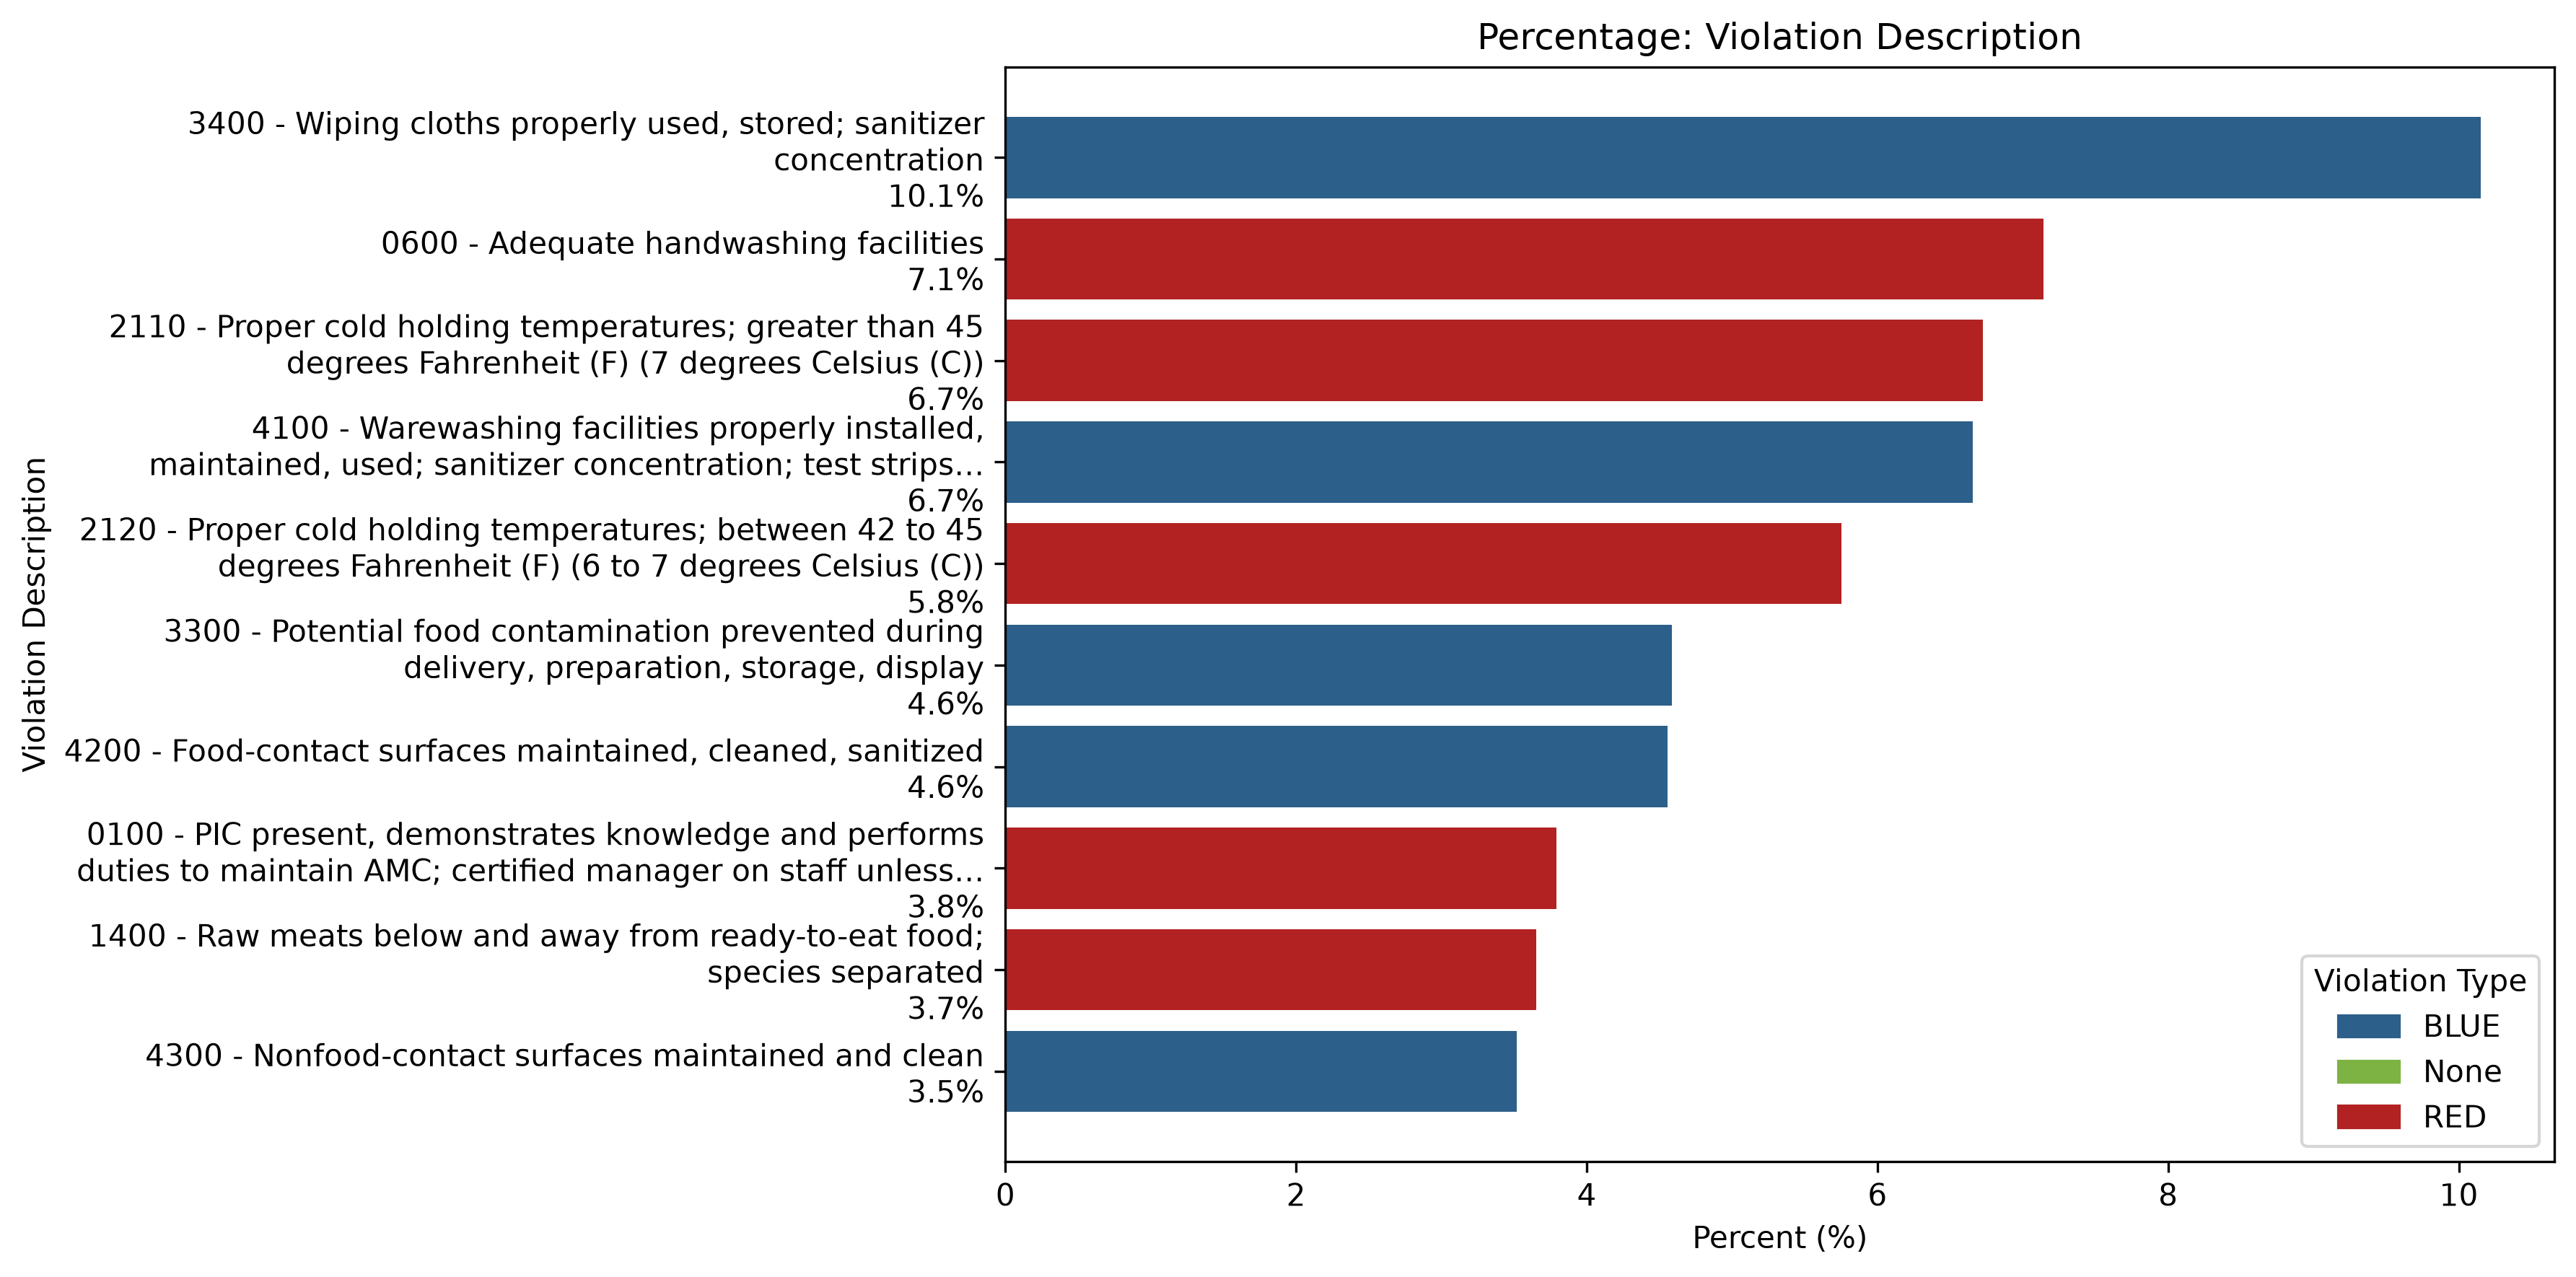

In [44]:
# bar_chart(df,'Violation Description',top_n=8,mode='pct',horizontal=True,wrap_width=60,wrap_height=2)

bar_chart(df, 'Violation Description', top_n=10, mode='pct', horizontal=True, wrap_width=60, wrap_height=2,
          color_by='Violation Type', color_map={'RED': '#B22222', 'BLUE': '#2C5F8A'})


## Repetitive Violation

In [45]:
df['is_repeat'] = df.groupby(['Business_ID', 'Violation Description'])['Business_ID'].transform('count') > 1

In [46]:
repeat_df=df[df['is_repeat']==True]
repeat_pct = round(repeat_df['Business_ID'].nunique()/df['Business_ID'].nunique(),4)*100
print(f"There are {repeat_pct}% of store have repeat violation")

There are 41.24% of store have repeat violation


In [47]:
repeat_inspections = df[df['is_repeat'] == True].drop_duplicates(subset='Inspection_Serial_Num')
nonrepeat_inspections = df[df['is_repeat'] == False].drop_duplicates(subset='Inspection_Serial_Num')

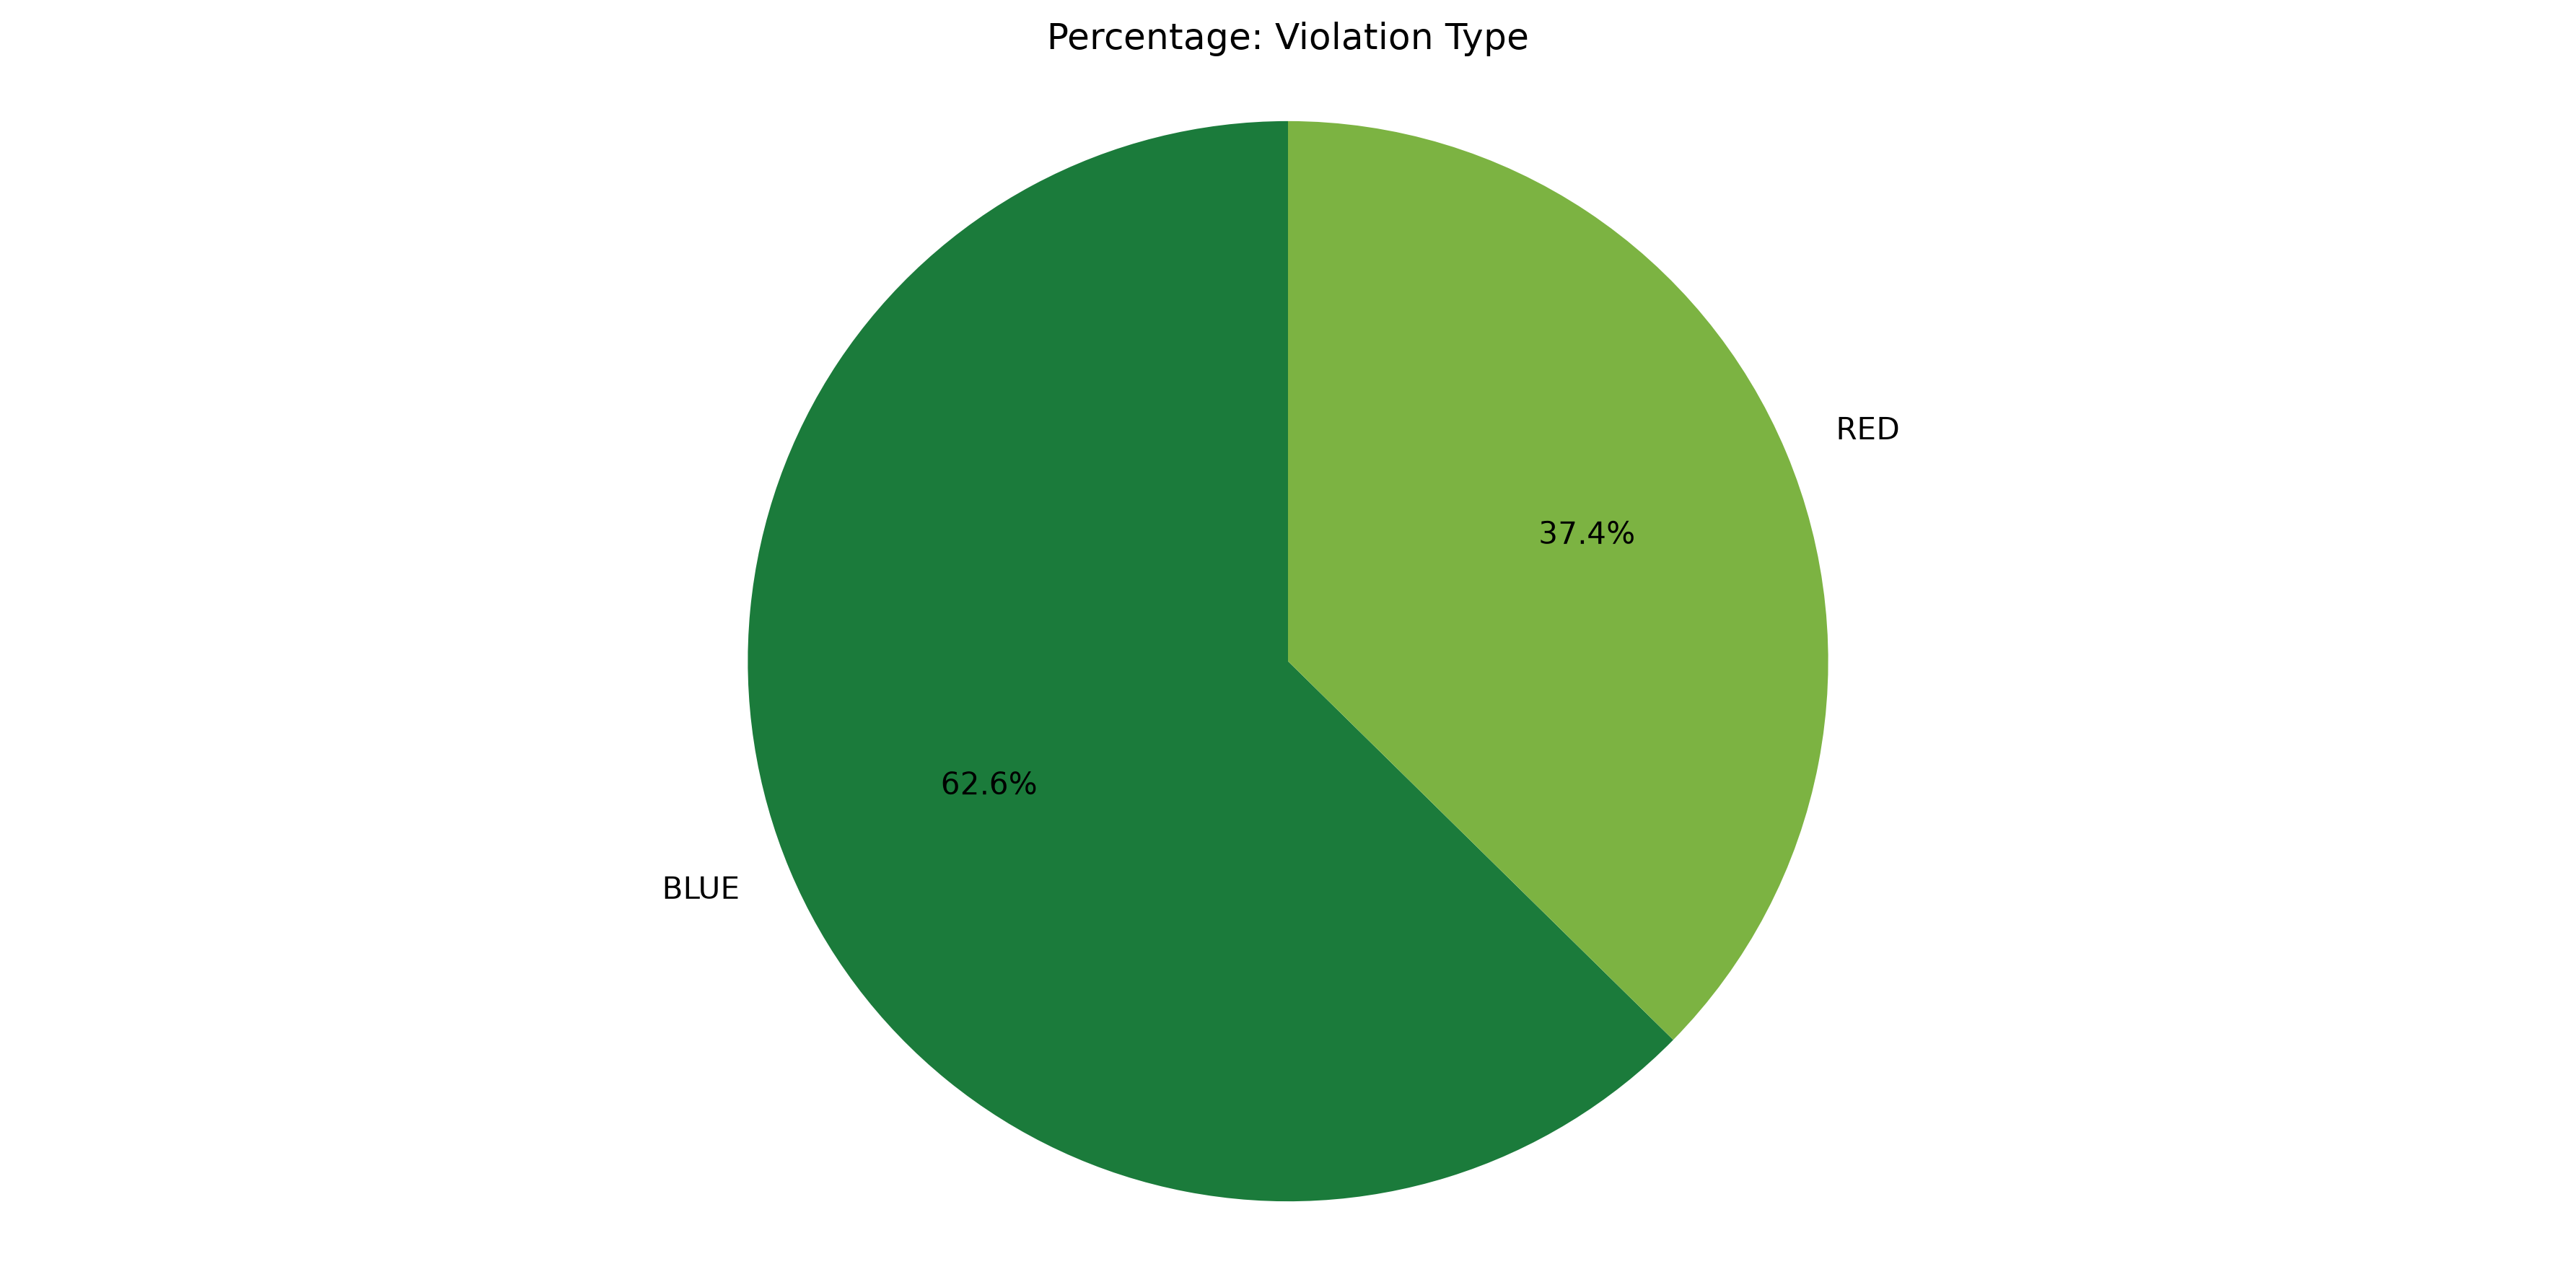

In [48]:
pie_chart(repeat_inspections,'Violation Type')

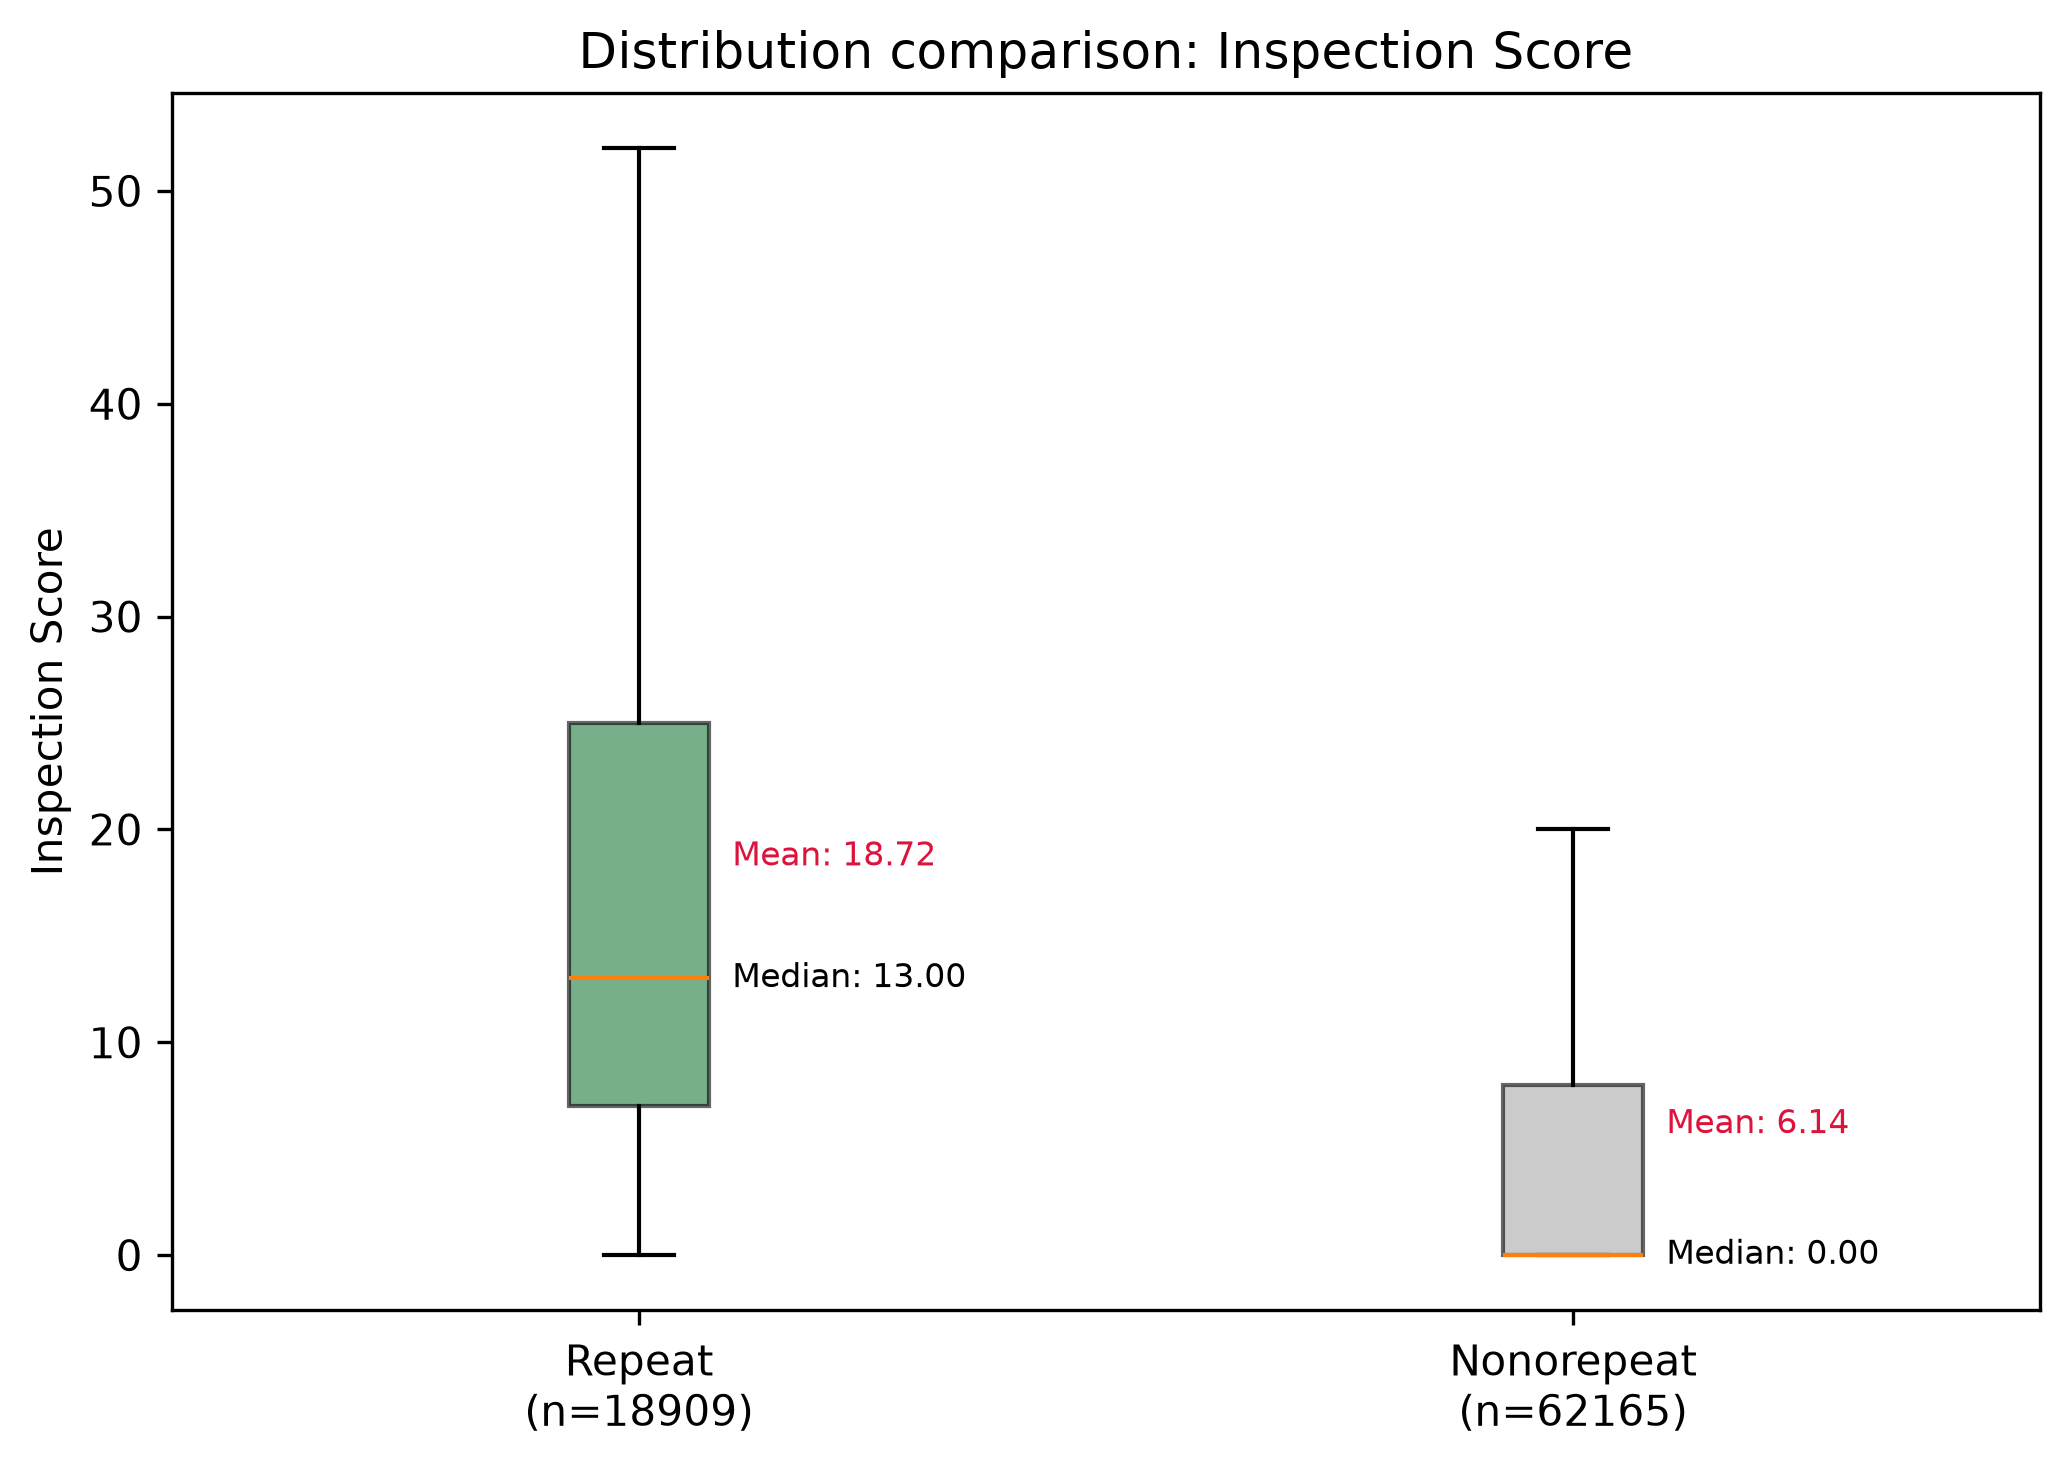

In [49]:
box_plot_compare(repeat_inspections,nonrepeat_inspections,'Inspection Score',['Repeat','Nonorepeat'],
                 show_outliers=False)

## Zip Code

In [50]:
#data from https://www.zip-codes.com/city/wa-seattle.asp#zipcodes
import pandas as pd

zip_population = pd.DataFrame([
    ("98101", "Standard", 16237, 1.60, "Times Square"),
    ("98102", "Standard", 25066, 2.46, "Broadway, Capitol Hill"),
    ("98103", "Standard", 53056, 5.21, "Greenwood, Wallingford"),
    ("98104", "Standard", 16157, 1.59, "International, Pioneer Square"),
    ("98105", "Standard", 49151, 4.83, "University"),
    ("98106", "Standard", 26295, 2.58, "White Center"),
    ("98107", "Standard", 28557, 2.81, "Ballard"),
    ("98108", "Standard", 25009, 2.46, "Tukwila"),
    ("98109", "Standard", 34551, 3.40, "Queen Anne"),
    ("98110", "Standard", 24825, 2.44, "Bainbridge Is, Seattle"),
    ("98111", "P.O. Box", 0, 0.00, None),
    ("98112", "Standard", 23152, 2.28, "Madison Park"),
    ("98113", "P.O. Box", 0, 0.00, None),
    ("98114", "P.O. Box", 0, 0.00, None),
    ("98115", "Standard", 54322, 5.34, "Seattle Naval Support Activi, Wedgwood"),
    ("98116", "Standard", 27691, 2.72, "West Seattle"),
    ("98117", "Standard", 35608, 3.50, "Crown Hill"),
    ("98118", "Standard", 47504, 4.67, "Columbia"),
    ("98119", "Standard", 26238, 2.58, "Interbay"),
    ("98121", "Standard", 21411, 2.10, None),
    ("98122", "Standard", 41646, 4.09, "East Union"),
    ("98124", "P.O. Box", 0, 0.00, None),
    ("98125", "Standard", 42965, 4.22, "Lake City, Northgate"),
    ("98126", "Standard", 23727, 2.33, "Westwood Village"),
    ("98127", "P.O. Box", 0, 0.00, None),
    ("98129", "Unique", 0, 0.00, "Reg Lib Handicapped"),
    ("98131", "Standard", 0, 0.00, None),
    ("98133", "Standard", 50720, 4.99, "Bitter Lake, Richmond Highlands, Shoreline"),
    ("98134", "Standard", 1216, 0.12, None),
    ("98136", "Standard", 16424, 1.61, "Westwood"),
    ("98138", "P.O. Box", 0, 0.00, "Tukwila"),
    ("98139", "P.O. Box", 0, 0.00, None),
    ("98141", "P.O. Box", 0, 0.00, None),
    ("98144", "Standard", 32178, 3.16, "Beacon Hill"),
    ("98145", "P.O. Box", 0, 0.00, None),
    ("98146", "Standard", 28845, 2.84, "Burien, Shorewood, White Center"),
    ("98148", "Standard", 11092, 1.09, "Burien, Des Moines, Normandy Park, Seatac"),
    ("98154", "Standard", 0, 0.00, None),
    ("98155", "Standard", 35948, 3.53, "Forest Park, Lake Forest Park, Lk Forest Park, Lk Forest Pk, North City, Shoreline"),
    ("98158", "Standard", 0, 0.00, "Seatac, Seatac Airport"),
    ("98160", "P.O. Box", 0, 0.00, "Richmond Beach"),
    ("98161", "Standard", 0, 0.00, None),
    ("98164", "Standard", 176, 0.02, None),
    ("98165", "P.O. Box", 0, 0.00, None),
    ("98166", "Standard", 22152, 2.18, "Burien, Normandy Park"),
    ("98168", "Standard", 36389, 3.58, "Burien, Seatac, Tukwila"),
    ("98170", "Unique", 0, 0.00, "Amazon.com"),
    ("98174", "Standard", 0, 0.00, None),
    ("98175", "P.O. Box", 0, 0.00, None),
    ("98177", "Standard", 20160, 1.98, "Bitter Lake, Richmond Beach, Shoreline, The Highlands"),
    ("98178", "Standard", 26122, 2.57, "Bryn Mawr, Skyway, Tukwila"),
    ("98181", "Unique", 0, 0.00, "Macys"),
    ("98185", "Unique", 0, 0.00, "Safeco Plaza"),
    ("98188", "Standard", 27851, 2.74, "Duwamish, Mcmicken Heights, Riverton, Seatac, Tukwila"),
    ("98190", "Unique", 0, 0.00, "Capital One"),
    ("98191", "Unique", 0, 0.00, "Qwest"),
    ("98194", "P.O. Box", 0, 0.00, None),
    ("98195", "Unique", 3710, 0.36, "Univ Of Washington"),
    ("98198", "Standard", 38727, 3.81, "Des Moines, Normandy Park, Redondo Beach, Seatac"),
    ("98199", "Standard", 22549, 2.22, "Fort Lawton, Magnolia"),
], columns=["ZIP Code", "Type", "Population", "% of Population", "Alias Names"])


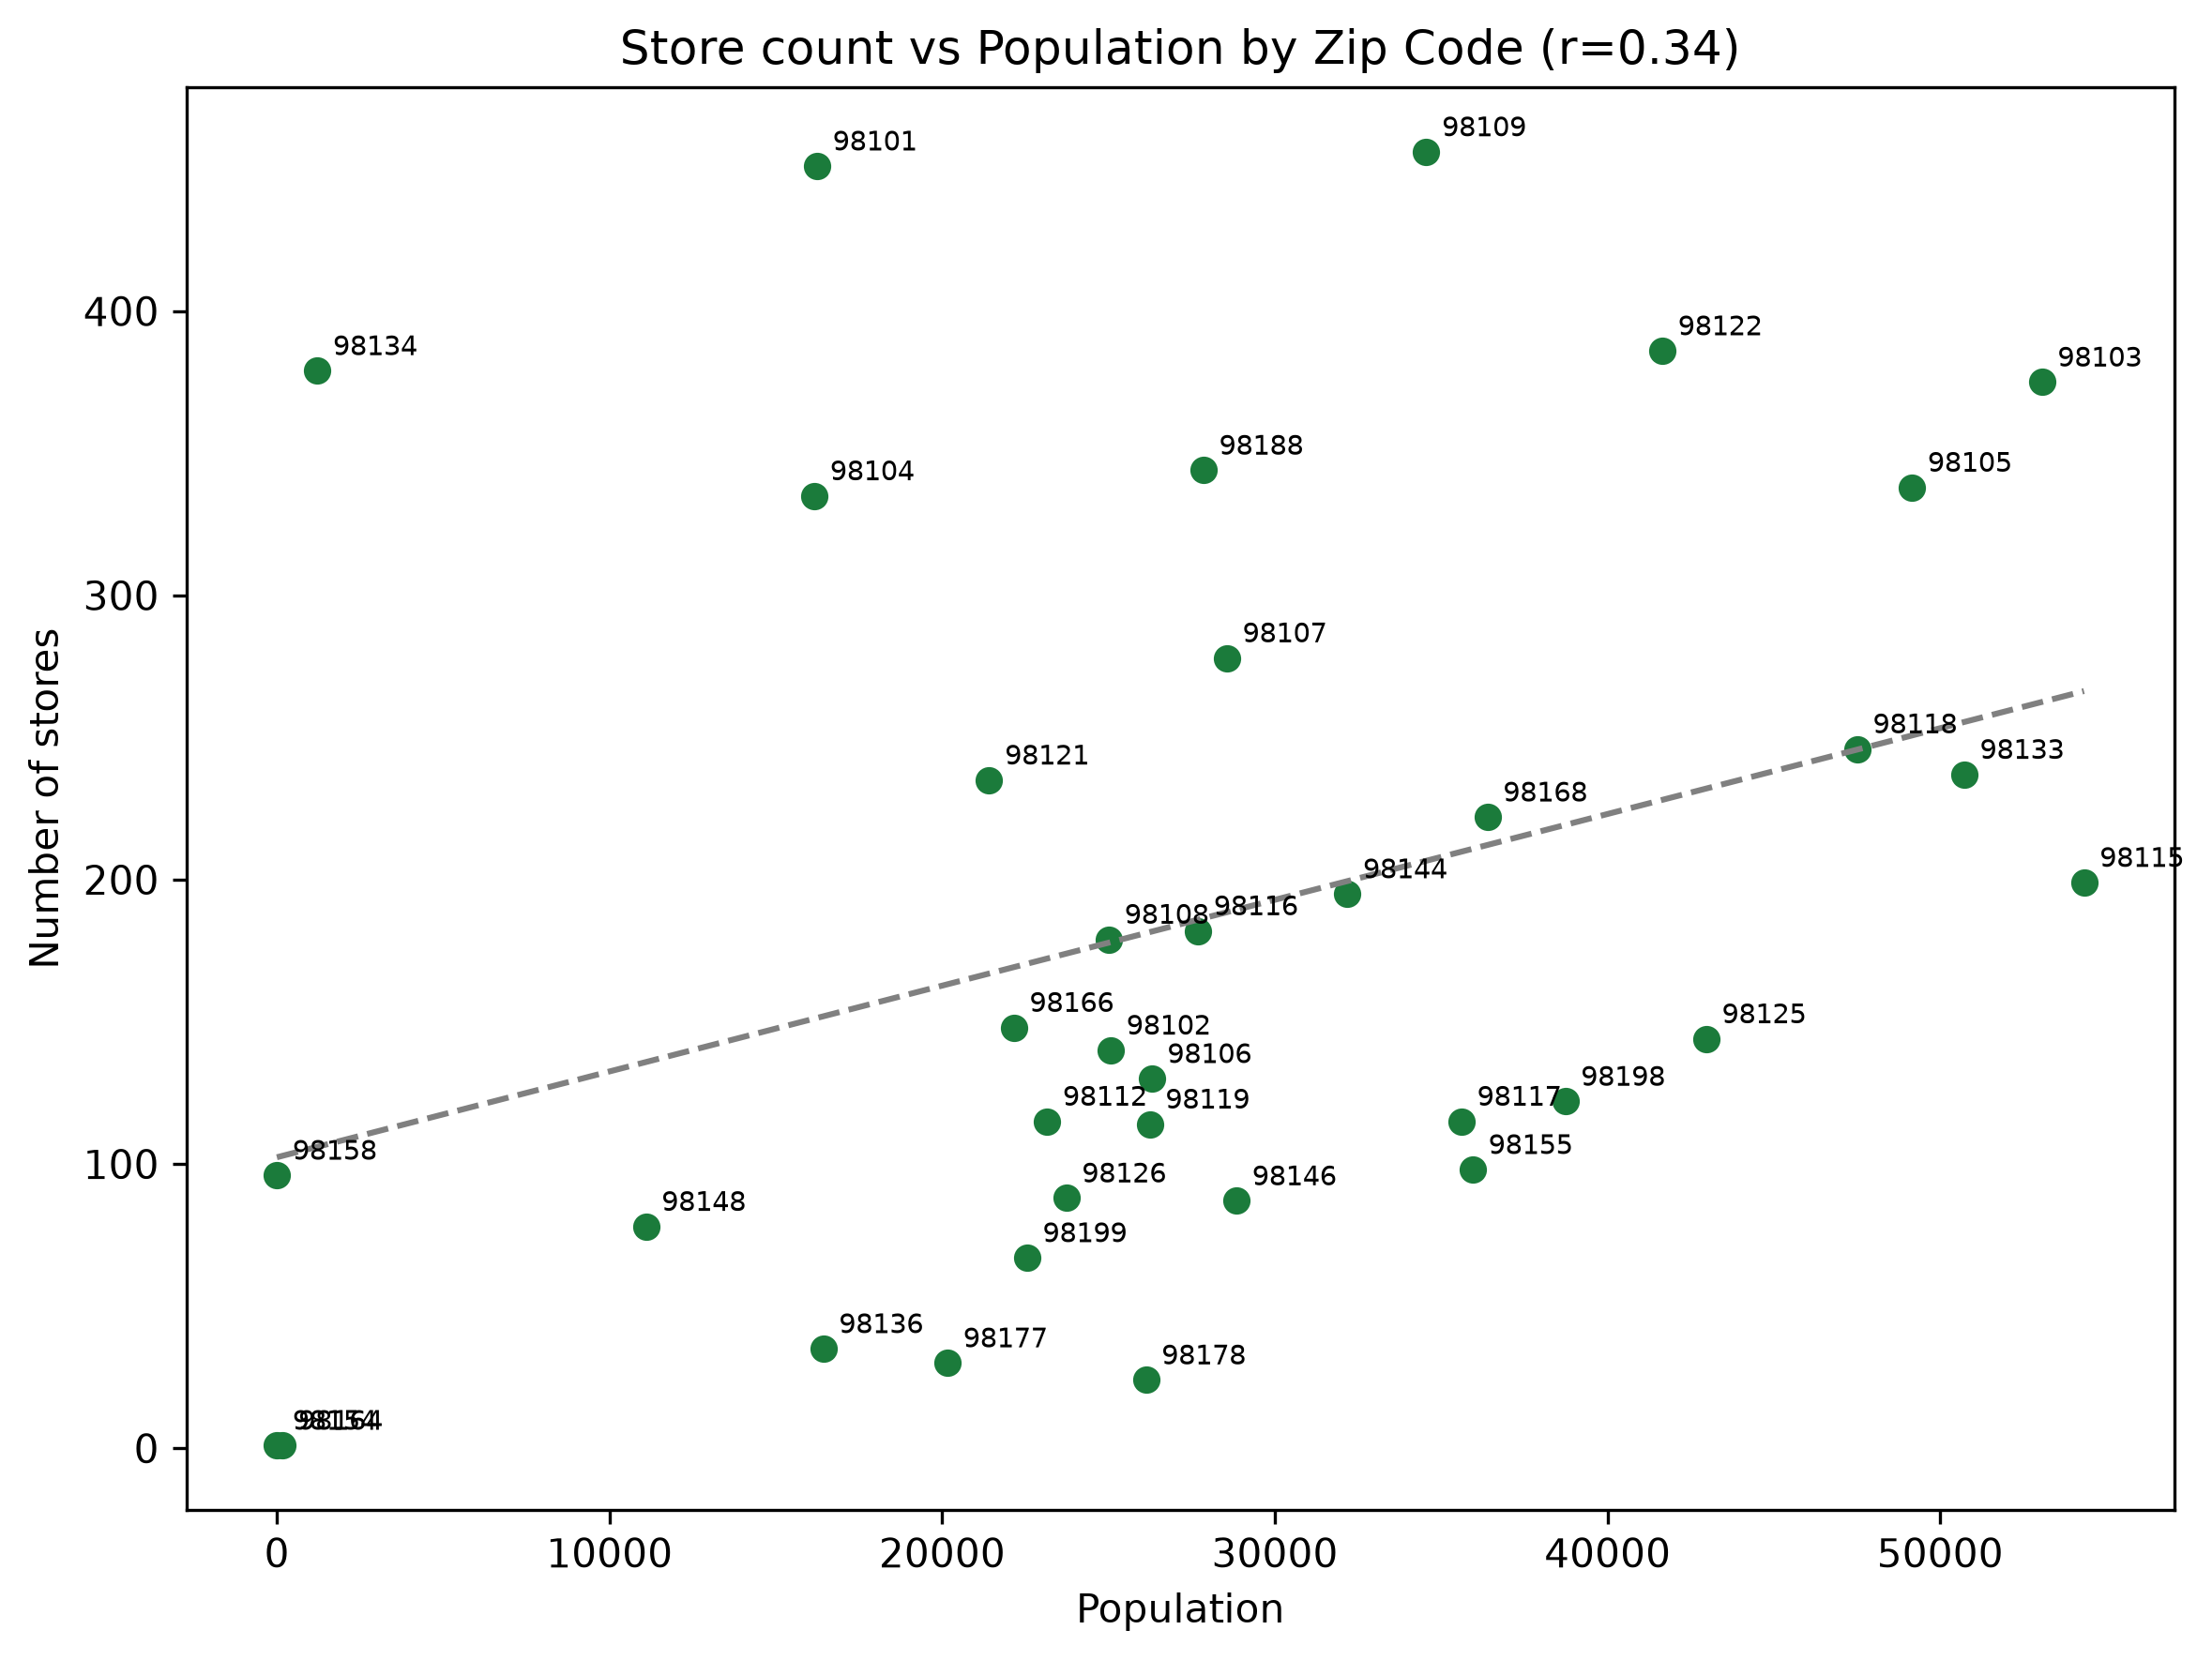

In [51]:
import numpy as np

store_counts = (
    df.assign(**{'Zip Code': df['Zip Code'].astype(str).str[:5]})
      .drop_duplicates(subset='Business_ID')
      .groupby('Zip Code')['Business_ID']
      .nunique()
      .rename('Store Count')
      .reset_index()
)

zip_population['ZIP Code'] = zip_population['ZIP Code'].astype(str)

merged = store_counts.merge(zip_population, left_on='Zip Code', right_on='ZIP Code', how='inner')

x = merged['Population']
y = merged['Store Count']
slope, intercept = np.polyfit(x, y, 1)
r = np.corrcoef(x, y)[0, 1]

plt.figure(figsize=(8, 6), dpi=300)
plt.scatter(x, y, color='#1B7B3B')

for _, row in merged.iterrows():
    plt.annotate(row['Zip Code'], (row['Population'], row['Store Count']),
                 textcoords="offset points", xytext=(4, 4), fontsize=7)

x_line = np.linspace(x.min(), x.max(), 100)
plt.plot(x_line, slope * x_line + intercept, color='gray', linestyle='--')

plt.xlabel('Population')
plt.ylabel('Number of stores')
plt.title(f'Store count vs Population by Zip Code (r={r:.2f})')
plt.tight_layout()
plt.show()


## Business Growth by Classification

In [52]:
df['Inspection Year'] = pd.to_datetime(df['Inspection Date']).dt.year
unique_business_by_year = df.drop_duplicates(subset=['Business_ID', 'Inspection Year'])


In [53]:
from matplotlib.ticker import MaxNLocator

def line_chart_growth_rate(df, by='Classification', date_col='Inspection Date', top_n=None, ncols=3, exclude_years=(2026,), min_count=100):
    temp = df.copy()
    temp[date_col] = pd.to_datetime(temp[date_col])
    temp['Year'] = temp[date_col].dt.year
    temp = temp[~temp['Year'].isin(exclude_years)]

    active = (
        temp.drop_duplicates(subset=[by, 'Year', 'Business_ID'])
            .groupby([by, 'Year'])['Business_ID']
            .nunique()
            .rename('Active Businesses')
            .reset_index()
    )

    group_counts = temp.groupby(by)['Business_ID'].nunique()
    group_counts = group_counts[group_counts >= min_count]

    top_groups = temp[by].value_counts().head(top_n).index if top_n else temp[by].unique()
    group_order = [g for g in active[by].unique() if g in top_groups and g in group_counts.index]
    palette = list(GRADE_COLORS.values())

    nrows = -(-len(group_order) // ncols)  # ceil division
    fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 3.5 * nrows), dpi=300)
    axes = axes.flatten()

    for i, group in enumerate(group_order):
        ax = axes[i]
        color = palette[i % len(palette)]
        sub = active[active[by] == group].sort_values('Year').set_index('Year')['Active Businesses']
        growth = sub.pct_change() * 100

        ax.plot(growth.index, growth.values, color=color, marker='o')
        ax.axhline(0, color='gray', linestyle='--', linewidth=1)
        ax.set_ylabel('YoY Growth (%)', fontsize=8)

        ax2 = ax.twinx()
        ax2.bar(sub.index, sub.values, color=color, alpha=0.3)
        ax2.set_ylabel('Active Businesses', fontsize=8)

        ax.set_title(f"{group} ({group_counts[group]})", fontsize=10)
        ax.xaxis.set_major_locator(MaxNLocator(integer=True))
        ax.tick_params(axis='x', labelsize=7)
        ax.tick_params(axis='y', labelsize=7)
        ax2.tick_params(axis='y', labelsize=7)

    for j in range(len(group_order), len(axes)):
        axes[j].axis('off')

    fig.suptitle(f'YoY Growth Rate (line) & Active Businesses (bar) by {by}')
    fig.supxlabel('Year')
    plt.tight_layout()
    plt.show()


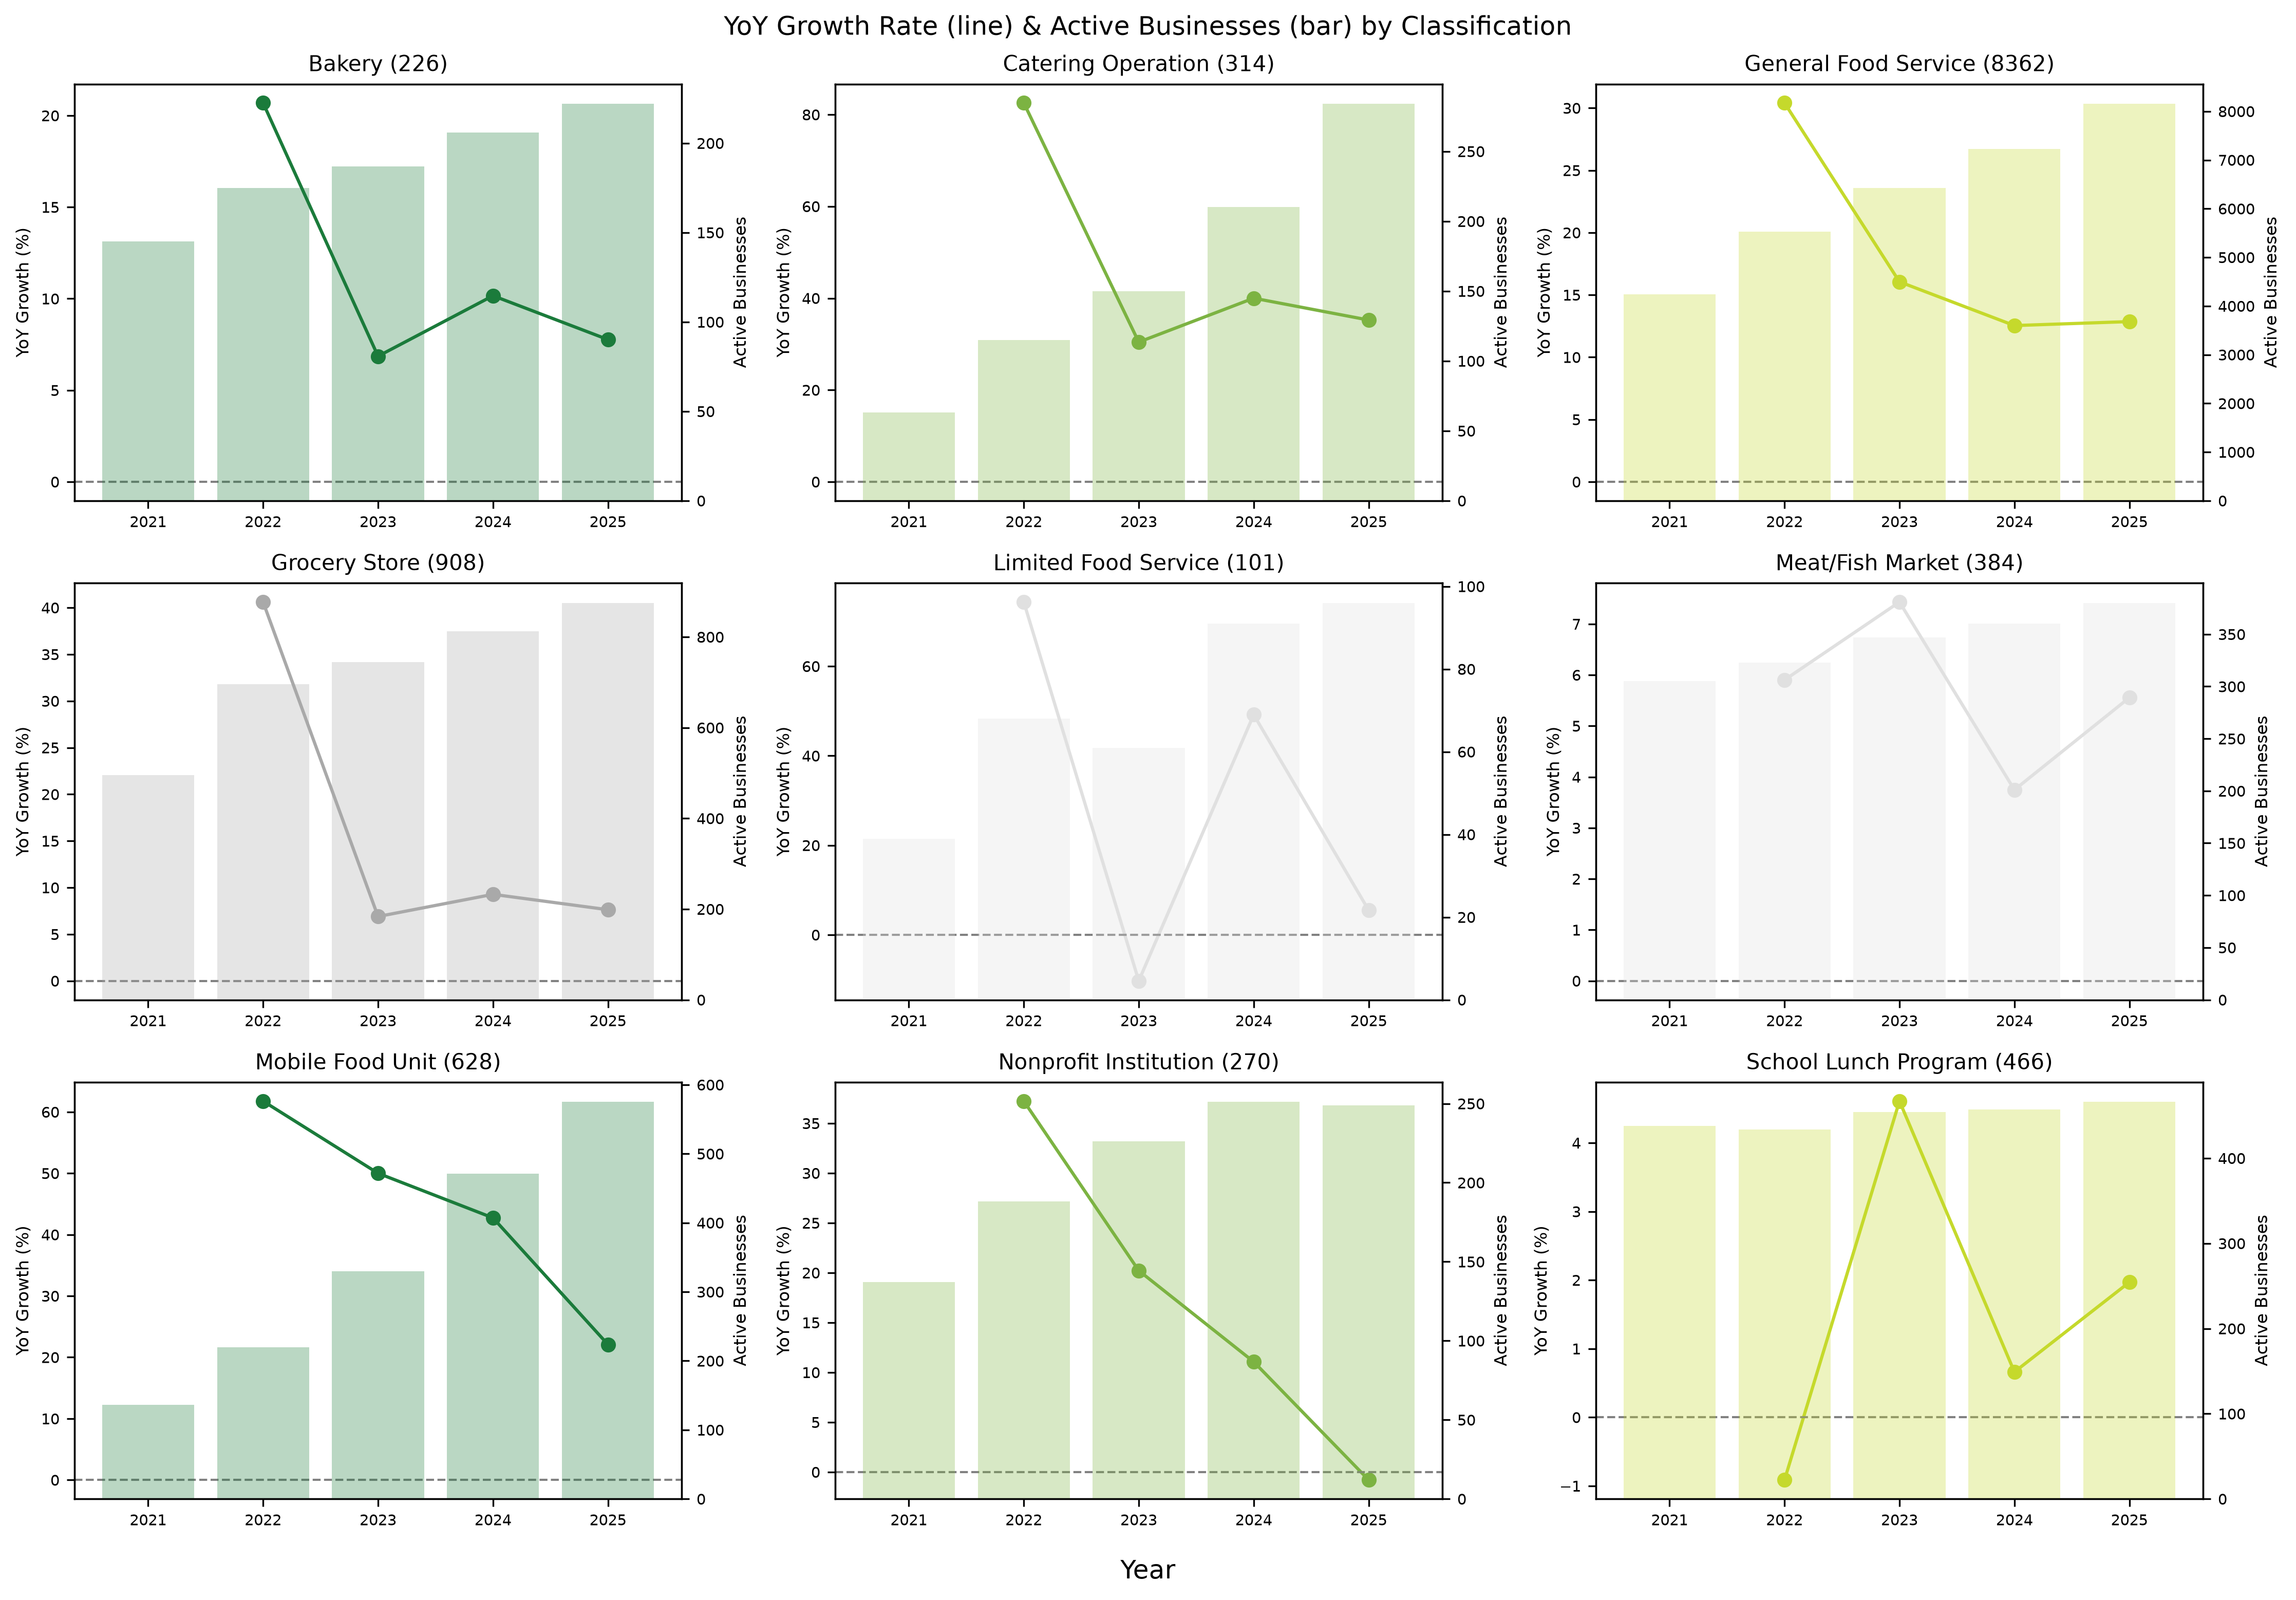

In [54]:
line_chart_growth_rate(df=unique_business_by_year,by='Classification', date_col='Inspection Date')

## Need to improve


In [55]:
df[df['Grade']=='Needs To Improve']['Business_ID'].unique()

<StringArray>
['PFE-PR-3148923', 'PFE-PR-3149627', 'PFE-PR-3136197', 'PFE-PR-3148107',
 'PFE-PR-3144120', 'PFE-PR-3128462', 'PFE-PR-3127958', 'PFE-PR-3140667',
 'PFE-PR-3148378', 'PFE-PR-3133980', 'PFE-PR-3128728', 'PFE-PR-3150469',
 'PFE-PR-3139609', 'PFE-PR-3143828', 'PFE-PR-3141520', 'PFE-PR-3137714',
 'PFE-PR-3147776', 'PFE-PR-3147938', 'PFE-PR-3149734', 'PFE-PR-3127942',
 'PFE-PR-3149448', 'PFE-PR-3130915', 'PFE-PR-3150596', 'PFE-PR-3135151',
 'PFE-PR-3143780', 'PFE-PR-3141045', 'PFE-PR-3127856', 'PFE-PR-3148408',
 'PFE-PR-3127160', 'PFE-PR-3148361', 'PFE-PR-3135910', 'PFE-PR-3149553',
 'PFE-PR-3127355', 'PFE-PR-3128905',  'PFE-PR-500611', 'PFE-PR-3129558',
 'PFE-PR-3130551', 'PFE-PR-3137982', 'SFE-PR-3134070', 'PFE-PR-3148335',
 'PFE-PR-3145941', 'PFE-PR-3145831', 'PFE-PR-3135915', 'PFE-PR-3149513',
 'PFE-PR-3149512', 'PFE-PR-3128857', 'PFE-PR-3149851']
Length: 47, dtype: str

In [56]:
df.columns

Index(['Name', 'Program Identifier', 'Inspection Date', 'Classification',
       'Address', 'City', 'Zip Code', 'Inspection Type', 'Inspection Score',
       'Inspection Result', 'Inspection Closed Business', 'Seating Range',
       'Risk Category', 'Violation Type', 'Violation Description',
       'Violation Points', 'Grade', 'Parcel Number', 'Business_ID',
       'Inspection_Serial_Num', 'Latitude', 'Longitude', 'is_repeat',
       'Inspection Year'],
      dtype='str')

In [57]:
nti_ids = df[df['Grade']=='Needs To Improve']['Business_ID'].unique()
# df[(df['Grade']=='Needs To Improve')& (df['Business_ID']=='PFE-PR-3148923')]

subset = df[df['Business_ID'].isin(nti_ids)]
# df[df['Business_ID']=='PFE-PR-3149627']
# subset[subset['Inspection Score']==0]
# print((grade_counts_per_biz > 1).sum())  # how many have >1 distinct grade -> 0

# subset.groupby('Business_ID').size().describe()  # how many inspections per business


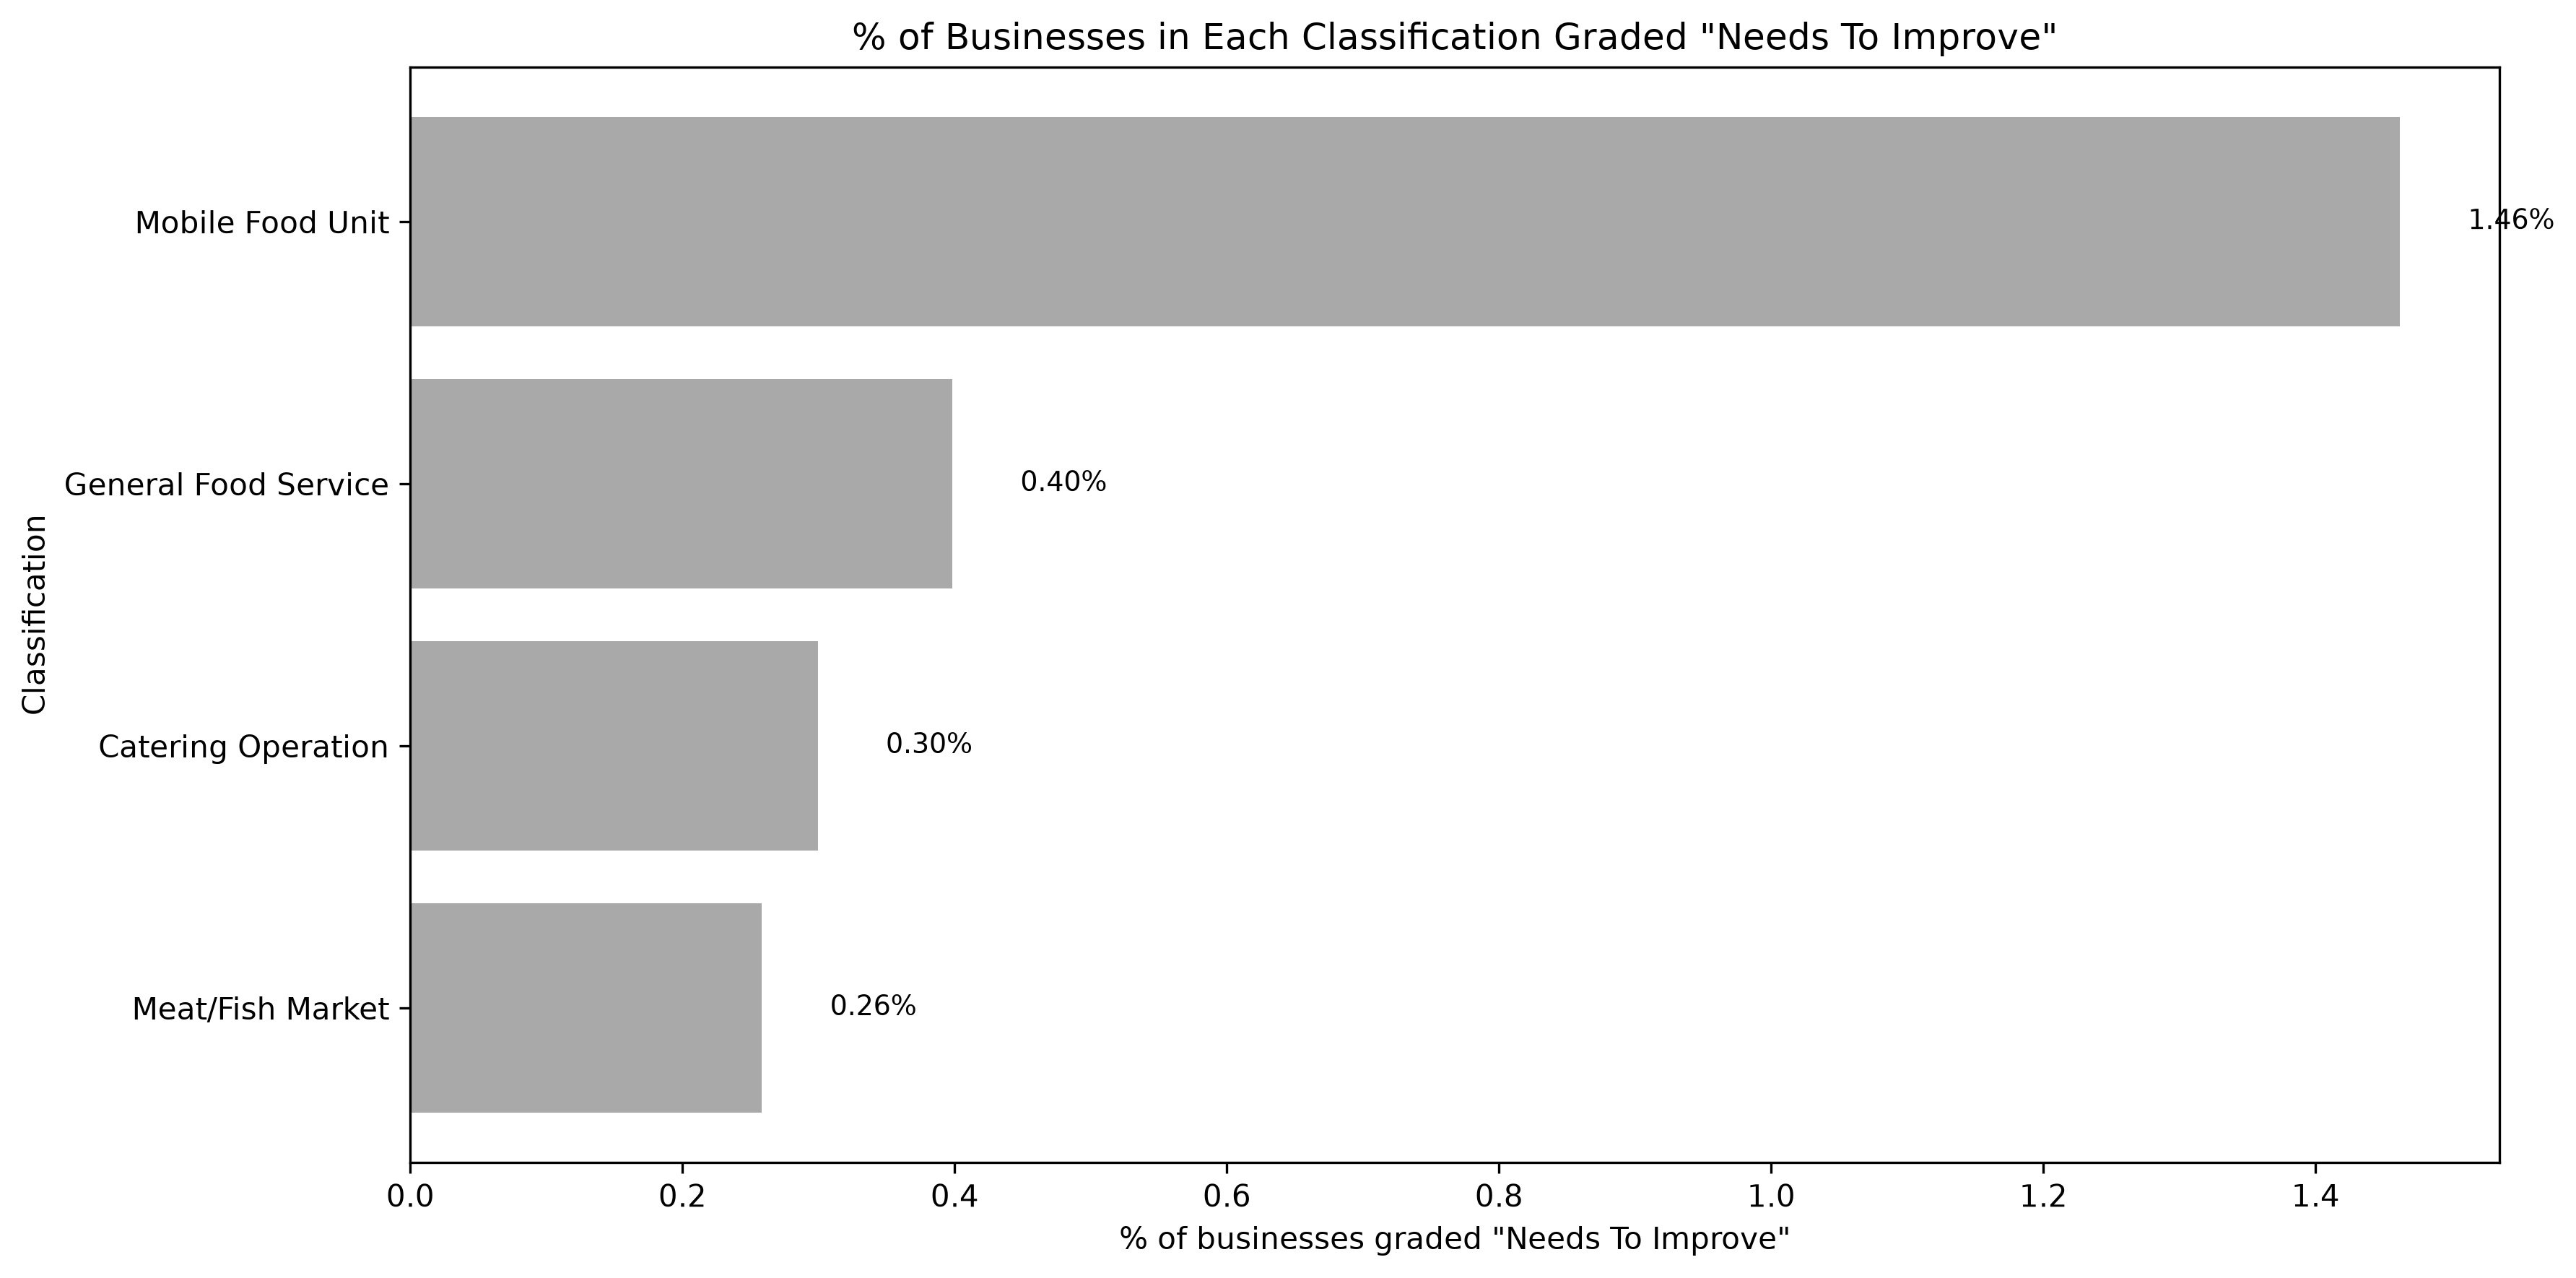

In [58]:
def bar_chart_needs_to_improve_rate(df, top_n=15):
    unique_biz = df.drop_duplicates(subset='Business_ID')

    total_by_class = unique_biz['Classification'].value_counts()
    nti_by_class = unique_biz[unique_biz['Grade'] == 'Needs To Improve']['Classification'].value_counts()

    pct = (nti_by_class / total_by_class * 100).dropna().sort_values(ascending=False).head(top_n)

    fig, ax = plt.subplots(figsize=(12, 6), dpi=300)
    ax.barh(pct.index, pct.values, color=GRADE_COLORS['Needs To Improve'])
    ax.invert_yaxis()

    for i, v in enumerate(pct.values):
        ax.text(v + 0.05, i, f"{v:.2f}%", va='center', fontsize=9)

    ax.set_xlabel('% of businesses graded "Needs To Improve"')
    ax.set_ylabel('Classification')
    ax.set_title('% of Businesses in Each Classification Graded "Needs To Improve"')
    plt.tight_layout()
    plt.show()
bar_chart_needs_to_improve_rate(df)


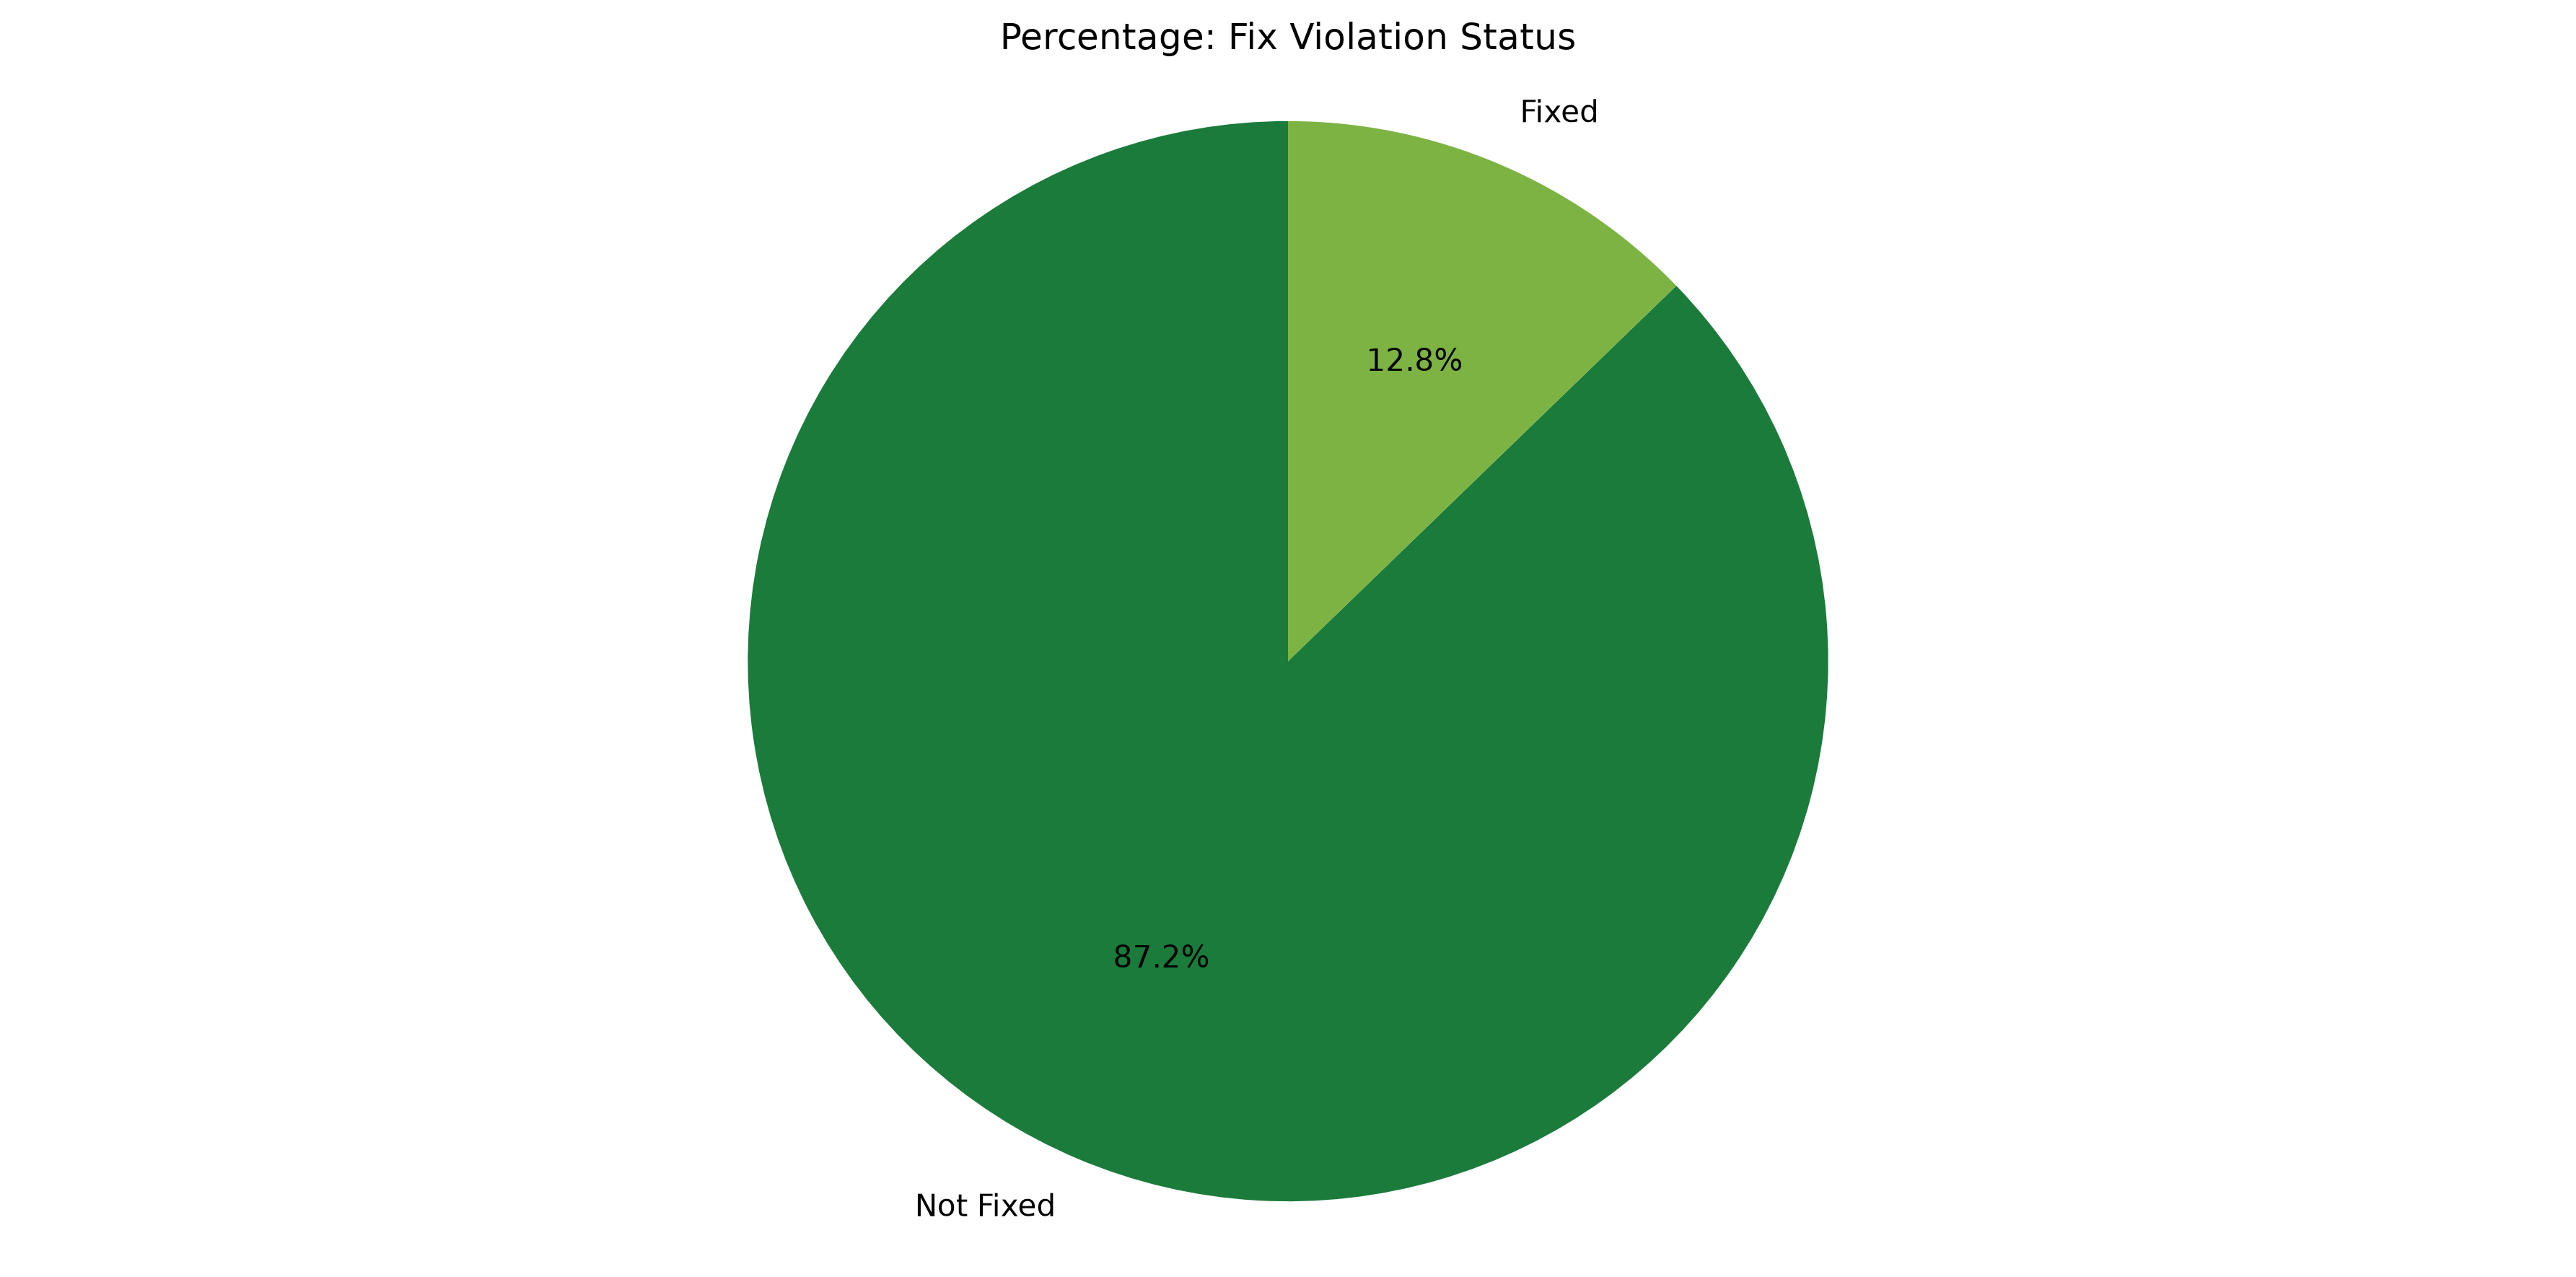

In [59]:
# Step 3: fixed vs not fixed, based on whether the business has any repeat violation
business_fix_status = subset.groupby('Business_ID')['is_repeat'].any().map({True: 'Not Fixed', False: 'Fixed'})

fix_status_df = business_fix_status.reset_index(name='Fix Violation Status')
pie_chart(fix_status_df, 'Fix Violation Status')


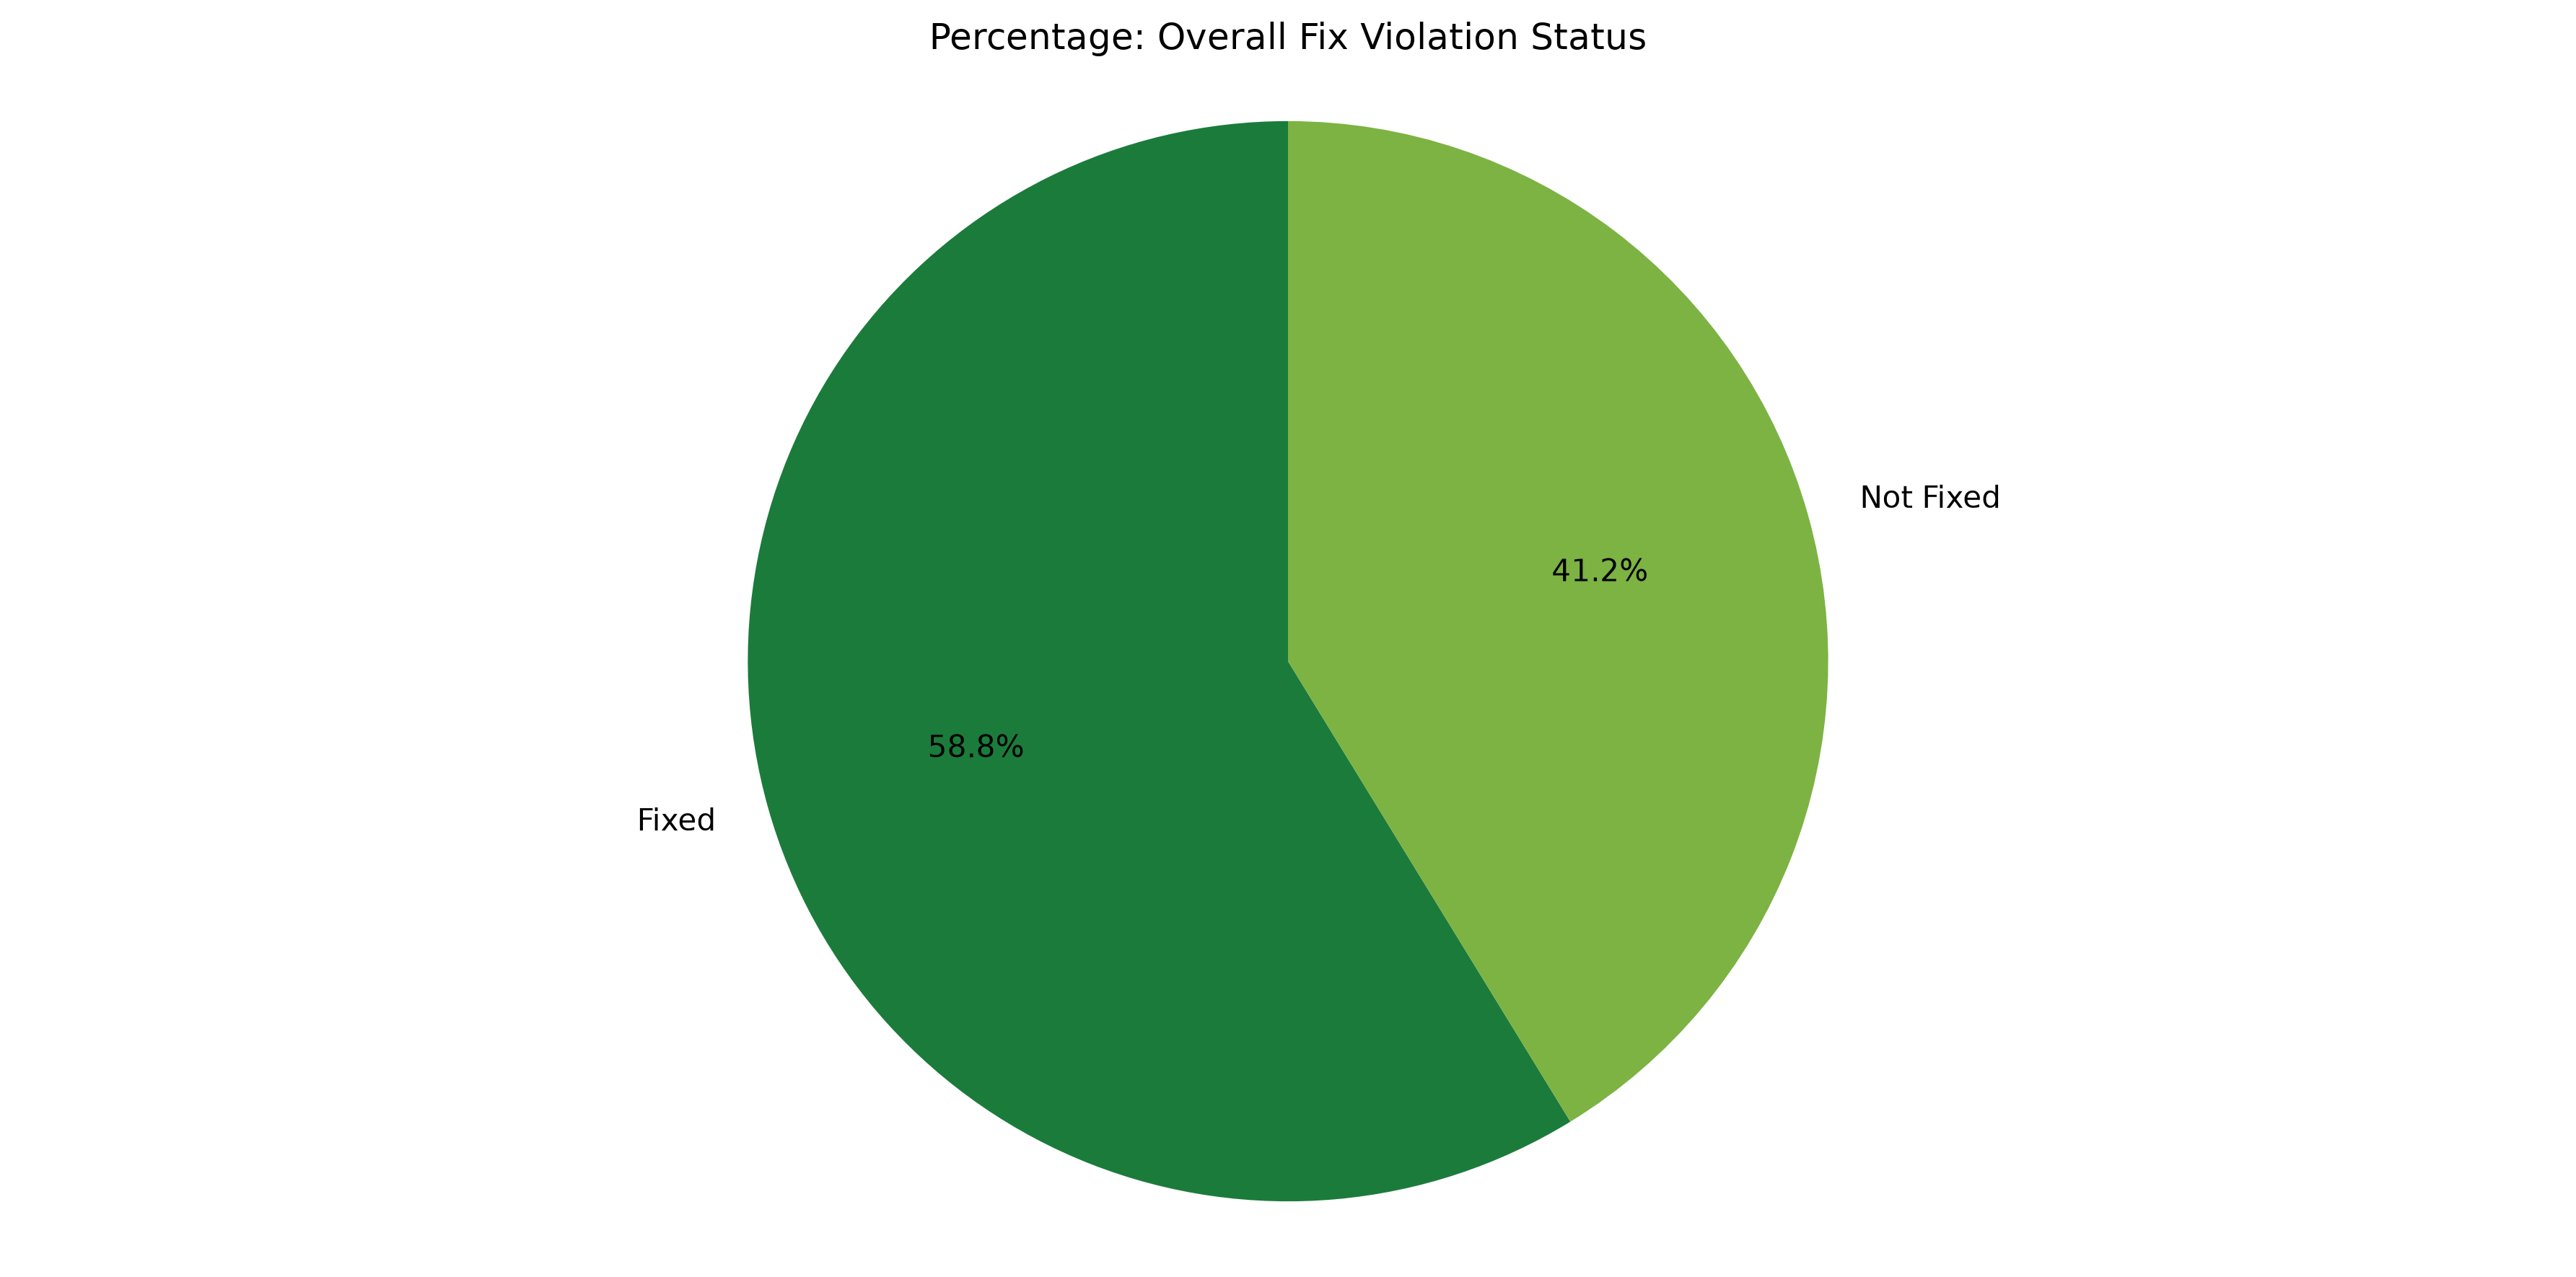

In [60]:
business_fix_status = df.groupby('Business_ID')['is_repeat'].any().map({True: 'Not Fixed', False: 'Fixed'})

fix_status_df = business_fix_status.reset_index(name='Overall Fix Violation Status')
pie_chart(fix_status_df, 'Overall Fix Violation Status')

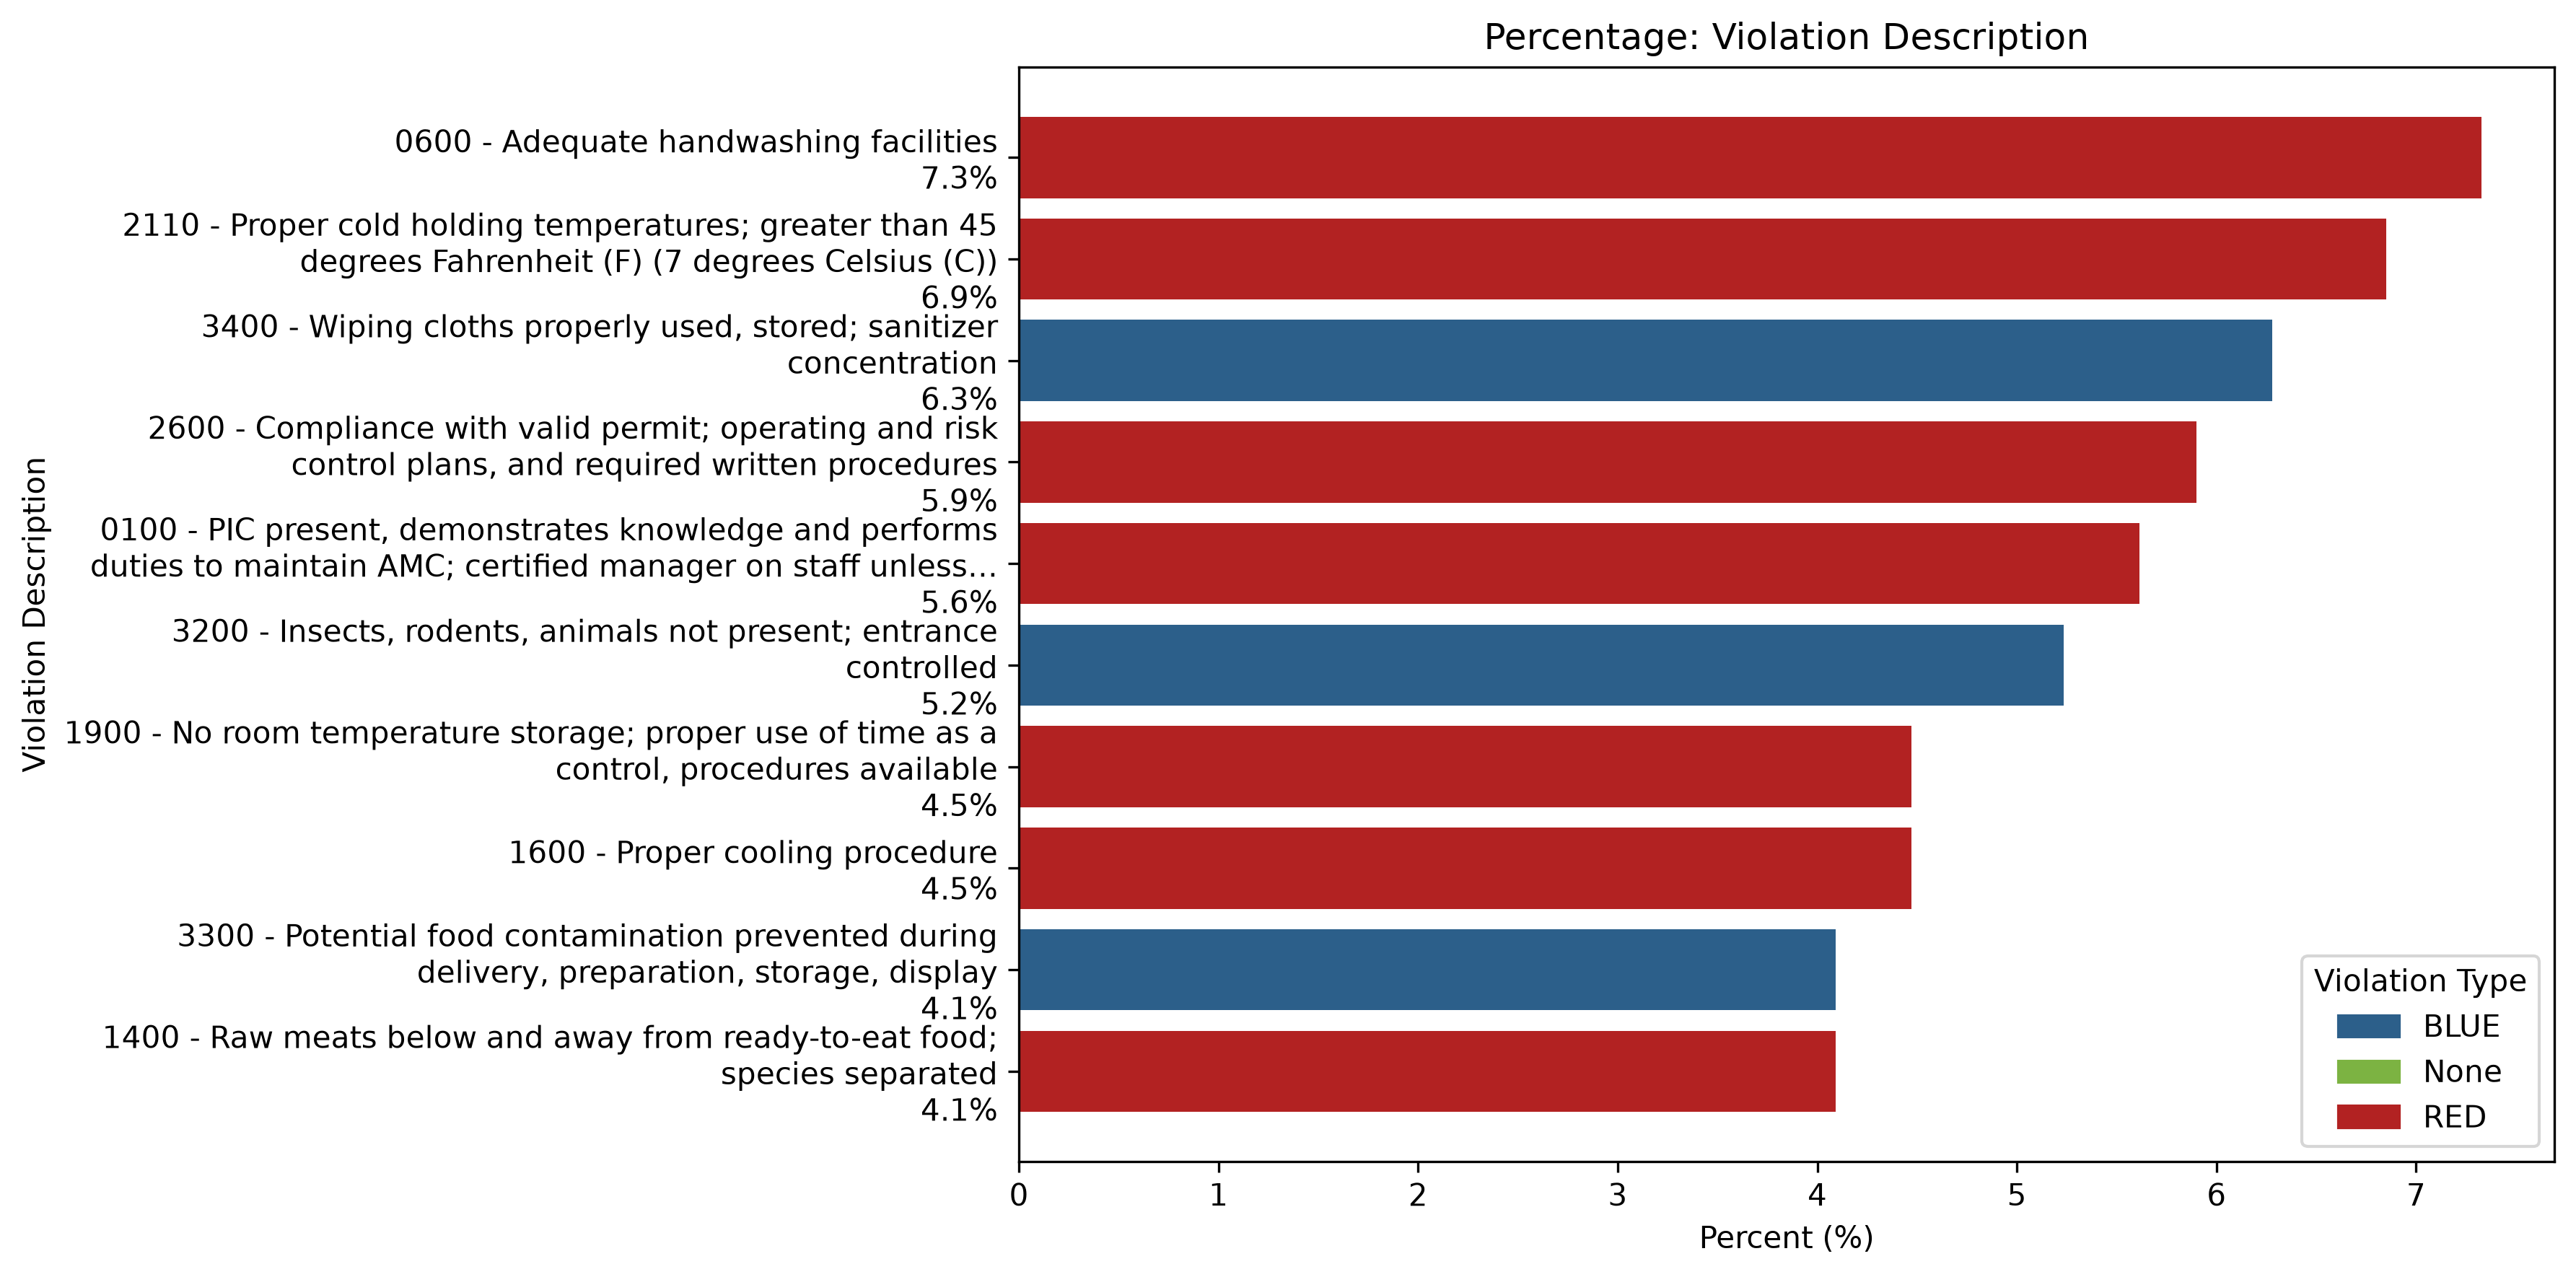

In [61]:
bar_chart(subset, 'Violation Description', top_n=10, mode='pct', horizontal=True, wrap_width=60, wrap_height=2,
          color_by='Violation Type', color_map={'RED': '#B22222', 'BLUE': '#2C5F8A'})


In [62]:
routine_insp = (
    df[df['Inspection Type'] == 'Routine Inspection/Field Review']
    .drop_duplicates(subset='Inspection_Serial_Num')
    .copy()
)
routine_insp['Inspection Date'] = pd.to_datetime(routine_insp['Inspection Date'])
routine_insp = routine_insp.sort_values('Inspection Date')

split_idx = int(len(routine_insp) * 0.8)
train_serials = routine_insp.iloc[:split_idx]['Inspection_Serial_Num']
test_serials = routine_insp.iloc[split_idx:]['Inspection_Serial_Num']

train_df = df[df['Inspection_Serial_Num'].isin(train_serials)]
test_df = df[df['Inspection_Serial_Num'].isin(test_serials)]

print(f"Train: {train_df['Inspection_Serial_Num'].nunique()} inspections, {len(train_df)} rows, "
      f"{routine_insp.iloc[:split_idx]['Inspection Date'].min().date()} to {routine_insp.iloc[:split_idx]['Inspection Date'].max().date()}")
print(f"Test: {test_df['Inspection_Serial_Num'].nunique()} inspections, {len(test_df)} rows, "
      f"{routine_insp.iloc[split_idx:]['Inspection Date'].min().date()} to {routine_insp.iloc[split_idx:]['Inspection Date'].max().date()}")


Train: 54247 inspections, 81841 rows, 2021-01-04 to 2025-09-05
Test: 13562 inspections, 19935 rows, 2025-09-05 to 2026-08-06
